# Generative AI Use and Student Outcomes Analysis

This notebook explores how Generative AI usage patterns relate to student GPA change, skill retention, exam anxiety, perceived AI dependency, and burnout risk.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

## 1. Loading the Dataset

In this section, we load the student-level dataset and perform initial checks such as shape, column names, data types, missing values, and duplicate records.

In [4]:
df = pd.read_csv("../data/raw/ai_student_impact_dataset.csv")

In [5]:
df.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


In [6]:
df.tail()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
49995,149996,Business,Senior,2.899,12.16,Copywriting/Drafting,Beginner,2,False,13.36,2,Allowed_With_Citation,2,3.584,66.16,High
49996,149997,STEM,Senior,2.870,2.51,Copywriting/Drafting,Intermediate,1,False,4.67,3,Actively_Encouraged,3,3.096,81.62,Medium
49997,149998,Business,Senior,3.177,15.87,Summarizing_Reading,Advanced,5,True,3.92,4,Allowed_With_Citation,5,3.605,97.21,High
49998,149999,Business,Junior,3.398,19.91,Debugging/Troubleshooting,Intermediate,5,False,7.10,5,Allowed_With_Citation,3,3.527,84.12,Medium
49999,150000,Arts,Sophomore,3.242,3.30,Copywriting/Drafting,Beginner,1,False,3.93,2,Allowed_With_Citation,6,3.261,76.16,Low


In [7]:
df.shape

(50000, 16)

The dataset contains 50,000 rows and 16 columns.

In [8]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 50000
Number of columns: 16


In [9]:
df.columns

Index(['Student_ID', 'Major_Category', 'Year_of_Study', 'Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Primary_Use_Case', 'Prompt_Engineering_Skill', 'Tool_Diversity', 'Paid_Subscription', 'Traditional_Study_Hours', 'Perceived_AI_Dependency', 'Institutional_Policy', 'Anxiety_Level_During_Exams', 'Post_Semester_GPA', 'Skill_Retention_Score', 'Burnout_Risk_Level'], dtype='str')

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  str    
 2   Year_of_Study               50000 non-null  str    
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  str    
 6   Prompt_Engineering_Skill    50000 non-null  str    
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  str    
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           50000 non-null

In [11]:
df.isna().sum()

Student_ID                    0
Major_Category                0
Year_of_Study                 0
Pre_Semester_GPA              0
Weekly_GenAI_Hours            0
Primary_Use_Case              0
Prompt_Engineering_Skill      0
Tool_Diversity                0
Paid_Subscription             0
Traditional_Study_Hours       0
Perceived_AI_Dependency       0
Institutional_Policy          0
Anxiety_Level_During_Exams    0
Post_Semester_GPA             0
Skill_Retention_Score         0
Burnout_Risk_Level            0
dtype: int64

In [12]:
missing_values = df.isna().sum()
missing_values

Student_ID                    0
Major_Category                0
Year_of_Study                 0
Pre_Semester_GPA              0
Weekly_GenAI_Hours            0
Primary_Use_Case              0
Prompt_Engineering_Skill      0
Tool_Diversity                0
Paid_Subscription             0
Traditional_Study_Hours       0
Perceived_AI_Dependency       0
Institutional_Policy          0
Anxiety_Level_During_Exams    0
Post_Semester_GPA             0
Skill_Retention_Score         0
Burnout_Risk_Level            0
dtype: int64

In [13]:
df.isna().sum().sum()

np.int64(0)

There are no missing values in the dataset.

In [14]:
df.duplicated().sum()

np.int64(0)

No fully duplicated rows were found in the dataset.

In [18]:
numeric_summary = df.describe().T
numeric_summary

,count,mean,std,min,25%,50%,75%,max
Student_ID,50000.0,125000.500000,14433.901067,100001.000,112500.75000,125000.500,137500.250,150000.000
Pre_Semester_GPA,50000.0,3.146102,0.478854,1.183,2.83400,3.210,3.521,3.998
Weekly_GenAI_Hours,50000.0,8.427752,8.269490,0.000,2.39000,5.800,11.720,40.000
Tool_Diversity,50000.0,2.800260,1.188020,1.000,2.00000,3.000,4.000,5.000
Traditional_Study_Hours,50000.0,11.209271,5.156426,1.000,7.56000,11.180,14.710,35.860
Perceived_AI_Dependency,50000.0,3.505360,1.820812,1.000,2.00000,3.000,5.000,10.000
Anxiety_Level_During_Exams,50000.0,4.270760,2.144066,1.000,3.00000,4.000,6.000,10.000
Post_Semester_GPA,50000.0,3.349299,0.495673,1.000,3.02375,3.421,3.749,4.000
Skill_Retention_Score,50000.0,75.798125,13.281626,10.780,66.82000,76.000,85.190,100.000


In [20]:
df.describe(include="str").T

,count,unique,top,freq
Major_Category,50000,5,STEM,15059
Year_of_Study,50000,5,Junior,11045
Primary_Use_Case,50000,5,Debugging/Troubleshooting,12295
Prompt_Engineering_Skill,50000,3,Beginner,18495
Institutional_Policy,50000,3,Allowed_With_Citation,25224
Burnout_Risk_Level,50000,3,Medium,21144


In [22]:
categorical_columns = df.select_dtypes(include="str").columns

for col in categorical_columns:
    print(col)
    print(df[col].unique())
    print("-" * 50)

Major_Category
<StringArray>
['Humanities', 'Medical', 'Business', 'STEM', 'Arts']
Length: 5, dtype: str
--------------------------------------------------
Year_of_Study
<StringArray>
['Senior', 'Junior', 'Freshman', 'Sophomore', 'Graduate']
Length: 5, dtype: str
--------------------------------------------------
Primary_Use_Case
<StringArray>
['Copywriting/Drafting', 'Ideation', 'Summarizing_Reading', 'Debugging/Troubleshooting', 'Direct_Answer_Generation']
Length: 5, dtype: str
--------------------------------------------------
Prompt_Engineering_Skill
<StringArray>
['Beginner', 'Advanced', 'Intermediate']
Length: 3, dtype: str
--------------------------------------------------
Institutional_Policy
<StringArray>
['Allowed_With_Citation', 'Strict_Ban', 'Actively_Encouraged']
Length: 3, dtype: str
--------------------------------------------------
Burnout_Risk_Level
<StringArray>
['High', 'Low', 'Medium']
Length: 3, dtype: str
--------------------------------------------------


In [23]:
for col in categorical_columns:
    print(col)
    print(df[col].value_counts())
    print("-" * 50)

Major_Category
Major_Category
STEM          15059
Business      12538
Humanities     9994
Medical        6476
Arts           5933
Name: count, dtype: int64
--------------------------------------------------
Year_of_Study
Year_of_Study
Junior       11045
Freshman     11031
Senior       10634
Sophomore     9860
Graduate      7430
Name: count, dtype: int64
--------------------------------------------------
Primary_Use_Case
Primary_Use_Case
Debugging/Troubleshooting    12295
Copywriting/Drafting         12011
Ideation                     10721
Summarizing_Reading           8633
Direct_Answer_Generation      6340
Name: count, dtype: int64
--------------------------------------------------
Prompt_Engineering_Skill
Prompt_Engineering_Skill
Beginner        18495
Intermediate    17696
Advanced        13809
Name: count, dtype: int64
--------------------------------------------------
Institutional_Policy
Institutional_Policy
Allowed_With_Citation    25224
Actively_Encouraged      14988
Strict_Ban

In [24]:
for col in categorical_columns:
    print(col)
    print((df[col].value_counts(normalize=True) * 100).round(2))
    print("-" * 50)

Major_Category
Major_Category
STEM          30.12
Business      25.08
Humanities    19.99
Medical       12.95
Arts          11.87
Name: proportion, dtype: float64
--------------------------------------------------
Year_of_Study
Year_of_Study
Junior       22.09
Freshman     22.06
Senior       21.27
Sophomore    19.72
Graduate     14.86
Name: proportion, dtype: float64
--------------------------------------------------
Primary_Use_Case
Primary_Use_Case
Debugging/Troubleshooting    24.59
Copywriting/Drafting         24.02
Ideation                     21.44
Summarizing_Reading          17.27
Direct_Answer_Generation     12.68
Name: proportion, dtype: float64
--------------------------------------------------
Prompt_Engineering_Skill
Prompt_Engineering_Skill
Beginner        36.99
Intermediate    35.39
Advanced        27.62
Name: proportion, dtype: float64
--------------------------------------------------
Institutional_Policy
Institutional_Policy
Allowed_With_Citation    50.45
Actively_Enco

## Initial Data Quality Check

The dataset was successfully loaded from the raw data folder. It contains 50,000 rows and 16 columns. Each row represents a unique student, as the number of unique Student_ID values matches the total number of rows.

The initial data quality checks show:

- No missing values
- No fully duplicated rows
- Student_ID is unique for each record
- Numerical variables are correctly loaded as numerical data types
- Categorical variables are readable and ready for exploratory analysis

## 2. Understanding the Variables

In this section, we identify the role of each variable in the dataset and group the columns into meaningful categories such as student background, AI usage behavior, study habits, institutional context, and outcome variables.

In [25]:
list(df.columns)

['Student_ID',
 'Major_Category',
 'Year_of_Study',
 'Pre_Semester_GPA',
 'Weekly_GenAI_Hours',
 'Primary_Use_Case',
 'Prompt_Engineering_Skill',
 'Tool_Diversity',
 'Paid_Subscription',
 'Traditional_Study_Hours',
 'Perceived_AI_Dependency',
 'Institutional_Policy',
 'Anxiety_Level_During_Exams',
 'Post_Semester_GPA',
 'Skill_Retention_Score',
 'Burnout_Risk_Level']

In [26]:
id_columns = [
    "Student_ID"
]

student_background_columns = [
    "Major_Category",
    "Year_of_Study",
    "Pre_Semester_GPA"
]

ai_usage_columns = [
    "Weekly_GenAI_Hours",
    "Primary_Use_Case",
    "Prompt_Engineering_Skill",
    "Tool_Diversity",
    "Paid_Subscription",
    "Perceived_AI_Dependency"
]

study_habit_columns = [
    "Traditional_Study_Hours"
]

institutional_columns = [
    "Institutional_Policy"
]

outcome_columns = [
    "Post_Semester_GPA",
    "Skill_Retention_Score",
    "Anxiety_Level_During_Exams",
    "Burnout_Risk_Level"
]

In [27]:
column_groups = {
    "ID Columns": id_columns,
    "Student Background": student_background_columns,
    "AI Usage Behavior": ai_usage_columns,
    "Study Habits": study_habit_columns,
    "Institutional Context": institutional_columns,
    "Outcome Variables": outcome_columns
}

for group_name, columns in column_groups.items():
    print(group_name)
    print(columns)
    print("-" * 80)

ID Columns
['Student_ID']
--------------------------------------------------------------------------------
Student Background
['Major_Category', 'Year_of_Study', 'Pre_Semester_GPA']
--------------------------------------------------------------------------------
AI Usage Behavior
['Weekly_GenAI_Hours', 'Primary_Use_Case', 'Prompt_Engineering_Skill', 'Tool_Diversity', 'Paid_Subscription', 'Perceived_AI_Dependency']
--------------------------------------------------------------------------------
Study Habits
['Traditional_Study_Hours']
--------------------------------------------------------------------------------
Institutional Context
['Institutional_Policy']
--------------------------------------------------------------------------------
Outcome Variables
['Post_Semester_GPA', 'Skill_Retention_Score', 'Anxiety_Level_During_Exams', 'Burnout_Risk_Level']
--------------------------------------------------------------------------------


In [28]:
data_dictionary = pd.DataFrame({
    "Column": [
        "Student_ID",
        "Major_Category",
        "Year_of_Study",
        "Pre_Semester_GPA",
        "Weekly_GenAI_Hours",
        "Primary_Use_Case",
        "Prompt_Engineering_Skill",
        "Tool_Diversity",
        "Paid_Subscription",
        "Traditional_Study_Hours",
        "Perceived_AI_Dependency",
        "Institutional_Policy",
        "Anxiety_Level_During_Exams",
        "Post_Semester_GPA",
        "Skill_Retention_Score",
        "Burnout_Risk_Level"
    ],
    "Meaning": [
        "Unique student identifier",
        "Student's academic field or major category",
        "Student's year of study",
        "GPA before the semester",
        "Weekly hours spent using Generative AI tools",
        "Main purpose for using Generative AI",
        "Self-reported prompt engineering skill level",
        "Number of different AI tools used",
        "Whether the student has a paid AI subscription",
        "Weekly hours spent on traditional study methods",
        "Self-reported perceived dependency on AI",
        "Institutional policy toward AI usage",
        "Exam anxiety level reported by the student",
        "GPA after the semester",
        "Score representing how well the student retained learned skills",
        "Burnout risk category"
    ],
    "Variable_Group": [
        "ID",
        "Student Background",
        "Student Background",
        "Student Background",
        "AI Usage Behavior",
        "AI Usage Behavior",
        "AI Usage Behavior",
        "AI Usage Behavior",
        "AI Usage Behavior",
        "Study Habits",
        "AI Usage Behavior",
        "Institutional Context",
        "Outcome",
        "Outcome",
        "Outcome",
        "Outcome"
    ],
    "Data_Type": [
        "Identifier",
        "Categorical",
        "Categorical",
        "Numerical",
        "Numerical",
        "Categorical",
        "Categorical",
        "Numerical / Discrete",
        "Boolean",
        "Numerical",
        "Ordinal / Numerical",
        "Categorical",
        "Ordinal / Numerical",
        "Numerical",
        "Numerical",
        "Categorical / Ordinal"
    ],
    "Use_In_Analysis": [
        "No, only used to check uniqueness",
        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "Yes"
    ]
})

data_dictionary

,Column,Meaning,Variable_Group,Data_Type,Use_In_Analysis
0,Student_ID,Unique student identifier,ID,Identifier,"No, only used to check uniqueness"
1,Major_Category,Student's academic field or major category,Student Background,Categorical,Yes
2,Year_of_Study,Student's year of study,Student Background,Categorical,Yes
3,Pre_Semester_GPA,GPA before the semester,Student Background,Numerical,Yes
4,Weekly_GenAI_Hours,Weekly hours spent using Generative AI tools,AI Usage Behavior,Numerical,Yes
5,Primary_Use_Case,Main purpose for using Generative AI,AI Usage Behavior,Categorical,Yes
6,Prompt_Engineering_Skill,Self-reported prompt engineering skill level,AI Usage Behavior,Categorical,Yes
7,Tool_Diversity,Number of different AI tools used,AI Usage Behavior,Numerical / Discrete,Yes
8,Paid_Subscription,Whether the student has a paid AI subscription,AI Usage Behavior,Boolean,Yes
9,Traditional_Study_Hours,Weekly hours spent on traditional study methods,Study Habits,Numerical,Yes


In [29]:
data_dictionary.to_csv("../reports/tables/data_dictionary.csv", index=False)

### Note on Student_ID

Student_ID is only an identifier. It is useful for checking whether each row represents a unique student, but it does not carry analytical meaning. Therefore, it will not be used as a predictor or explanatory variable in the analysis.

In [30]:
input_variables = [
    "Major_Category",
    "Year_of_Study",
    "Pre_Semester_GPA",
    "Weekly_GenAI_Hours",
    "Primary_Use_Case",
    "Prompt_Engineering_Skill",
    "Tool_Diversity",
    "Paid_Subscription",
    "Traditional_Study_Hours",
    "Perceived_AI_Dependency",
    "Institutional_Policy"
]

outcome_variables = [
    "Post_Semester_GPA",
    "Skill_Retention_Score",
    "Anxiety_Level_During_Exams",
    "Burnout_Risk_Level"
]

print("Input variables:")
print(input_variables)

print("\nOutcome variables:")
print(outcome_variables)

Input variables:
['Major_Category', 'Year_of_Study', 'Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Primary_Use_Case', 'Prompt_Engineering_Skill', 'Tool_Diversity', 'Paid_Subscription', 'Traditional_Study_Hours', 'Perceived_AI_Dependency', 'Institutional_Policy']

Outcome variables:
['Post_Semester_GPA', 'Skill_Retention_Score', 'Anxiety_Level_During_Exams', 'Burnout_Risk_Level']


### Main Outcome Variables

The main outcome variables in this project are:

1. **Post_Semester_GPA**  
   Final GPA after the semester.

2. **Skill_Retention_Score**  
   A score representing how much learned skill is retained.

3. **Anxiety_Level_During_Exams**  
   Reported anxiety level during exams.

4. **Burnout_Risk_Level**  
   Categorical burnout risk level: Low, Medium, or High.

In the next step, we will create an additional outcome metric:

**GPA_Change = Post_Semester_GPA - Pre_Semester_GPA**

This will allow us to analyze improvement during the semester rather than only looking at final GPA.

In [31]:
numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns

numeric_range_summary = df[numeric_columns].agg(["min", "max", "mean", "median", "std"]).T.round(3)

numeric_range_summary

,min,max,mean,median,std
Student_ID,100001.000,150000.000,125000.500,125000.500,14433.901
Pre_Semester_GPA,1.183,3.998,3.146,3.210,0.479
Weekly_GenAI_Hours,0.000,40.000,8.428,5.800,8.269
Tool_Diversity,1.000,5.000,2.800,3.000,1.188
Traditional_Study_Hours,1.000,35.860,11.209,11.180,5.156
Perceived_AI_Dependency,1.000,10.000,3.505,3.000,1.821
Anxiety_Level_During_Exams,1.000,10.000,4.271,4.000,2.144
Post_Semester_GPA,1.000,4.000,3.349,3.421,0.496
Skill_Retention_Score,10.780,100.000,75.798,76.000,13.282


### Numerical Variable Range Check

The numerical variables appear to be within reasonable ranges:

- GPA variables are between approximately 1.0 and 4.0.
- Weekly GenAI usage ranges from 0 to 40 hours.
- Traditional study hours range from approximately 1 to 36 hours per week.
- Perceived AI dependency and exam anxiety are measured on a 1-10 scale.
- Skill retention score is measured on a 0-100 style scale.
- Tool diversity ranges from 1 to 5 tools.

No obviously impossible numerical values were found at this stage.

In [33]:
categorical_columns = df.select_dtypes(include=["str", "bool"]).columns

categorical_columns

Index(['Major_Category', 'Year_of_Study', 'Primary_Use_Case', 'Prompt_Engineering_Skill', 'Paid_Subscription', 'Institutional_Policy', 'Burnout_Risk_Level'], dtype='str')

In [34]:
categorical_summary = []

for col in categorical_columns:
    categorical_summary.append({
        "Column": col,
        "Unique_Values": df[col].nunique(),
        "Most_Common_Value": df[col].value_counts().idxmax(),
        "Most_Common_Count": df[col].value_counts().max(),
        "Most_Common_Percentage": round(df[col].value_counts(normalize=True).max() * 100, 2)
    })

categorical_summary_df = pd.DataFrame(categorical_summary)

categorical_summary_df

,Column,Unique_Values,Most_Common_Value,Most_Common_Count,Most_Common_Percentage
0,Major_Category,5,STEM,15059,30.12
1,Year_of_Study,5,Junior,11045,22.09
2,Primary_Use_Case,5,Debugging/Troubleshooting,12295,24.59
3,Prompt_Engineering_Skill,3,Beginner,18495,36.99
4,Paid_Subscription,2,False,28846,57.69
5,Institutional_Policy,3,Allowed_With_Citation,25224,50.45
6,Burnout_Risk_Level,3,Medium,21144,42.29


In [35]:
categorical_summary_df.to_csv("../reports/tables/categorical_summary.csv", index=False)

### Categorical Variable Overview

The categorical variables describe student background, AI usage behavior, institutional context, and burnout outcome.

Important categorical variables include:

- **Major_Category**: student academic field
- **Year_of_Study**: academic year level
- **Primary_Use_Case**: main reason for using GenAI
- **Prompt_Engineering_Skill**: AI prompting skill level
- **Paid_Subscription**: whether the student has a paid AI subscription
- **Institutional_Policy**: university policy toward AI usage
- **Burnout_Risk_Level**: burnout risk category

In [36]:
for col in categorical_columns:
    print(f"{col}:")
    print(df[col].unique())
    print("-" * 80)

Major_Category:
<StringArray>
['Humanities', 'Medical', 'Business', 'STEM', 'Arts']
Length: 5, dtype: str
--------------------------------------------------------------------------------
Year_of_Study:
<StringArray>
['Senior', 'Junior', 'Freshman', 'Sophomore', 'Graduate']
Length: 5, dtype: str
--------------------------------------------------------------------------------
Primary_Use_Case:
<StringArray>
['Copywriting/Drafting', 'Ideation', 'Summarizing_Reading', 'Debugging/Troubleshooting', 'Direct_Answer_Generation']
Length: 5, dtype: str
--------------------------------------------------------------------------------
Prompt_Engineering_Skill:
<StringArray>
['Beginner', 'Advanced', 'Intermediate']
Length: 3, dtype: str
--------------------------------------------------------------------------------
Paid_Subscription:
[ True False]
--------------------------------------------------------------------------------
Institutional_Policy:
<StringArray>
['Allowed_With_Citation', 'Strict_Ban

In [37]:
for col in categorical_columns:
    print(f"{col} distribution (%):")
    print((df[col].value_counts(normalize=True) * 100).round(2))
    print("-" * 80)

Major_Category distribution (%):
Major_Category
STEM          30.12
Business      25.08
Humanities    19.99
Medical       12.95
Arts          11.87
Name: proportion, dtype: float64
--------------------------------------------------------------------------------
Year_of_Study distribution (%):
Year_of_Study
Junior       22.09
Freshman     22.06
Senior       21.27
Sophomore    19.72
Graduate     14.86
Name: proportion, dtype: float64
--------------------------------------------------------------------------------
Primary_Use_Case distribution (%):
Primary_Use_Case
Debugging/Troubleshooting    24.59
Copywriting/Drafting         24.02
Ideation                     21.44
Summarizing_Reading          17.27
Direct_Answer_Generation     12.68
Name: proportion, dtype: float64
--------------------------------------------------------------------------------
Prompt_Engineering_Skill distribution (%):
Prompt_Engineering_Skill
Beginner        36.99
Intermediate    35.39
Advanced        27.62
Name: pr

## Main Analysis Questions

This project will focus on the following questions:

1. **Is higher weekly GenAI usage associated with better academic outcomes?**  
   We will compare GenAI usage intensity with GPA change and skill retention.

2. **Is very high GenAI usage associated with higher burnout risk?**  
   We will examine whether students with heavier AI usage show higher burnout risk levels.

3. **Which GenAI use cases are associated with stronger academic outcomes?**  
   We will compare use cases such as debugging, ideation, summarizing, copywriting, and direct answer generation.

4. **How does prompt engineering skill relate to skill retention?**  
   We will compare beginner, intermediate, and advanced prompt users.

5. **Does traditional study still matter when students use AI?**  
   We will compare traditional study hours, AI usage hours, and academic outcomes.

6. **How do institutional AI policies relate to student outcomes?**  
   We will compare outcomes across strict bans, citation-based allowance, and active encouragement policies.

## Initial Hypotheses

Before running the exploratory analysis, we define the following hypotheses:

1. Moderate GenAI usage may be associated with stronger GPA improvement than very low or very high usage.

2. Very high GenAI usage may be associated with higher perceived AI dependency and burnout risk.

3. Students using GenAI for debugging or troubleshooting may show better academic outcomes than students using it mainly for direct answer generation.

4. Higher prompt engineering skill may be associated with higher skill retention.

5. Traditional study hours may still be positively associated with GPA improvement, even when GenAI usage is considered.

These hypotheses will be explored through descriptive statistics, grouped comparisons, and visual analysis.

## Important Analytical Limitation

This is an observational dataset. Therefore, the analysis can identify associations and patterns, but it cannot prove direct causality.

For example, if high GenAI usage is associated with high burnout risk, this does not necessarily mean that GenAI usage causes burnout. It may also mean that already stressed students use GenAI more heavily.

Throughout the project, findings will be interpreted as relationships or associations rather than causal effects.

## Columns Requiring Careful Interpretation

- **Student_ID** should not be used as an analytical variable because it is only an identifier.

- **Post_Semester_GPA** should not be interpreted alone without considering **Pre_Semester_GPA**, because students with high starting GPA may naturally have high final GPA.

- **Perceived_AI_Dependency** is self-reported, so it reflects student perception rather than an objective clinical or behavioral measure.

- **Burnout_Risk_Level** is categorical and should be analyzed through group comparisons and proportions.

- **Institutional_Policy** may be related to outcomes, but the dataset does not prove that policy directly causes student performance differences.

## Analysis Plan

The next stages of the project will follow this structure:

1. Feature engineering  
   Create new variables such as GPA_Change, Total_Study_Hours, AI_Study_Ratio, and AI_Hours_Group.

2. Exploratory data analysis  
   Analyze GPA change, skill retention, AI dependency, anxiety, and burnout risk across different AI usage groups.

3. Group comparisons  
   Compare outcomes by primary use case, prompt engineering skill, institutional policy, major category, and year of study.

4. Visualization  
   Create clear charts for the main findings.

5. Insight generation  
   Summarize the key patterns and translate them into practical recommendations.

6. Portfolio presentation  
   Prepare the README, final charts, and CV bullet points.

## 3. Feature Engineering

In this section, we create new analytical variables that will help us better understand the relationship between Generative AI usage, academic performance, study behavior, and burnout risk.

In [39]:
df_analysis = df.copy()

In [40]:
df_analysis.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


In [41]:
df_analysis["GPA_Change"] = (
    df_analysis["Post_Semester_GPA"] - df_analysis["Pre_Semester_GPA"]
)

In [42]:
df_analysis[[
    "Pre_Semester_GPA",
    "Post_Semester_GPA",
    "GPA_Change"
]].head(10)

,Pre_Semester_GPA,Post_Semester_GPA,GPA_Change
0,2.418,2.393,-0.025
1,3.821,3.696,-0.125
2,3.398,3.499,0.101
3,3.789,4.000,0.211
4,3.635,3.798,0.163
5,3.449,3.666,0.217
6,3.622,4.000,0.378
7,2.746,2.965,0.219
8,3.420,3.396,-0.024
9,3.046,2.978,-0.068


In [43]:
df_analysis["GPA_Change"].describe()

count    50000.000000
mean         0.203197
std          0.187192
min         -0.924000
25%          0.087000
50%          0.204000
75%          0.325000
max          1.008000
Name: GPA_Change, dtype: float64

In [44]:
def classify_gpa_change(change):
    if change > 0.05:
        return "Improved"
    elif change < -0.05:
        return "Declined"
    else:
        return "Stable"

df_analysis["GPA_Change_Category"] = df_analysis["GPA_Change"].apply(classify_gpa_change)

In [45]:
df_analysis["GPA_Change_Category"].value_counts()

GPA_Change_Category
Improved    40555
Stable       5430
Declined     4015
Name: count, dtype: int64

In [46]:
(df_analysis["GPA_Change_Category"].value_counts(normalize=True) * 100).round(2)

GPA_Change_Category
Improved    81.11
Stable      10.86
Declined     8.03
Name: proportion, dtype: float64

In [47]:
df_analysis["Total_Study_Hours"] = (
    df_analysis["Weekly_GenAI_Hours"] + 
    df_analysis["Traditional_Study_Hours"]
)

In [48]:
df_analysis[[
    "Weekly_GenAI_Hours",
    "Traditional_Study_Hours",
    "Total_Study_Hours"
]].head(10)

,Weekly_GenAI_Hours,Traditional_Study_Hours,Total_Study_Hours
0,23.31,8.13,31.44
1,1.12,16.65,17.77
2,21.26,10.35,31.61
3,1.82,15.23,17.05
4,9.29,12.55,21.84
5,6.50,14.19,20.69
6,31.41,13.11,44.52
7,5.33,18.45,23.78
8,2.00,2.87,4.87
9,19.99,12.49,32.48


In [49]:
df_analysis["Total_Study_Hours"].describe()

count    50000.000000
mean        19.637023
std          9.030645
min          1.010000
25%         13.410000
50%         18.260000
75%         24.280000
max         64.150000
Name: Total_Study_Hours, dtype: float64

In [50]:
df_analysis["AI_Study_Ratio"] = (
    df_analysis["Weekly_GenAI_Hours"] / df_analysis["Total_Study_Hours"]
)

In [51]:
(df_analysis["Total_Study_Hours"] == 0).sum()

np.int64(0)

In [52]:
df_analysis[[
    "Weekly_GenAI_Hours",
    "Traditional_Study_Hours",
    "Total_Study_Hours",
    "AI_Study_Ratio"
]].head(10)

,Weekly_GenAI_Hours,Traditional_Study_Hours,Total_Study_Hours,AI_Study_Ratio
0,23.31,8.13,31.44,0.741412
1,1.12,16.65,17.77,0.063028
2,21.26,10.35,31.61,0.672572
3,1.82,15.23,17.05,0.106745
4,9.29,12.55,21.84,0.425366
5,6.50,14.19,20.69,0.314161
6,31.41,13.11,44.52,0.705526
7,5.33,18.45,23.78,0.224138
8,2.00,2.87,4.87,0.410678
9,19.99,12.49,32.48,0.615456


In [53]:
df_analysis["AI_Study_Ratio"].describe()

count    50000.000000
mean         0.380256
std          0.247016
min          0.000000
25%          0.172740
50%          0.351505
75%          0.560803
max          0.975610
Name: AI_Study_Ratio, dtype: float64

In [54]:
print("Minimum AI Study Ratio:", df_analysis["AI_Study_Ratio"].min())
print("Maximum AI Study Ratio:", df_analysis["AI_Study_Ratio"].max())

Minimum AI Study Ratio: 0.0
Maximum AI Study Ratio: 0.975609756097561


In [55]:
(df_analysis["AI_Study_Ratio"] > 1).sum()

np.int64(0)

In [56]:
df_analysis["AI_Study_Ratio_Percent"] = (
    df_analysis["AI_Study_Ratio"] * 100
)

In [57]:
df_analysis[[
    "AI_Study_Ratio",
    "AI_Study_Ratio_Percent"
]].head()

,AI_Study_Ratio,AI_Study_Ratio_Percent
0,0.741412,74.141221
1,0.063028,6.302757
2,0.672572,67.257197
3,0.106745,10.674487
4,0.425366,42.536630


In [58]:
bins = [0, 2, 5, 10, 15, float("inf")]
labels = ["0-2h", "2-5h", "5-10h", "10-15h", "15h+"]

df_analysis["AI_Hours_Group"] = pd.cut(
    df_analysis["Weekly_GenAI_Hours"],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=False
)

In [59]:
df_analysis[[
    "Weekly_GenAI_Hours",
    "AI_Hours_Group"
]].head(20)

,Weekly_GenAI_Hours,AI_Hours_Group
0,23.31,15h+
1,1.12,0-2h
2,21.26,15h+
3,1.82,0-2h
4,9.29,5-10h
5,6.50,5-10h
6,31.41,15h+
7,5.33,5-10h
8,2.00,2-5h
9,19.99,15h+


In [60]:
df_analysis["AI_Hours_Group"].value_counts().sort_index()

AI_Hours_Group
0-2h      10683
2-5h      11884
5-10h     12182
10-15h     6709
15h+       8542
Name: count, dtype: int64

In [61]:
(df_analysis["AI_Hours_Group"].value_counts(normalize=True).sort_index() * 100).round(2)

AI_Hours_Group
0-2h      21.37
2-5h      23.77
5-10h     24.36
10-15h    13.42
15h+      17.08
Name: proportion, dtype: float64

In [62]:
df_analysis["AI_Hours_Group"].isna().sum()

np.int64(0)

In [63]:
def classify_ai_intensity(hours):
    if hours < 2:
        return "Very Low"
    elif hours < 5:
        return "Low"
    elif hours < 15:
        return "Moderate"
    else:
        return "Very High"

df_analysis["AI_Usage_Intensity"] = df_analysis["Weekly_GenAI_Hours"].apply(classify_ai_intensity)

In [64]:
df_analysis["AI_Usage_Intensity"].value_counts()

AI_Usage_Intensity
Moderate     18891
Low          11884
Very Low     10683
Very High     8542
Name: count, dtype: int64

In [65]:
study_bins = [0, 5, 10, 15, 20, float("inf")]
study_labels = ["0-5h", "5-10h", "10-15h", "15-20h", "20h+"]

df_analysis["Traditional_Study_Group"] = pd.cut(
    df_analysis["Traditional_Study_Hours"],
    bins=study_bins,
    labels=study_labels,
    include_lowest=True,
    right=False
)

In [66]:
df_analysis["Traditional_Study_Group"].value_counts().sort_index()

Traditional_Study_Group
0-5h       6167
5-10h     14427
10-15h    17716
15-20h     9411
20h+       2279
Name: count, dtype: int64

In [67]:
def classify_study_profile(ratio):
    if ratio < 0.25:
        return "Mostly Traditional"
    elif ratio < 0.50:
        return "Balanced"
    else:
        return "AI-Heavy"

df_analysis["Study_Profile"] = df_analysis["AI_Study_Ratio"].apply(classify_study_profile)

In [68]:
df_analysis["Study_Profile"].value_counts()

Study_Profile
Mostly Traditional    17980
Balanced              16151
AI-Heavy              15869
Name: count, dtype: int64

In [69]:
(df_analysis["Study_Profile"].value_counts(normalize=True) * 100).round(2)

Study_Profile
Mostly Traditional    35.96
Balanced              32.30
AI-Heavy              31.74
Name: proportion, dtype: float64

In [70]:
new_columns = [
    "GPA_Change",
    "GPA_Change_Category",
    "Total_Study_Hours",
    "AI_Study_Ratio",
    "AI_Study_Ratio_Percent",
    "AI_Hours_Group",
    "AI_Usage_Intensity",
    "Traditional_Study_Group",
    "Study_Profile"
]

df_analysis[new_columns].head()

,GPA_Change,GPA_Change_Category,Total_Study_Hours,AI_Study_Ratio,AI_Study_Ratio_Percent,AI_Hours_Group,AI_Usage_Intensity,Traditional_Study_Group,Study_Profile
0,-0.025,Stable,31.44,0.741412,74.141221,15h+,Very High,5-10h,AI-Heavy
1,-0.125,Declined,17.77,0.063028,6.302757,0-2h,Very Low,15-20h,Mostly Traditional
2,0.101,Improved,31.61,0.672572,67.257197,15h+,Very High,10-15h,AI-Heavy
3,0.211,Improved,17.05,0.106745,10.674487,0-2h,Very Low,15-20h,Mostly Traditional
4,0.163,Improved,21.84,0.425366,42.536630,5-10h,Moderate,10-15h,Balanced


In [71]:
df_analysis[new_columns].isna().sum()

GPA_Change                 0
GPA_Change_Category        0
Total_Study_Hours          0
AI_Study_Ratio             0
AI_Study_Ratio_Percent     0
AI_Hours_Group             0
AI_Usage_Intensity         0
Traditional_Study_Group    0
Study_Profile              0
dtype: int64

In [72]:
df_analysis[new_columns].info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   GPA_Change               50000 non-null  float64 
 1   GPA_Change_Category      50000 non-null  str     
 2   Total_Study_Hours        50000 non-null  float64 
 3   AI_Study_Ratio           50000 non-null  float64 
 4   AI_Study_Ratio_Percent   50000 non-null  float64 
 5   AI_Hours_Group           50000 non-null  category
 6   AI_Usage_Intensity       50000 non-null  str     
 7   Traditional_Study_Group  50000 non-null  category
 8   Study_Profile            50000 non-null  str     
dtypes: category(2), float64(4), str(3)
memory usage: 2.8 MB


In [73]:
feature_engineering_summary = pd.DataFrame({
    "New_Feature": [
        "GPA_Change",
        "GPA_Change_Category",
        "Total_Study_Hours",
        "AI_Study_Ratio",
        "AI_Study_Ratio_Percent",
        "AI_Hours_Group",
        "AI_Usage_Intensity",
        "Traditional_Study_Group",
        "Study_Profile"
    ],
    "Formula_or_Logic": [
        "Post_Semester_GPA - Pre_Semester_GPA",
        "Improved if GPA_Change > 0.05, Declined if < -0.05, otherwise Stable",
        "Weekly_GenAI_Hours + Traditional_Study_Hours",
        "Weekly_GenAI_Hours / Total_Study_Hours",
        "AI_Study_Ratio * 100",
        "Weekly_GenAI_Hours grouped into 0-2h, 2-5h, 5-10h, 10-15h, 15h+",
        "Weekly_GenAI_Hours classified as Very Low, Low, Moderate, Very High",
        "Traditional_Study_Hours grouped into 0-5h, 5-10h, 10-15h, 15-20h, 20h+",
        "AI_Study_Ratio classified as Mostly Traditional, Balanced, or AI-Heavy"
    ],
    "Purpose": [
        "Measures academic improvement during the semester",
        "Makes GPA change easier to interpret categorically",
        "Measures total weekly academic work time",
        "Measures the share of study time spent using AI",
        "Provides a percentage version of AI study ratio",
        "Segments students by weekly GenAI usage intensity",
        "Creates a simpler AI intensity label for reporting",
        "Segments students by traditional study time",
        "Identifies whether a student's study pattern is traditional, balanced, or AI-heavy"
    ]
})

feature_engineering_summary

,New_Feature,Formula_or_Logic,Purpose
0,GPA_Change,Post_Semester_GPA - Pre_Semester_GPA,Measures academic improvement during the semester
1,GPA_Change_Category,"Improved if GPA_Change > 0.05, Declined if < -...",Makes GPA change easier to interpret categoric...
2,Total_Study_Hours,Weekly_GenAI_Hours + Traditional_Study_Hours,Measures total weekly academic work time
3,AI_Study_Ratio,Weekly_GenAI_Hours / Total_Study_Hours,Measures the share of study time spent using AI
4,AI_Study_Ratio_Percent,AI_Study_Ratio * 100,Provides a percentage version of AI study ratio
5,AI_Hours_Group,"Weekly_GenAI_Hours grouped into 0-2h, 2-5h, 5-...",Segments students by weekly GenAI usage intensity
6,AI_Usage_Intensity,"Weekly_GenAI_Hours classified as Very Low, Low...",Creates a simpler AI intensity label for repor...
7,Traditional_Study_Group,"Traditional_Study_Hours grouped into 0-5h, 5-1...",Segments students by traditional study time
8,Study_Profile,AI_Study_Ratio classified as Mostly Traditiona...,Identifies whether a student's study pattern i...


In [74]:
feature_engineering_summary.to_csv(
    "../reports/tables/feature_engineering_summary.csv",
    index=False
)

In [75]:
import os

os.listdir("../reports/tables")

['categorical_summary.csv',
 'data_dictionary.csv',
 'feature_engineering_summary.csv']

In [76]:
df_analysis.to_csv(
    "../data/processed/ai_student_impact_cleaned.csv",
    index=False
)

In [77]:
test_processed = pd.read_csv("../data/processed/ai_student_impact_cleaned.csv")

test_processed.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level,GPA_Change,GPA_Change_Category,Total_Study_Hours,AI_Study_Ratio,AI_Study_Ratio_Percent,AI_Hours_Group,AI_Usage_Intensity,Traditional_Study_Group,Study_Profile
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High,-0.025,Stable,31.44,0.741412,74.141221,15h+,Very High,5-10h,AI-Heavy
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low,-0.125,Declined,17.77,0.063028,6.302757,0-2h,Very Low,15-20h,Mostly Traditional
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium,0.101,Improved,31.61,0.672572,67.257197,15h+,Very High,10-15h,AI-Heavy
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium,0.211,Improved,17.05,0.106745,10.674487,0-2h,Very Low,15-20h,Mostly Traditional
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium,0.163,Improved,21.84,0.425366,42.536630,5-10h,Moderate,10-15h,Balanced


In [78]:
test_processed.shape

(50000, 25)

In [79]:
list(df_analysis.columns)

['Student_ID',
 'Major_Category',
 'Year_of_Study',
 'Pre_Semester_GPA',
 'Weekly_GenAI_Hours',
 'Primary_Use_Case',
 'Prompt_Engineering_Skill',
 'Tool_Diversity',
 'Paid_Subscription',
 'Traditional_Study_Hours',
 'Perceived_AI_Dependency',
 'Institutional_Policy',
 'Anxiety_Level_During_Exams',
 'Post_Semester_GPA',
 'Skill_Retention_Score',
 'Burnout_Risk_Level',
 'GPA_Change',
 'GPA_Change_Category',
 'Total_Study_Hours',
 'AI_Study_Ratio',
 'AI_Study_Ratio_Percent',
 'AI_Hours_Group',
 'AI_Usage_Intensity',
 'Traditional_Study_Group',
 'Study_Profile']

### Feature Engineering Summary

Several new variables were created to support the exploratory analysis:

- **GPA_Change** measures academic improvement during the semester.
- **GPA_Change_Category** classifies students as Improved, Stable, or Declined based on GPA change.
- **Total_Study_Hours** combines weekly GenAI usage and traditional study hours.
- **AI_Study_Ratio** measures the share of total study time spent using GenAI.
- **AI_Study_Ratio_Percent** expresses the AI study ratio as a percentage.
- **AI_Hours_Group** segments students by weekly GenAI usage intensity.
- **AI_Usage_Intensity** provides a simplified label for AI usage level.
- **Traditional_Study_Group** segments students by traditional study hours.
- **Study_Profile** classifies students as Mostly Traditional, Balanced, or AI-Heavy.

These engineered variables will allow more meaningful group comparisons in the exploratory analysis.

The dataset is now prepared for exploratory analysis. The newly engineered variables will be used to compare academic and well-being outcomes across different AI usage patterns.

## 4. Analysis by Weekly GenAI Usage Group

In this section, we analyze how academic and well-being outcomes differ across weekly GenAI usage groups.

In [80]:
df_analysis.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level,GPA_Change,GPA_Change_Category,Total_Study_Hours,AI_Study_Ratio,AI_Study_Ratio_Percent,AI_Hours_Group,AI_Usage_Intensity,Traditional_Study_Group,Study_Profile
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High,-0.025,Stable,31.44,0.741412,74.141221,15h+,Very High,5-10h,AI-Heavy
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low,-0.125,Declined,17.77,0.063028,6.302757,0-2h,Very Low,15-20h,Mostly Traditional
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium,0.101,Improved,31.61,0.672572,67.257197,15h+,Very High,10-15h,AI-Heavy
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium,0.211,Improved,17.05,0.106745,10.674487,0-2h,Very Low,15-20h,Mostly Traditional
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium,0.163,Improved,21.84,0.425366,42.536630,5-10h,Moderate,10-15h,Balanced


In [81]:
df_analysis["AI_Hours_Group"].value_counts().sort_index()

AI_Hours_Group
0-2h      10683
2-5h      11884
5-10h     12182
10-15h     6709
15h+       8542
Name: count, dtype: int64

In [82]:
ai_group_distribution = (
    df_analysis["AI_Hours_Group"]
    .value_counts(normalize=True)
    .sort_index() * 100
).round(2)

ai_group_distribution

AI_Hours_Group
0-2h      21.37
2-5h      23.77
5-10h     24.36
10-15h    13.42
15h+      17.08
Name: proportion, dtype: float64

The weekly GenAI usage groups are sufficiently large for grouped comparison. No group is too small to analyze at a descriptive level.

In [83]:
summary_by_ai_group = df_analysis.groupby("AI_Hours_Group", observed=False).agg(
    students=("Student_ID", "count"),
    avg_ai_hours=("Weekly_GenAI_Hours", "mean"),
    avg_traditional_hours=("Traditional_Study_Hours", "mean"),
    avg_total_study_hours=("Total_Study_Hours", "mean"),
    avg_ai_study_ratio=("AI_Study_Ratio", "mean"),
    avg_gpa_change=("GPA_Change", "mean"),
    avg_skill_retention=("Skill_Retention_Score", "mean"),
    avg_dependency=("Perceived_AI_Dependency", "mean"),
    avg_anxiety=("Anxiety_Level_During_Exams", "mean"),
    high_burnout_rate=("Burnout_Risk_Level", lambda x: (x == "High").mean())
).round(3)

summary_by_ai_group

,students,avg_ai_hours,avg_traditional_hours,avg_total_study_hours,avg_ai_study_ratio,avg_gpa_change,avg_skill_retention,avg_dependency,avg_anxiety,high_burnout_rate
AI_Hours_Group,,,,,,,,,,
0-2h,10683,0.951,11.892,12.843,0.092,0.188,75.613,2.450,3.809,0.089
2-5h,11884,3.412,11.722,15.135,0.259,0.201,76.296,2.781,3.882,0.119
5-10h,12182,7.255,11.379,18.634,0.421,0.227,77.089,3.295,4.067,0.189
10-15h,6709,12.241,10.787,23.029,0.558,0.227,76.826,4.023,4.714,0.341
15h+,8542,23.433,9.730,33.164,0.711,0.173,72.688,5.726,5.331,0.648


In [84]:
summary_by_ai_group_display = summary_by_ai_group.copy()

summary_by_ai_group_display["avg_ai_study_ratio_percent"] = (
    summary_by_ai_group_display["avg_ai_study_ratio"] * 100
).round(1)

summary_by_ai_group_display["high_burnout_rate_percent"] = (
    summary_by_ai_group_display["high_burnout_rate"] * 100
).round(1)

summary_by_ai_group_display

,students,avg_ai_hours,avg_traditional_hours,avg_total_study_hours,avg_ai_study_ratio,avg_gpa_change,avg_skill_retention,avg_dependency,avg_anxiety,high_burnout_rate,avg_ai_study_ratio_percent,high_burnout_rate_percent
AI_Hours_Group,,,,,,,,,,,,
0-2h,10683,0.951,11.892,12.843,0.092,0.188,75.613,2.450,3.809,0.089,9.2,8.9
2-5h,11884,3.412,11.722,15.135,0.259,0.201,76.296,2.781,3.882,0.119,25.9,11.9
5-10h,12182,7.255,11.379,18.634,0.421,0.227,77.089,3.295,4.067,0.189,42.1,18.9
10-15h,6709,12.241,10.787,23.029,0.558,0.227,76.826,4.023,4.714,0.341,55.8,34.1
15h+,8542,23.433,9.730,33.164,0.711,0.173,72.688,5.726,5.331,0.648,71.1,64.8


In [85]:
summary_by_ai_group_display = summary_by_ai_group_display[
    [
        "students",
        "avg_ai_hours",
        "avg_traditional_hours",
        "avg_total_study_hours",
        "avg_ai_study_ratio_percent",
        "avg_gpa_change",
        "avg_skill_retention",
        "avg_dependency",
        "avg_anxiety",
        "high_burnout_rate_percent"
    ]
]

summary_by_ai_group_display

,students,avg_ai_hours,avg_traditional_hours,avg_total_study_hours,avg_ai_study_ratio_percent,avg_gpa_change,avg_skill_retention,avg_dependency,avg_anxiety,high_burnout_rate_percent
AI_Hours_Group,,,,,,,,,,
0-2h,10683,0.951,11.892,12.843,9.2,0.188,75.613,2.450,3.809,8.9
2-5h,11884,3.412,11.722,15.135,25.9,0.201,76.296,2.781,3.882,11.9
5-10h,12182,7.255,11.379,18.634,42.1,0.227,77.089,3.295,4.067,18.9
10-15h,6709,12.241,10.787,23.029,55.8,0.227,76.826,4.023,4.714,34.1
15h+,8542,23.433,9.730,33.164,71.1,0.173,72.688,5.726,5.331,64.8


### Initial Findings from GenAI Usage Groups

The grouped analysis suggests a non-linear relationship between weekly GenAI usage and student outcomes.

Key patterns:

- Average GPA change is highest in the 5-10h and 10-15h GenAI usage groups.
- The 15h+ group shows lower average GPA improvement than the moderate usage groups.
- Skill retention is strongest around moderate GenAI usage, especially in the 5-10h group.
- The 15h+ group has the lowest average skill retention score.
- Perceived AI dependency increases steadily as weekly GenAI usage increases.
- Exam anxiety is also higher among heavier GenAI usage groups.
- High burnout risk rises sharply among students using GenAI for 10+ hours per week, especially in the 15h+ group.

These findings suggest that moderate GenAI usage may be associated with stronger academic outcomes, while very high usage may be associated with higher well-being risks. Since this is observational data, these patterns should be interpreted as associations rather than causal effects.

In [86]:
summary_by_ai_group_display.to_csv(
    "../reports/tables/summary_by_ai_hours_group.csv"
)

In [87]:
import os

os.listdir("../reports/tables")

['categorical_summary.csv',
 'data_dictionary.csv',
 'feature_engineering_summary.csv',
 'summary_by_ai_hours_group.csv']

In [88]:
gpa_category_by_ai_group = pd.crosstab(
    df_analysis["AI_Hours_Group"],
    df_analysis["GPA_Change_Category"],
    normalize="index"
) * 100

gpa_category_by_ai_group.round(2)

GPA_Change_Category,Declined,Improved,Stable
AI_Hours_Group,,,
0-2h,8.57,79.07,12.36
2-5h,7.51,80.73,11.76
5-10h,5.39,84.95,9.66
10-15h,5.35,85.20,9.45
15h+,13.94,75.51,10.55


In [89]:
gpa_category_by_ai_group = gpa_category_by_ai_group[
    ["Declined", "Stable", "Improved"]
]

gpa_category_by_ai_group.round(2)

GPA_Change_Category,Declined,Stable,Improved
AI_Hours_Group,,,
0-2h,8.57,12.36,79.07
2-5h,7.51,11.76,80.73
5-10h,5.39,9.66,84.95
10-15h,5.35,9.45,85.20
15h+,13.94,10.55,75.51


In [90]:
gpa_category_by_ai_group.round(2).to_csv(
    "../reports/tables/gpa_change_category_by_ai_group.csv"
)

In [91]:
burnout_distribution_by_ai_group = pd.crosstab(
    df_analysis["AI_Hours_Group"],
    df_analysis["Burnout_Risk_Level"],
    normalize="index"
) * 100

burnout_distribution_by_ai_group.round(2)

Burnout_Risk_Level,High,Low,Medium
AI_Hours_Group,,,
0-2h,8.86,49.88,41.25
2-5h,11.90,43.72,44.38
5-10h,18.95,33.21,47.84
10-15h,34.09,19.47,46.45
15h+,64.75,5.76,29.49


In [92]:
burnout_distribution_by_ai_group = burnout_distribution_by_ai_group[
    ["Low", "Medium", "High"]
]

burnout_distribution_by_ai_group.round(2)

Burnout_Risk_Level,Low,Medium,High
AI_Hours_Group,,,
0-2h,49.88,41.25,8.86
2-5h,43.72,44.38,11.90
5-10h,33.21,47.84,18.95
10-15h,19.47,46.45,34.09
15h+,5.76,29.49,64.75


In [93]:
burnout_distribution_by_ai_group.round(2).to_csv(
    "../reports/tables/burnout_distribution_by_ai_group.csv"
)

### Note on Group Averages

Group averages are useful for identifying broad patterns, but they do not show the full distribution of students within each group. Therefore, this analysis also uses percentage distributions for GPA change categories and burnout risk levels.

### Key Insight

Moderate GenAI usage appears to be associated with stronger academic outcomes, especially GPA improvement and skill retention. However, very high usage, particularly 15+ hours per week, is associated with lower skill retention, higher perceived AI dependency, higher exam anxiety, and a much higher high-burnout risk rate.

This suggests that the relationship between GenAI usage and student outcomes is not linear. More AI usage is not always associated with better outcomes.

## 5. Visualization of GenAI Usage Group Findings

In this section, we visualize the main patterns across weekly GenAI usage groups. The goal is to make the key findings easier to interpret and presentation-ready for the final project report.

In [94]:
import os

os.listdir("../reports")

['figures', 'tables']

In [95]:
df_analysis.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level,GPA_Change,GPA_Change_Category,Total_Study_Hours,AI_Study_Ratio,AI_Study_Ratio_Percent,AI_Hours_Group,AI_Usage_Intensity,Traditional_Study_Group,Study_Profile
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High,-0.025,Stable,31.44,0.741412,74.141221,15h+,Very High,5-10h,AI-Heavy
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low,-0.125,Declined,17.77,0.063028,6.302757,0-2h,Very Low,15-20h,Mostly Traditional
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium,0.101,Improved,31.61,0.672572,67.257197,15h+,Very High,10-15h,AI-Heavy
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium,0.211,Improved,17.05,0.106745,10.674487,0-2h,Very Low,15-20h,Mostly Traditional
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium,0.163,Improved,21.84,0.425366,42.536630,5-10h,Moderate,10-15h,Balanced


In [96]:
ai_group_order = ["0-2h", "2-5h", "5-10h", "10-15h", "15h+"]

df_analysis["AI_Hours_Group"] = pd.Categorical(
    df_analysis["AI_Hours_Group"],
    categories=ai_group_order,
    ordered=True
)

In [97]:
df_analysis["AI_Hours_Group"].value_counts().sort_index()

AI_Hours_Group
0-2h      10683
2-5h      11884
5-10h     12182
10-15h     6709
15h+       8542
Name: count, dtype: int64

In [98]:
summary_by_ai_group = df_analysis.groupby("AI_Hours_Group", observed=False).agg(
    students=("Student_ID", "count"),
    avg_ai_hours=("Weekly_GenAI_Hours", "mean"),
    avg_traditional_hours=("Traditional_Study_Hours", "mean"),
    avg_total_study_hours=("Total_Study_Hours", "mean"),
    avg_ai_study_ratio=("AI_Study_Ratio", "mean"),
    avg_gpa_change=("GPA_Change", "mean"),
    avg_skill_retention=("Skill_Retention_Score", "mean"),
    avg_dependency=("Perceived_AI_Dependency", "mean"),
    avg_anxiety=("Anxiety_Level_During_Exams", "mean"),
    high_burnout_rate=("Burnout_Risk_Level", lambda x: (x == "High").mean())
).round(3)

summary_by_ai_group

,students,avg_ai_hours,avg_traditional_hours,avg_total_study_hours,avg_ai_study_ratio,avg_gpa_change,avg_skill_retention,avg_dependency,avg_anxiety,high_burnout_rate
AI_Hours_Group,,,,,,,,,,
0-2h,10683,0.951,11.892,12.843,0.092,0.188,75.613,2.450,3.809,0.089
2-5h,11884,3.412,11.722,15.135,0.259,0.201,76.296,2.781,3.882,0.119
5-10h,12182,7.255,11.379,18.634,0.421,0.227,77.089,3.295,4.067,0.189
10-15h,6709,12.241,10.787,23.029,0.558,0.227,76.826,4.023,4.714,0.341
15h+,8542,23.433,9.730,33.164,0.711,0.173,72.688,5.726,5.331,0.648


In [99]:
summary_plot = summary_by_ai_group.copy()

summary_plot["avg_ai_study_ratio_percent"] = (
    summary_plot["avg_ai_study_ratio"] * 100
)

summary_plot["high_burnout_rate_percent"] = (
    summary_plot["high_burnout_rate"] * 100
)

summary_plot

,students,avg_ai_hours,avg_traditional_hours,avg_total_study_hours,avg_ai_study_ratio,avg_gpa_change,avg_skill_retention,avg_dependency,avg_anxiety,high_burnout_rate,avg_ai_study_ratio_percent,high_burnout_rate_percent
AI_Hours_Group,,,,,,,,,,,,
0-2h,10683,0.951,11.892,12.843,0.092,0.188,75.613,2.450,3.809,0.089,9.2,8.9
2-5h,11884,3.412,11.722,15.135,0.259,0.201,76.296,2.781,3.882,0.119,25.9,11.9
5-10h,12182,7.255,11.379,18.634,0.421,0.227,77.089,3.295,4.067,0.189,42.1,18.9
10-15h,6709,12.241,10.787,23.029,0.558,0.227,76.826,4.023,4.714,0.341,55.8,34.1
15h+,8542,23.433,9.730,33.164,0.711,0.173,72.688,5.726,5.331,0.648,71.1,64.8


In [100]:
def add_value_labels(values, decimals=2, suffix=""):
    for index, value in enumerate(values):
        plt.text(
            index,
            value,
            f"{value:.{decimals}f}{suffix}",
            ha="center",
            va="bottom"
        )

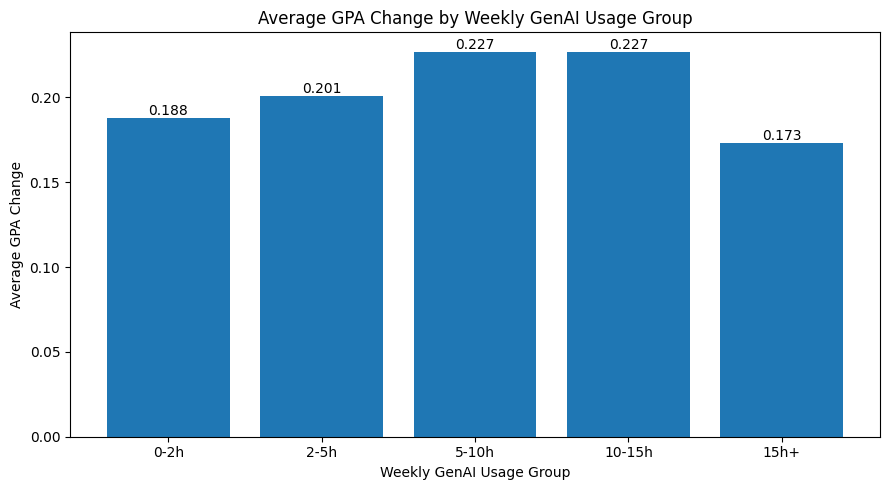

In [101]:
gpa_values = summary_plot["avg_gpa_change"]

plt.figure(figsize=(9, 5))
plt.bar(summary_plot.index.astype(str), gpa_values)
add_value_labels(gpa_values, decimals=3)

plt.title("Average GPA Change by Weekly GenAI Usage Group")
plt.xlabel("Weekly GenAI Usage Group")
plt.ylabel("Average GPA Change")
plt.tight_layout()

plt.savefig("../reports/figures/avg_gpa_change_by_ai_hours_group.png", dpi=300)
plt.show()

### Interpretation: GPA Change by GenAI Usage

Average GPA change is highest in the 5-10h and 10-15h GenAI usage groups. However, the 15h+ group shows a lower average GPA improvement than the moderate usage groups.

This suggests that the relationship between GenAI usage and GPA improvement is not linear. More GenAI usage is not always associated with better academic improvement.

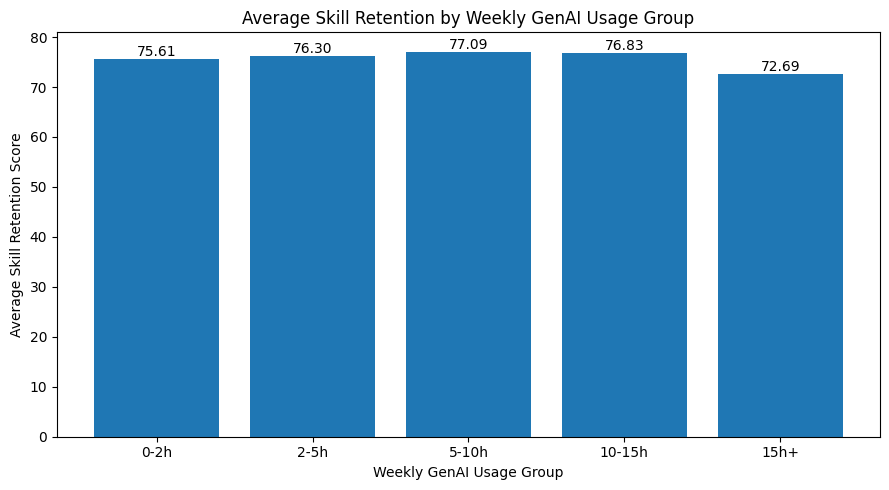

In [102]:
skill_values = summary_plot["avg_skill_retention"]

plt.figure(figsize=(9, 5))
plt.bar(summary_plot.index.astype(str), skill_values)
add_value_labels(skill_values, decimals=2)

plt.title("Average Skill Retention by Weekly GenAI Usage Group")
plt.xlabel("Weekly GenAI Usage Group")
plt.ylabel("Average Skill Retention Score")
plt.tight_layout()

plt.savefig("../reports/figures/avg_skill_retention_by_ai_hours_group.png", dpi=300)
plt.show()

### Interpretation: Skill Retention by GenAI Usage

Skill retention is highest in the moderate GenAI usage groups, especially around 5-10h per week. The 15h+ group shows the lowest average skill retention score.

This pattern suggests that very high GenAI usage may be associated with weaker learning retention compared to moderate usage.

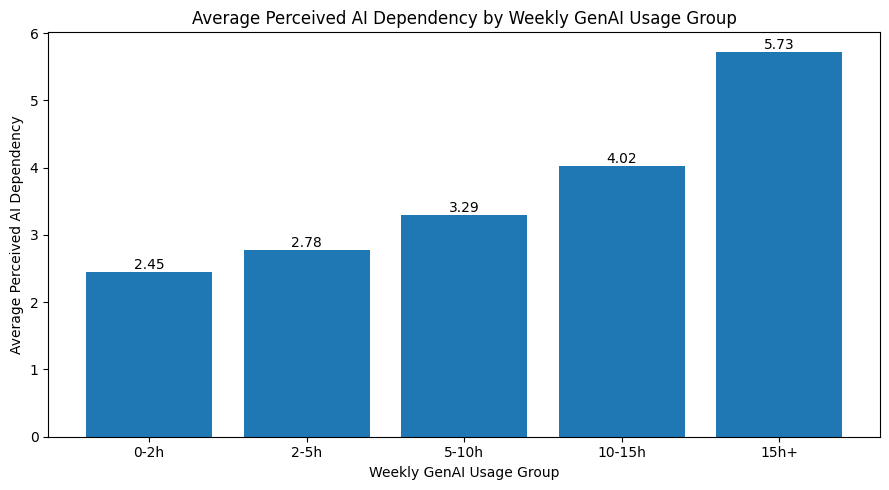

In [103]:
dependency_values = summary_plot["avg_dependency"]

plt.figure(figsize=(9, 5))
plt.bar(summary_plot.index.astype(str), dependency_values)
add_value_labels(dependency_values, decimals=2)

plt.title("Average Perceived AI Dependency by Weekly GenAI Usage Group")
plt.xlabel("Weekly GenAI Usage Group")
plt.ylabel("Average Perceived AI Dependency")
plt.tight_layout()

plt.savefig("../reports/figures/avg_dependency_by_ai_hours_group.png", dpi=300)
plt.show()

### Interpretation: Perceived AI Dependency by GenAI Usage

Perceived AI dependency increases consistently across higher weekly GenAI usage groups. Students in the 15h+ group report the highest average dependency level.

This is expected, but it is important for responsible AI usage discussions because heavier usage is also associated with higher burnout risk.

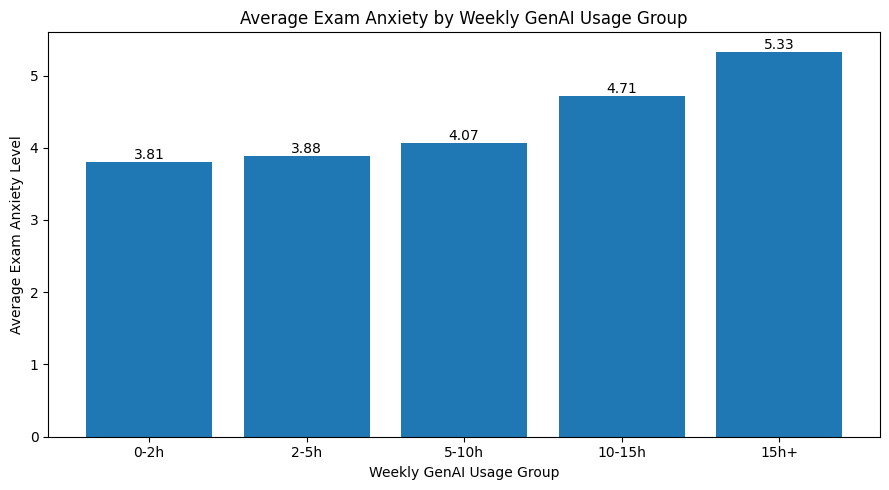

In [104]:
anxiety_values = summary_plot["avg_anxiety"]

plt.figure(figsize=(9, 5))
plt.bar(summary_plot.index.astype(str), anxiety_values)
add_value_labels(anxiety_values, decimals=2)

plt.title("Average Exam Anxiety by Weekly GenAI Usage Group")
plt.xlabel("Weekly GenAI Usage Group")
plt.ylabel("Average Exam Anxiety Level")
plt.tight_layout()

plt.savefig("../reports/figures/avg_exam_anxiety_by_ai_hours_group.png", dpi=300)
plt.show()

### Interpretation: Exam Anxiety by GenAI Usage

Average exam anxiety is higher among heavier GenAI usage groups. The increase becomes more visible in the 10-15h and 15h+ groups.

This does not prove that GenAI usage causes anxiety. It may also mean that students with higher anxiety rely more heavily on GenAI tools.

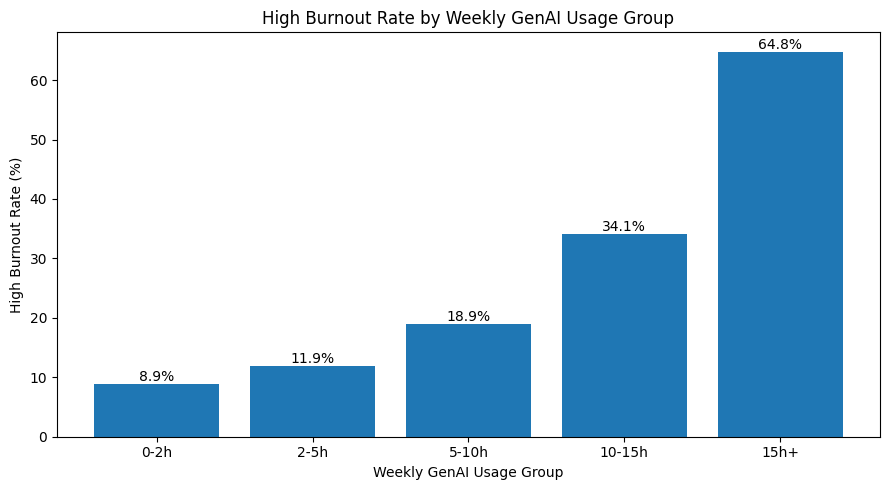

In [106]:
burnout_values = summary_plot["high_burnout_rate_percent"]

plt.figure(figsize=(9, 5))
plt.bar(summary_plot.index.astype(str), burnout_values)
add_value_labels(burnout_values, decimals=1, suffix="%")

plt.title("High Burnout Rate by Weekly GenAI Usage Group")
plt.xlabel("Weekly GenAI Usage Group")
plt.ylabel("High Burnout Rate (%)")
plt.tight_layout()

plt.savefig("../reports/figures/high_burnout_rate_by_ai_hours_group.png", dpi=300)
plt.show()

### Interpretation: High Burnout Rate by GenAI Usage

High burnout risk increases sharply as weekly GenAI usage rises. The 15h+ group has the highest high-burnout rate by a large margin.

This is one of the clearest patterns in the analysis. Very high GenAI usage is strongly associated with a higher share of students in the high burnout risk category.

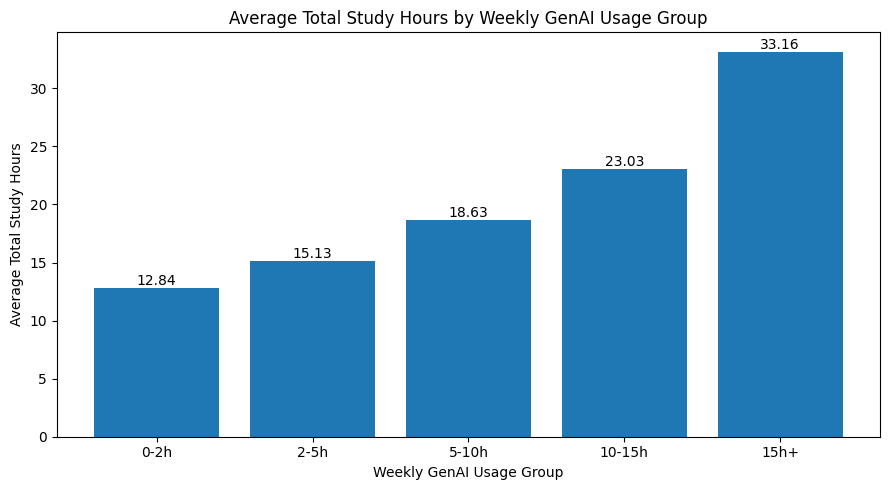

In [108]:
total_study_values = summary_plot["avg_total_study_hours"]

plt.figure(figsize=(9, 5))
plt.bar(summary_plot.index.astype(str), total_study_values)
add_value_labels(total_study_values, decimals=2)

plt.title("Average Total Study Hours by Weekly GenAI Usage Group")
plt.xlabel("Weekly GenAI Usage Group")
plt.ylabel("Average Total Study Hours")
plt.tight_layout()

plt.savefig("../reports/figures/avg_total_study_hours_by_ai_hours_group.png", dpi=300)
plt.show()

### Interpretation: Total Study Hours by GenAI Usage

Average total study hours increase across higher GenAI usage groups. This means that heavy GenAI users are not simply replacing traditional study one-to-one; they also appear to have higher total academic work time.

However, despite higher total study hours, the 15h+ group does not show the strongest GPA improvement or skill retention. This makes the high-usage group especially important for further interpretation.

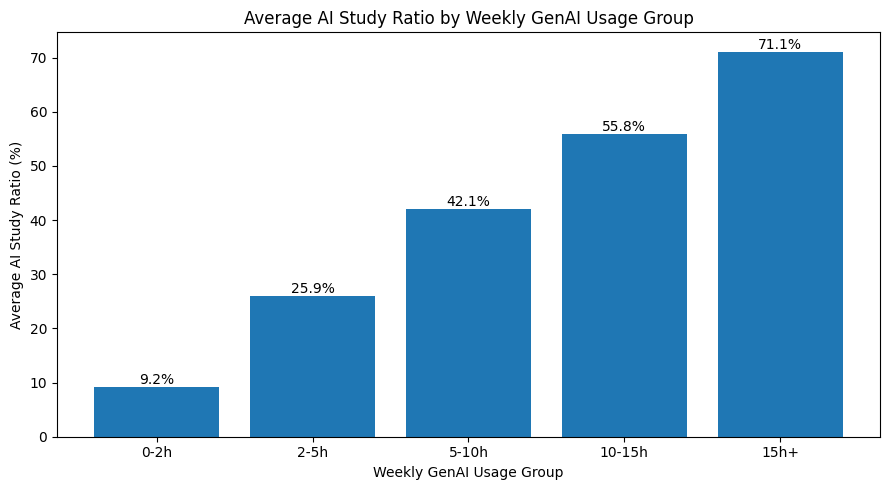

In [109]:
ai_ratio_values = summary_plot["avg_ai_study_ratio_percent"]

plt.figure(figsize=(9, 5))
plt.bar(summary_plot.index.astype(str), ai_ratio_values)
add_value_labels(ai_ratio_values, decimals=1, suffix="%")

plt.title("Average AI Study Ratio by Weekly GenAI Usage Group")
plt.xlabel("Weekly GenAI Usage Group")
plt.ylabel("Average AI Study Ratio (%)")
plt.tight_layout()

plt.savefig("../reports/figures/avg_ai_study_ratio_by_ai_hours_group.png", dpi=300)
plt.show()

### Interpretation: AI Study Ratio by GenAI Usage

The share of total study time spent using GenAI increases strongly across the usage groups. In the 15h+ group, GenAI represents the majority of total study time.

This supports the idea that the 15h+ group is not only using GenAI more often, but also relying on it more heavily as part of its overall study pattern.

In [110]:
os.listdir("../reports/figures")

['avg_ai_study_ratio_by_ai_hours_group.png',
 'avg_dependency_by_ai_hours_group.png',
 'avg_exam_anxiety_by_ai_hours_group.png',
 'avg_gpa_change_by_ai_hours_group.png',
 'avg_skill_retention_by_ai_hours_group.png',
 'avg_total_study_hours_by_ai_hours_group.png',
 'high_burnout_rate_by_ai_hours_group.png']

### Visualization Summary

The visual analysis confirms the main patterns observed in the grouped summary table.

Moderate GenAI usage groups, especially 5-10h and 10-15h per week, show the strongest average GPA improvement. Skill retention is also strongest around moderate usage and drops in the 15h+ group.

The most visible risk pattern is burnout. High burnout risk increases sharply among heavier GenAI usage groups, especially in the 15h+ group. Perceived AI dependency and exam anxiety also rise across higher usage groups.

Overall, the charts suggest that GenAI usage has a non-linear relationship with student outcomes. Moderate usage appears to be associated with stronger academic outcomes, while very high usage is associated with higher dependency, anxiety, and burnout risk.

## 6. Analysis by Primary GenAI Use Case

In this section, we analyze how student outcomes differ depending on the primary purpose of GenAI use.

In [111]:
df_analysis["Primary_Use_Case"].unique()

<StringArray>
['Copywriting/Drafting', 'Ideation', 'Summarizing_Reading', 'Debugging/Troubleshooting', 'Direct_Answer_Generation']
Length: 5, dtype: str

In [112]:
df_analysis["Primary_Use_Case"].value_counts()

Primary_Use_Case
Debugging/Troubleshooting    12295
Copywriting/Drafting         12011
Ideation                     10721
Summarizing_Reading           8633
Direct_Answer_Generation      6340
Name: count, dtype: int64

In [113]:
(df_analysis["Primary_Use_Case"].value_counts(normalize=True) * 100).round(2)

Primary_Use_Case
Debugging/Troubleshooting    24.59
Copywriting/Drafting         24.02
Ideation                     21.44
Summarizing_Reading          17.27
Direct_Answer_Generation     12.68
Name: proportion, dtype: float64

The primary use case groups are large enough for descriptive group comparison. Therefore, we can compare average outcomes across these categories.

In [114]:
summary_by_use_case = df_analysis.groupby("Primary_Use_Case").agg(
    students=("Student_ID", "count"),
    avg_ai_hours=("Weekly_GenAI_Hours", "mean"),
    avg_traditional_hours=("Traditional_Study_Hours", "mean"),
    avg_total_study_hours=("Total_Study_Hours", "mean"),
    avg_ai_study_ratio=("AI_Study_Ratio", "mean"),
    avg_gpa_change=("GPA_Change", "mean"),
    avg_skill_retention=("Skill_Retention_Score", "mean"),
    avg_dependency=("Perceived_AI_Dependency", "mean"),
    avg_anxiety=("Anxiety_Level_During_Exams", "mean"),
    high_burnout_rate=("Burnout_Risk_Level", lambda x: (x == "High").mean())
).round(3)

summary_by_use_case

,students,avg_ai_hours,avg_traditional_hours,avg_total_study_hours,avg_ai_study_ratio,avg_gpa_change,avg_skill_retention,avg_dependency,avg_anxiety,high_burnout_rate
Primary_Use_Case,,,,,,,,,,
Copywriting/Drafting,12011,7.628,11.313,18.941,0.361,0.200,75.231,3.389,4.199,0.230
Debugging/Troubleshooting,12295,9.401,11.124,20.525,0.402,0.249,78.069,3.645,4.334,0.273
Direct_Answer_Generation,6340,8.456,11.217,19.673,0.379,0.133,73.719,3.491,4.286,0.266
Ideation,10721,8.398,11.142,19.540,0.382,0.200,75.520,3.499,4.267,0.244
Summarizing_Reading,8633,8.170,11.263,19.434,0.374,0.197,75.225,3.488,4.273,0.240


In [115]:
summary_by_use_case_sorted = summary_by_use_case.sort_values(
    "avg_gpa_change",
    ascending=False
)

summary_by_use_case_sorted

,students,avg_ai_hours,avg_traditional_hours,avg_total_study_hours,avg_ai_study_ratio,avg_gpa_change,avg_skill_retention,avg_dependency,avg_anxiety,high_burnout_rate
Primary_Use_Case,,,,,,,,,,
Debugging/Troubleshooting,12295,9.401,11.124,20.525,0.402,0.249,78.069,3.645,4.334,0.273
Copywriting/Drafting,12011,7.628,11.313,18.941,0.361,0.200,75.231,3.389,4.199,0.230
Ideation,10721,8.398,11.142,19.540,0.382,0.200,75.520,3.499,4.267,0.244
Summarizing_Reading,8633,8.170,11.263,19.434,0.374,0.197,75.225,3.488,4.273,0.240
Direct_Answer_Generation,6340,8.456,11.217,19.673,0.379,0.133,73.719,3.491,4.286,0.266


In [116]:
summary_by_use_case_display = summary_by_use_case_sorted.copy()

summary_by_use_case_display["avg_ai_study_ratio_percent"] = (
    summary_by_use_case_display["avg_ai_study_ratio"] * 100
).round(1)

summary_by_use_case_display["high_burnout_rate_percent"] = (
    summary_by_use_case_display["high_burnout_rate"] * 100
).round(1)

summary_by_use_case_display = summary_by_use_case_display[
    [
        "students",
        "avg_ai_hours",
        "avg_traditional_hours",
        "avg_total_study_hours",
        "avg_ai_study_ratio_percent",
        "avg_gpa_change",
        "avg_skill_retention",
        "avg_dependency",
        "avg_anxiety",
        "high_burnout_rate_percent"
    ]
]

summary_by_use_case_display

,students,avg_ai_hours,avg_traditional_hours,avg_total_study_hours,avg_ai_study_ratio_percent,avg_gpa_change,avg_skill_retention,avg_dependency,avg_anxiety,high_burnout_rate_percent
Primary_Use_Case,,,,,,,,,,
Debugging/Troubleshooting,12295,9.401,11.124,20.525,40.2,0.249,78.069,3.645,4.334,27.3
Copywriting/Drafting,12011,7.628,11.313,18.941,36.1,0.200,75.231,3.389,4.199,23.0
Ideation,10721,8.398,11.142,19.540,38.2,0.200,75.520,3.499,4.267,24.4
Summarizing_Reading,8633,8.170,11.263,19.434,37.4,0.197,75.225,3.488,4.273,24.0
Direct_Answer_Generation,6340,8.456,11.217,19.673,37.9,0.133,73.719,3.491,4.286,26.6


In [117]:
summary_by_use_case_display.to_csv(
    "../reports/tables/summary_by_primary_use_case.csv"
)

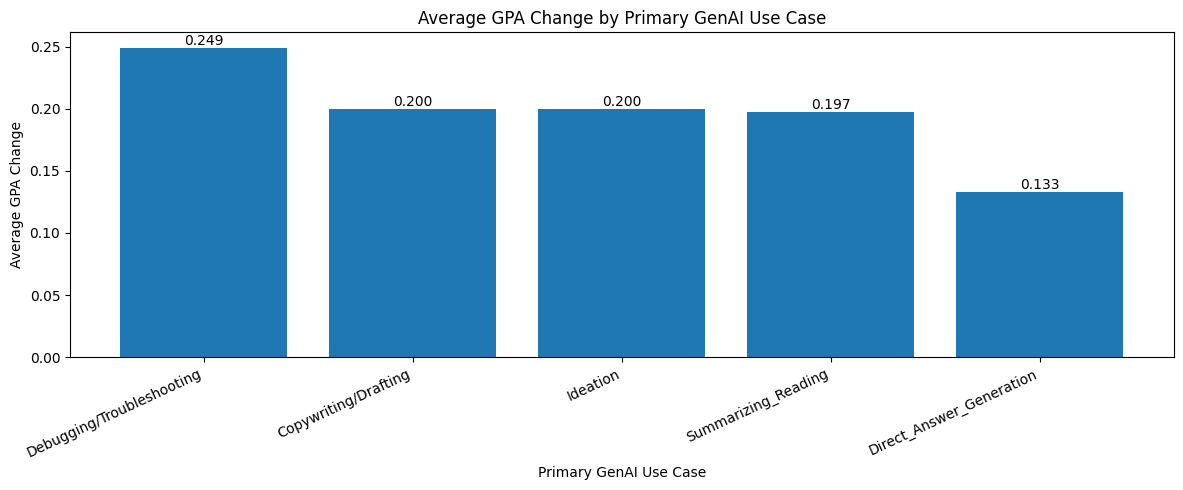

In [118]:
gpa_by_use_case = summary_by_use_case_sorted["avg_gpa_change"]

plt.figure(figsize=(12, 5))
plt.bar(gpa_by_use_case.index.astype(str), gpa_by_use_case.values)

for index, value in enumerate(gpa_by_use_case.values):
    plt.text(
        index,
        value,
        f"{value:.3f}",
        ha="center",
        va="bottom"
    )

plt.title("Average GPA Change by Primary GenAI Use Case")
plt.xlabel("Primary GenAI Use Case")
plt.ylabel("Average GPA Change")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()

plt.savefig("../reports/figures/avg_gpa_change_by_primary_use_case.png", dpi=300)
plt.show()

### Interpretation: GPA Change by Primary Use Case

Students who primarily use GenAI for Debugging/Troubleshooting show the highest average GPA improvement. Students who primarily use GenAI for Direct Answer Generation show the lowest average GPA improvement.

This suggests that GenAI may be more academically useful when used as a problem-solving assistant rather than as a direct answer generator.

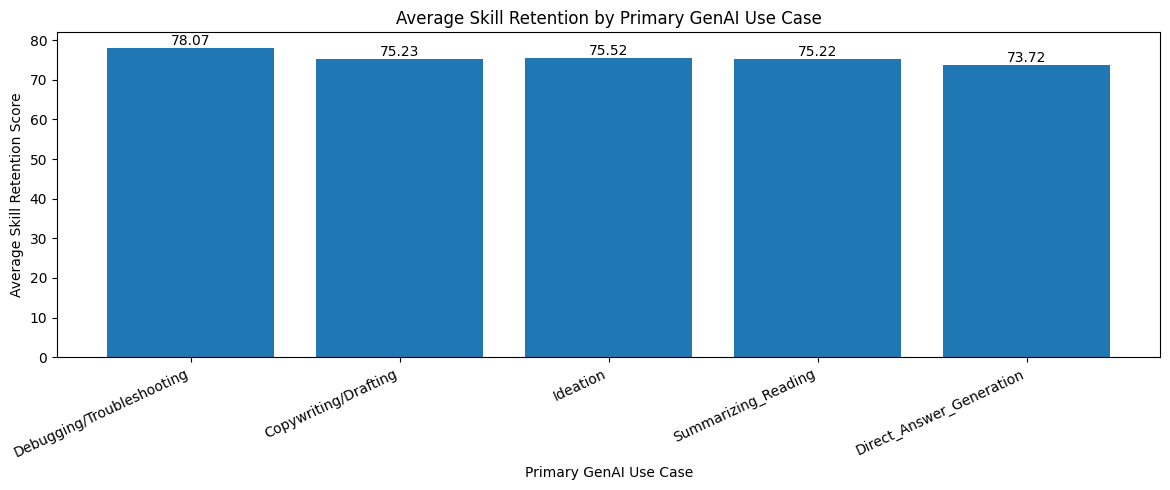

In [119]:
skill_by_use_case = summary_by_use_case_sorted["avg_skill_retention"]

plt.figure(figsize=(12, 5))
plt.bar(skill_by_use_case.index.astype(str), skill_by_use_case.values)

for index, value in enumerate(skill_by_use_case.values):
    plt.text(
        index,
        value,
        f"{value:.2f}",
        ha="center",
        va="bottom"
    )

plt.title("Average Skill Retention by Primary GenAI Use Case")
plt.xlabel("Primary GenAI Use Case")
plt.ylabel("Average Skill Retention Score")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()

plt.savefig("../reports/figures/avg_skill_retention_by_primary_use_case.png", dpi=300)
plt.show()

### Interpretation: Skill Retention by Primary Use Case

Debugging/Troubleshooting is associated with the highest average skill retention score. Direct Answer Generation is associated with one of the weakest skill retention outcomes.

This supports the idea that active, problem-solving-oriented GenAI use may be more beneficial for learning retention than passive answer-seeking behavior.

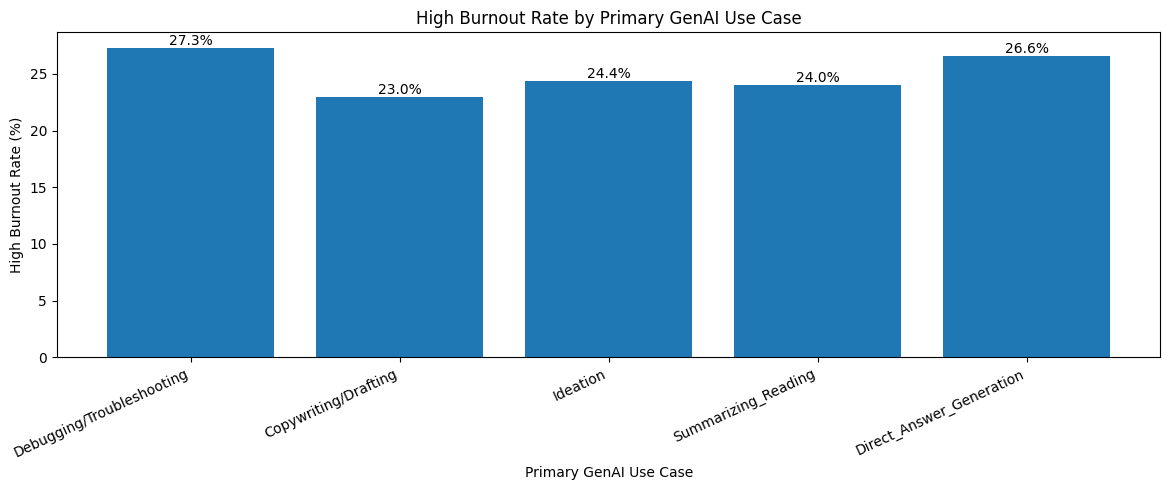

In [120]:
burnout_by_use_case = summary_by_use_case_display["high_burnout_rate_percent"]

plt.figure(figsize=(12, 5))
plt.bar(burnout_by_use_case.index.astype(str), burnout_by_use_case.values)

for index, value in enumerate(burnout_by_use_case.values):
    plt.text(
        index,
        value,
        f"{value:.1f}%",
        ha="center",
        va="bottom"
    )

plt.title("High Burnout Rate by Primary GenAI Use Case")
plt.xlabel("Primary GenAI Use Case")
plt.ylabel("High Burnout Rate (%)")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()

plt.savefig("../reports/figures/high_burnout_rate_by_primary_use_case.png", dpi=300)
plt.show()

### Interpretation: Burnout Risk by Primary Use Case

Burnout risk differs across primary GenAI use cases. Use cases associated with heavier reliance on AI should be interpreted carefully alongside AI usage hours, dependency, and anxiety.

This descriptive comparison does not prove that a specific use case causes burnout, but it helps identify which usage patterns may be associated with higher student well-being risks.

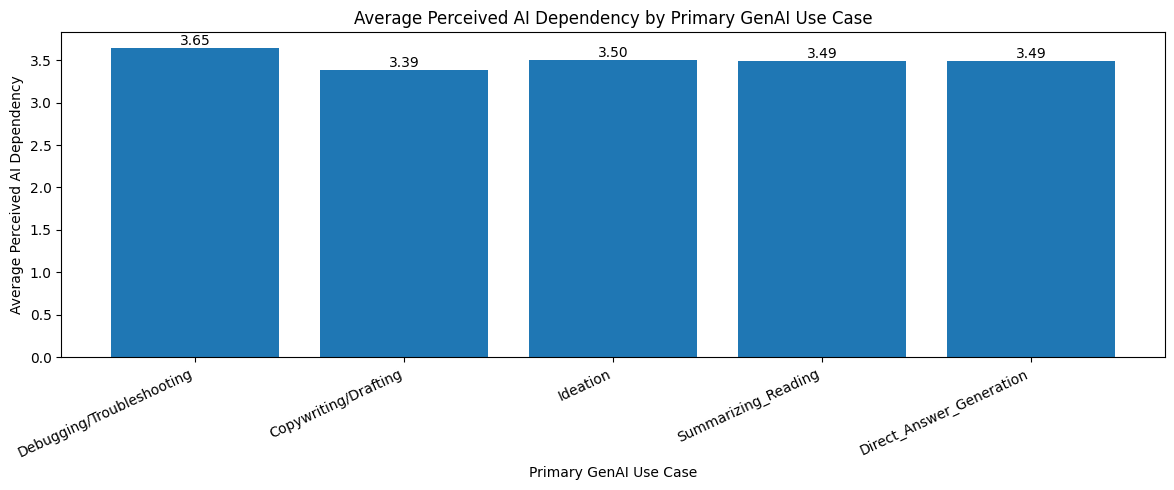

In [121]:
dependency_by_use_case = summary_by_use_case_sorted["avg_dependency"]

plt.figure(figsize=(12, 5))
plt.bar(dependency_by_use_case.index.astype(str), dependency_by_use_case.values)

for index, value in enumerate(dependency_by_use_case.values):
    plt.text(
        index,
        value,
        f"{value:.2f}",
        ha="center",
        va="bottom"
    )

plt.title("Average Perceived AI Dependency by Primary GenAI Use Case")
plt.xlabel("Primary GenAI Use Case")
plt.ylabel("Average Perceived AI Dependency")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()

plt.savefig("../reports/figures/avg_dependency_by_primary_use_case.png", dpi=300)
plt.show()

### Interpretation: AI Dependency by Primary Use Case

Perceived AI dependency varies by primary use case. This is important because academic outcomes should be interpreted together with student reliance patterns, not only with GPA improvement.

A use case may appear academically useful, but if it is also linked to higher dependency or burnout risk, it may require more careful guidance.

In [123]:
gpa_category_by_use_case = pd.crosstab(
    df_analysis["Primary_Use_Case"],
    df_analysis["GPA_Change_Category"],
    normalize="index"
) * 100

gpa_category_by_use_case = gpa_category_by_use_case[
    ["Declined", "Stable", "Improved"]
]

gpa_category_by_use_case.round(2)

GPA_Change_Category,Declined,Stable,Improved
Primary_Use_Case,,,
Copywriting/Drafting,6.95,11.02,82.02
Debugging/Troubleshooting,5.50,8.84,85.66
Direct_Answer_Generation,17.87,12.13,70.00
Ideation,6.90,11.27,81.83
Summarizing_Reading,7.31,12.07,80.62


In [124]:
gpa_category_by_use_case.round(2).to_csv(
    "../reports/tables/gpa_change_category_by_primary_use_case.csv"
)

In [125]:
burnout_distribution_by_use_case = pd.crosstab(
    df_analysis["Primary_Use_Case"],
    df_analysis["Burnout_Risk_Level"],
    normalize="index"
) * 100

burnout_distribution_by_use_case = burnout_distribution_by_use_case[
    ["Low", "Medium", "High"]
]

burnout_distribution_by_use_case.round(2)

Burnout_Risk_Level,Low,Medium,High
Primary_Use_Case,,,
Copywriting/Drafting,33.94,43.08,22.99
Debugging/Troubleshooting,31.09,41.63,27.28
Direct_Answer_Generation,31.88,41.51,26.61
Ideation,33.04,42.61,24.35
Summarizing_Reading,33.68,42.29,24.02


In [126]:
burnout_distribution_by_use_case.round(2).to_csv(
    "../reports/tables/burnout_distribution_by_primary_use_case.csv"
)

In [127]:
comparison_use_cases = [
    "Debugging/Troubleshooting",
    "Direct_Answer_Generation"
]

debugging_vs_direct = summary_by_use_case_display.loc[comparison_use_cases]

debugging_vs_direct

,students,avg_ai_hours,avg_traditional_hours,avg_total_study_hours,avg_ai_study_ratio_percent,avg_gpa_change,avg_skill_retention,avg_dependency,avg_anxiety,high_burnout_rate_percent
Primary_Use_Case,,,,,,,,,,
Debugging/Troubleshooting,12295,9.401,11.124,20.525,40.2,0.249,78.069,3.645,4.334,27.3
Direct_Answer_Generation,6340,8.456,11.217,19.673,37.9,0.133,73.719,3.491,4.286,26.6


In [128]:
debugging_values = summary_by_use_case_display.loc["Debugging/Troubleshooting"]
direct_values = summary_by_use_case_display.loc["Direct_Answer_Generation"]

use_case_difference = debugging_values - direct_values

use_case_difference[
    [
        "avg_gpa_change",
        "avg_skill_retention",
        "avg_dependency",
        "avg_anxiety",
        "high_burnout_rate_percent"
    ]
]

avg_gpa_change               0.116
avg_skill_retention          4.350
avg_dependency               0.154
avg_anxiety                  0.048
high_burnout_rate_percent    0.700
dtype: float64

In [129]:
use_case_difference.to_csv(
    "../reports/tables/debugging_vs_direct_answer_difference.csv"
)

### Debugging/Troubleshooting vs Direct Answer Generation

The contrast between Debugging/Troubleshooting and Direct Answer Generation is especially important.

Debugging/Troubleshooting is associated with stronger GPA improvement and higher skill retention. Direct Answer Generation is associated with weaker academic improvement and lower skill retention.

This suggests that the educational value of GenAI depends heavily on how students use it. GenAI appears more useful when it supports active problem solving, rather than replacing the student's own reasoning process.

### Key Insight: Use Case Matters

The analysis by primary GenAI use case shows that student outcomes differ meaningfully depending on how GenAI is used.

Debugging/Troubleshooting is associated with the strongest academic outcome pattern, including the highest average GPA change and the highest average skill retention score. In contrast, Direct Answer Generation is associated with the weakest GPA improvement and lower skill retention.

This suggests that GenAI should not be treated as a single uniform behavior. Using GenAI as a learning assistant or problem-solving support tool appears different from using it mainly to generate direct answers.

For educational institutions, this supports the idea that AI literacy should focus not only on whether students use AI, but also on how they use it.

## 7. Analysis by Prompt Engineering Skill

In this section, we analyze how student outcomes differ by prompt engineering skill level.

In [130]:
df_analysis.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level,GPA_Change,GPA_Change_Category,Total_Study_Hours,AI_Study_Ratio,AI_Study_Ratio_Percent,AI_Hours_Group,AI_Usage_Intensity,Traditional_Study_Group,Study_Profile
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High,-0.025,Stable,31.44,0.741412,74.141221,15h+,Very High,5-10h,AI-Heavy
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low,-0.125,Declined,17.77,0.063028,6.302757,0-2h,Very Low,15-20h,Mostly Traditional
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium,0.101,Improved,31.61,0.672572,67.257197,15h+,Very High,10-15h,AI-Heavy
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium,0.211,Improved,17.05,0.106745,10.674487,0-2h,Very Low,15-20h,Mostly Traditional
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium,0.163,Improved,21.84,0.425366,42.536630,5-10h,Moderate,10-15h,Balanced


In [131]:
df_analysis["Prompt_Engineering_Skill"].unique()

<StringArray>
['Beginner', 'Advanced', 'Intermediate']
Length: 3, dtype: str

In [132]:
df_analysis["Prompt_Engineering_Skill"].value_counts()

Prompt_Engineering_Skill
Beginner        18495
Intermediate    17696
Advanced        13809
Name: count, dtype: int64

In [133]:
(df_analysis["Prompt_Engineering_Skill"].value_counts(normalize=True) * 100).round(2)

Prompt_Engineering_Skill
Beginner        36.99
Intermediate    35.39
Advanced        27.62
Name: proportion, dtype: float64

Prompt engineering skill groups are large enough for descriptive comparison. The Advanced group is smaller than the Beginner and Intermediate groups, but still contains enough records for stable group-level analysis.

In [134]:
prompt_skill_order = ["Beginner", "Intermediate", "Advanced"]

df_analysis["Prompt_Engineering_Skill"] = pd.Categorical(
    df_analysis["Prompt_Engineering_Skill"],
    categories=prompt_skill_order,
    ordered=True
)

In [135]:
df_analysis["Prompt_Engineering_Skill"].value_counts().sort_index()

Prompt_Engineering_Skill
Beginner        18495
Intermediate    17696
Advanced        13809
Name: count, dtype: int64

In [136]:
summary_by_prompt_skill = df_analysis.groupby(
    "Prompt_Engineering_Skill",
    observed=False
).agg(
    students=("Student_ID", "count"),
    avg_ai_hours=("Weekly_GenAI_Hours", "mean"),
    avg_traditional_hours=("Traditional_Study_Hours", "mean"),
    avg_total_study_hours=("Total_Study_Hours", "mean"),
    avg_ai_study_ratio=("AI_Study_Ratio", "mean"),
    avg_gpa_change=("GPA_Change", "mean"),
    avg_skill_retention=("Skill_Retention_Score", "mean"),
    avg_dependency=("Perceived_AI_Dependency", "mean"),
    avg_anxiety=("Anxiety_Level_During_Exams", "mean"),
    high_burnout_rate=("Burnout_Risk_Level", lambda x: (x == "High").mean())
).round(3)

summary_by_prompt_skill

,students,avg_ai_hours,avg_traditional_hours,avg_total_study_hours,avg_ai_study_ratio,avg_gpa_change,avg_skill_retention,avg_dependency,avg_anxiety,high_burnout_rate
Prompt_Engineering_Skill,,,,,,,,,,
Beginner,18495,8.286,11.204,19.491,0.378,0.185,71.101,3.493,4.263,0.246
Intermediate,17696,8.367,11.237,19.604,0.378,0.187,75.825,3.502,4.273,0.249
Advanced,13809,8.694,11.181,19.875,0.386,0.248,82.054,3.526,4.278,0.255


In [137]:
summary_by_prompt_skill_display = summary_by_prompt_skill.copy()

summary_by_prompt_skill_display["avg_ai_study_ratio_percent"] = (
    summary_by_prompt_skill_display["avg_ai_study_ratio"] * 100
).round(1)

summary_by_prompt_skill_display["high_burnout_rate_percent"] = (
    summary_by_prompt_skill_display["high_burnout_rate"] * 100
).round(1)

summary_by_prompt_skill_display = summary_by_prompt_skill_display[
    [
        "students",
        "avg_ai_hours",
        "avg_traditional_hours",
        "avg_total_study_hours",
        "avg_ai_study_ratio_percent",
        "avg_gpa_change",
        "avg_skill_retention",
        "avg_dependency",
        "avg_anxiety",
        "high_burnout_rate_percent"
    ]
]

summary_by_prompt_skill_display

,students,avg_ai_hours,avg_traditional_hours,avg_total_study_hours,avg_ai_study_ratio_percent,avg_gpa_change,avg_skill_retention,avg_dependency,avg_anxiety,high_burnout_rate_percent
Prompt_Engineering_Skill,,,,,,,,,,
Beginner,18495,8.286,11.204,19.491,37.8,0.185,71.101,3.493,4.263,24.6
Intermediate,17696,8.367,11.237,19.604,37.8,0.187,75.825,3.502,4.273,24.9
Advanced,13809,8.694,11.181,19.875,38.6,0.248,82.054,3.526,4.278,25.5


In [138]:
summary_by_prompt_skill_display.to_csv(
    "../reports/tables/summary_by_prompt_engineering_skill.csv"
)

### Initial Findings by Prompt Engineering Skill

Prompt engineering skill is associated with clear differences in academic outcomes.

Advanced prompt users show higher average GPA improvement and substantially higher skill retention than beginner and intermediate users. The difference is especially strong for skill retention.

However, perceived AI dependency, exam anxiety, and high burnout risk are relatively similar across prompt skill groups. This suggests that prompt skill is more strongly related to learning outcomes than to well-being risk indicators in this dataset.

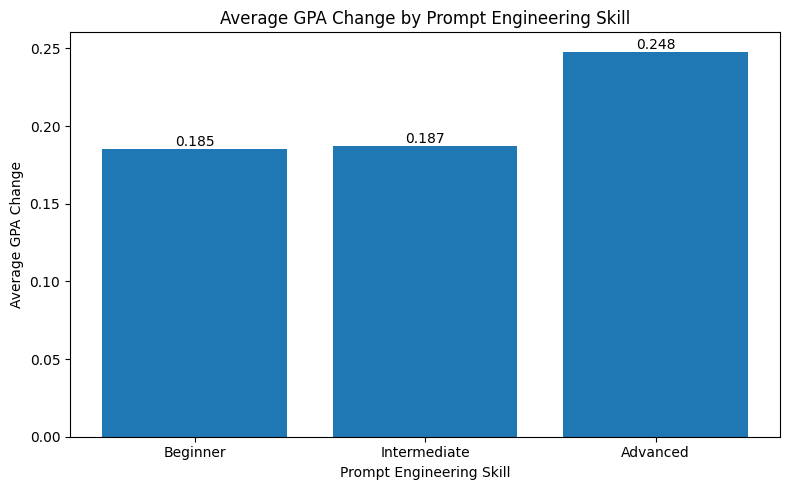

In [139]:
gpa_by_prompt_skill = summary_by_prompt_skill_display["avg_gpa_change"]

plt.figure(figsize=(8, 5))
plt.bar(gpa_by_prompt_skill.index.astype(str), gpa_by_prompt_skill.values)

for index, value in enumerate(gpa_by_prompt_skill.values):
    plt.text(
        index,
        value,
        f"{value:.3f}",
        ha="center",
        va="bottom"
    )

plt.title("Average GPA Change by Prompt Engineering Skill")
plt.xlabel("Prompt Engineering Skill")
plt.ylabel("Average GPA Change")
plt.tight_layout()

plt.savefig("../reports/figures/avg_gpa_change_by_prompt_skill.png", dpi=300)
plt.show()

### Interpretation: GPA Change by Prompt Skill

Advanced prompt users show higher average GPA improvement than beginner and intermediate users.

This suggests that students who are better at interacting with GenAI tools may be able to use them more effectively for academic improvement.

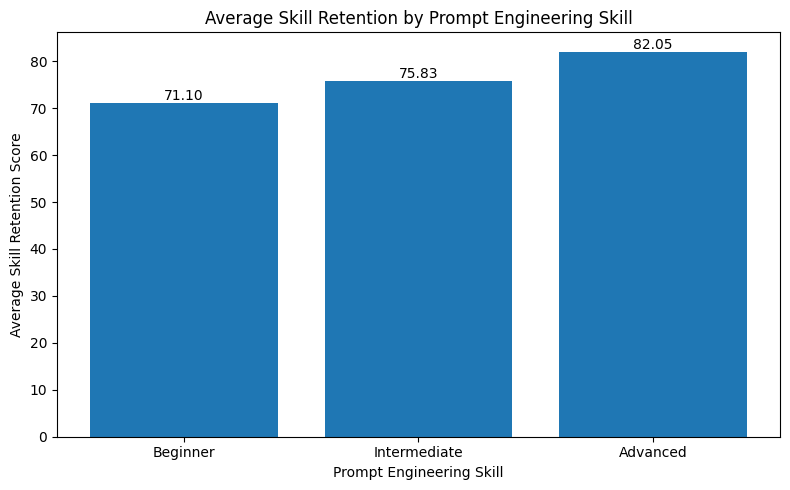

In [140]:
skill_by_prompt_skill = summary_by_prompt_skill_display["avg_skill_retention"]

plt.figure(figsize=(8, 5))
plt.bar(skill_by_prompt_skill.index.astype(str), skill_by_prompt_skill.values)

for index, value in enumerate(skill_by_prompt_skill.values):
    plt.text(
        index,
        value,
        f"{value:.2f}",
        ha="center",
        va="bottom"
    )

plt.title("Average Skill Retention by Prompt Engineering Skill")
plt.xlabel("Prompt Engineering Skill")
plt.ylabel("Average Skill Retention Score")
plt.tight_layout()

plt.savefig("../reports/figures/avg_skill_retention_by_prompt_skill.png", dpi=300)
plt.show()

### Interpretation: Skill Retention by Prompt Skill

Skill retention increases clearly across prompt engineering skill levels. Advanced prompt users have the highest average skill retention score, while beginner users have the lowest.

This is one of the strongest learning-related patterns in the analysis. It suggests that AI literacy and prompting ability may be important for using GenAI in a way that supports durable learning.

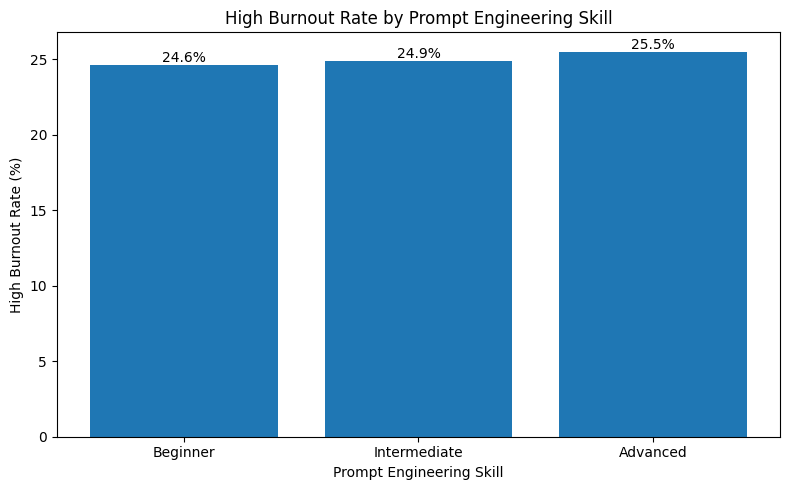

In [142]:
burnout_by_prompt_skill = summary_by_prompt_skill_display["high_burnout_rate_percent"]

plt.figure(figsize=(8, 5))
plt.bar(burnout_by_prompt_skill.index.astype(str), burnout_by_prompt_skill.values)

for index, value in enumerate(burnout_by_prompt_skill.values):
    plt.text(
        index,
        value,
        f"{value:.1f}%",
        ha="center",
        va="bottom"
    )

plt.title("High Burnout Rate by Prompt Engineering Skill")
plt.xlabel("Prompt Engineering Skill")
plt.ylabel("High Burnout Rate (%)")
plt.tight_layout()

plt.savefig("../reports/figures/high_burnout_rate_by_prompt_skill.png", dpi=300)
plt.show()

### Interpretation: Burnout Risk by Prompt Skill

High burnout risk is relatively similar across prompt engineering skill groups. Unlike skill retention, burnout risk does not show a large difference by prompt skill level.

This suggests that burnout risk may be more strongly related to usage intensity and dependency patterns than to prompt skill alone.

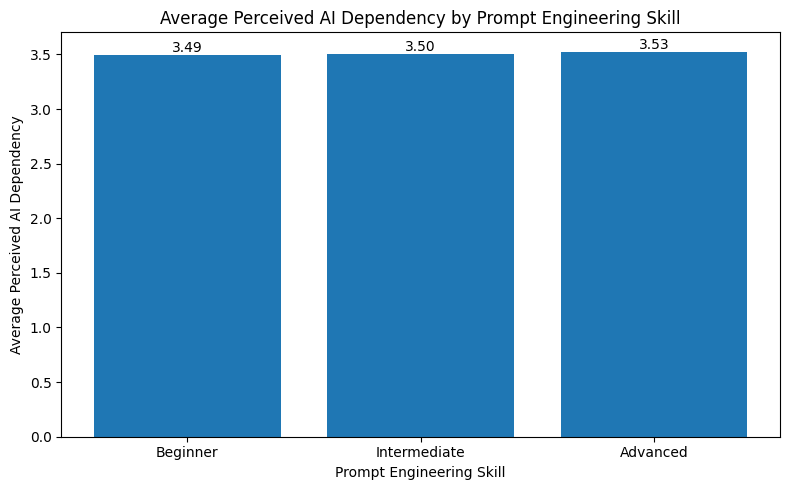

In [143]:
dependency_by_prompt_skill = summary_by_prompt_skill_display["avg_dependency"]

plt.figure(figsize=(8, 5))
plt.bar(dependency_by_prompt_skill.index.astype(str), dependency_by_prompt_skill.values)

for index, value in enumerate(dependency_by_prompt_skill.values):
    plt.text(
        index,
        value,
        f"{value:.2f}",
        ha="center",
        va="bottom"
    )

plt.title("Average Perceived AI Dependency by Prompt Engineering Skill")
plt.xlabel("Prompt Engineering Skill")
plt.ylabel("Average Perceived AI Dependency")
plt.tight_layout()

plt.savefig("../reports/figures/avg_dependency_by_prompt_skill.png", dpi=300)
plt.show()

### Interpretation: AI Dependency by Prompt Skill

Average perceived AI dependency is very similar across prompt engineering skill levels. Advanced prompt users do not appear to have dramatically lower dependency in this dataset.

This means that higher prompt skill may improve learning-related outcomes, but it does not automatically eliminate perceived reliance on AI tools.

In [144]:
gpa_category_by_prompt_skill = pd.crosstab(
    df_analysis["Prompt_Engineering_Skill"],
    df_analysis["GPA_Change_Category"],
    normalize="index"
) * 100

gpa_category_by_prompt_skill = gpa_category_by_prompt_skill[
    ["Declined", "Stable", "Improved"]
]

gpa_category_by_prompt_skill.round(2)

GPA_Change_Category,Declined,Stable,Improved
Prompt_Engineering_Skill,,,
Beginner,8.80,12.02,79.18
Intermediate,8.95,11.71,79.34
Advanced,5.82,8.22,85.97


In [145]:
gpa_category_by_prompt_skill.round(2).to_csv(
    "../reports/tables/gpa_change_category_by_prompt_skill.csv"
)

In [146]:
burnout_distribution_by_prompt_skill = pd.crosstab(
    df_analysis["Prompt_Engineering_Skill"],
    df_analysis["Burnout_Risk_Level"],
    normalize="index"
) * 100

burnout_distribution_by_prompt_skill = burnout_distribution_by_prompt_skill[
    ["Low", "Medium", "High"]
]

burnout_distribution_by_prompt_skill.round(2)

Burnout_Risk_Level,Low,Medium,High
Prompt_Engineering_Skill,,,
Beginner,33.06,42.30,24.64
Intermediate,32.94,42.16,24.90
Advanced,32.04,42.44,25.51


In [147]:
burnout_distribution_by_prompt_skill.round(2).to_csv(
    "../reports/tables/burnout_distribution_by_prompt_skill.csv"
)

In [148]:
beginner_values = summary_by_prompt_skill_display.loc["Beginner"]
advanced_values = summary_by_prompt_skill_display.loc["Advanced"]

advanced_minus_beginner = advanced_values - beginner_values

advanced_minus_beginner[
    [
        "avg_gpa_change",
        "avg_skill_retention",
        "avg_dependency",
        "avg_anxiety",
        "high_burnout_rate_percent"
    ]
]

avg_gpa_change                0.063
avg_skill_retention          10.953
avg_dependency                0.033
avg_anxiety                   0.015
high_burnout_rate_percent     0.900
dtype: float64

In [149]:
advanced_minus_beginner.to_csv(
    "../reports/tables/advanced_vs_beginner_prompt_skill_difference.csv"
)

### Advanced vs Beginner Prompt Skill

The difference between Advanced and Beginner prompt users is most visible in learning-related outcomes.

Advanced prompt users show higher average GPA improvement and much higher skill retention. The skill retention gap is especially large, suggesting that prompt engineering skill may be an important part of effective AI-supported learning.

The differences in dependency, anxiety, and burnout risk are much smaller, which suggests that prompt skill alone does not fully explain student well-being risks.

### Key Insight: Prompt Skill Matters for Learning Quality

Prompt engineering skill appears to be strongly associated with learning quality.

Advanced prompt users show substantially higher skill retention and higher GPA improvement compared to beginner users. This suggests that students may benefit more from GenAI when they know how to ask better questions, refine prompts, evaluate AI outputs, and use the tool as part of an active learning process.

However, prompt skill does not appear to dramatically reduce burnout risk or perceived AI dependency. Therefore, responsible GenAI education should combine prompt literacy with workload management, academic integrity guidance, and healthy study habits.

## 8. Traditional Study, AI Study Ratio, and Study Profile Analysis

In this section, we analyze whether traditional study time still matters in an AI-supported learning environment. We also compare students based on whether their study pattern is mostly traditional, balanced, or AI-heavy.

In [150]:
df_analysis.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level,GPA_Change,GPA_Change_Category,Total_Study_Hours,AI_Study_Ratio,AI_Study_Ratio_Percent,AI_Hours_Group,AI_Usage_Intensity,Traditional_Study_Group,Study_Profile
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High,-0.025,Stable,31.44,0.741412,74.141221,15h+,Very High,5-10h,AI-Heavy
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low,-0.125,Declined,17.77,0.063028,6.302757,0-2h,Very Low,15-20h,Mostly Traditional
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium,0.101,Improved,31.61,0.672572,67.257197,15h+,Very High,10-15h,AI-Heavy
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium,0.211,Improved,17.05,0.106745,10.674487,0-2h,Very Low,15-20h,Mostly Traditional
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium,0.163,Improved,21.84,0.425366,42.536630,5-10h,Moderate,10-15h,Balanced


In [151]:
study_columns = [
    "Traditional_Study_Hours",
    "Traditional_Study_Group",
    "Weekly_GenAI_Hours",
    "Total_Study_Hours",
    "AI_Study_Ratio",
    "AI_Study_Ratio_Percent",
    "Study_Profile",
    "GPA_Change",
    "Skill_Retention_Score",
    "Burnout_Risk_Level"
]

df_analysis[study_columns].head(10)

,Traditional_Study_Hours,Traditional_Study_Group,Weekly_GenAI_Hours,Total_Study_Hours,AI_Study_Ratio,AI_Study_Ratio_Percent,Study_Profile,GPA_Change,Skill_Retention_Score,Burnout_Risk_Level
0,8.13,5-10h,23.31,31.44,0.741412,74.141221,AI-Heavy,-0.025,86.44,High
1,16.65,15-20h,1.12,17.77,0.063028,6.302757,Mostly Traditional,-0.125,69.39,Low
2,10.35,10-15h,21.26,31.61,0.672572,67.257197,AI-Heavy,0.101,73.93,Medium
3,15.23,15-20h,1.82,17.05,0.106745,10.674487,Mostly Traditional,0.211,63.58,Medium
4,12.55,10-15h,9.29,21.84,0.425366,42.536630,Balanced,0.163,100.00,Medium
5,14.19,10-15h,6.50,20.69,0.314161,31.416143,Balanced,0.217,65.92,High
6,13.11,10-15h,31.41,44.52,0.705526,70.552561,AI-Heavy,0.378,67.97,Medium
7,18.45,15-20h,5.33,23.78,0.224138,22.413793,Mostly Traditional,0.219,85.09,Medium
8,2.87,0-5h,2.00,4.87,0.410678,41.067762,Balanced,-0.024,55.71,Medium
9,12.49,10-15h,19.99,32.48,0.615456,61.545567,AI-Heavy,-0.068,87.18,High


In [152]:
traditional_study_order = ["0-5h", "5-10h", "10-15h", "15-20h", "20h+"]

df_analysis["Traditional_Study_Group"] = pd.Categorical(
    df_analysis["Traditional_Study_Group"],
    categories=traditional_study_order,
    ordered=True
)

In [153]:
df_analysis["Traditional_Study_Group"].value_counts().sort_index()

Traditional_Study_Group
0-5h       6167
5-10h     14427
10-15h    17716
15-20h     9411
20h+       2279
Name: count, dtype: int64

In [154]:
study_profile_order = ["Mostly Traditional", "Balanced", "AI-Heavy"]

df_analysis["Study_Profile"] = pd.Categorical(
    df_analysis["Study_Profile"],
    categories=study_profile_order,
    ordered=True
)

In [155]:
df_analysis["Traditional_Study_Group"].value_counts().sort_index()

Traditional_Study_Group
0-5h       6167
5-10h     14427
10-15h    17716
15-20h     9411
20h+       2279
Name: count, dtype: int64

In [156]:
traditional_group_distribution = (
    df_analysis["Traditional_Study_Group"]
    .value_counts(normalize=True)
    .sort_index() * 100
).round(2)

traditional_group_distribution

Traditional_Study_Group
0-5h      12.33
5-10h     28.85
10-15h    35.43
15-20h    18.82
20h+       4.56
Name: proportion, dtype: float64

Traditional study groups are used to compare academic and well-being outcomes across different levels of non-AI study effort.

In [157]:
df_analysis["Study_Profile"].value_counts().sort_index()

Study_Profile
Mostly Traditional    17980
Balanced              16151
AI-Heavy              15869
Name: count, dtype: int64

In [158]:
study_profile_distribution = (
    df_analysis["Study_Profile"]
    .value_counts(normalize=True)
    .sort_index() * 100
).round(2)

study_profile_distribution

Study_Profile
Mostly Traditional    35.96
Balanced              32.30
AI-Heavy              31.74
Name: proportion, dtype: float64

In [159]:
summary_by_traditional_study = df_analysis.groupby(
    "Traditional_Study_Group",
    observed=False
).agg(
    students=("Student_ID", "count"),
    avg_traditional_hours=("Traditional_Study_Hours", "mean"),
    avg_ai_hours=("Weekly_GenAI_Hours", "mean"),
    avg_total_study_hours=("Total_Study_Hours", "mean"),
    avg_ai_study_ratio=("AI_Study_Ratio", "mean"),
    avg_gpa_change=("GPA_Change", "mean"),
    avg_skill_retention=("Skill_Retention_Score", "mean"),
    avg_dependency=("Perceived_AI_Dependency", "mean"),
    avg_anxiety=("Anxiety_Level_During_Exams", "mean"),
    high_burnout_rate=("Burnout_Risk_Level", lambda x: (x == "High").mean())
).round(3)

summary_by_traditional_study

,students,avg_traditional_hours,avg_ai_hours,avg_total_study_hours,avg_ai_study_ratio,avg_gpa_change,avg_skill_retention,avg_dependency,avg_anxiety,high_burnout_rate
Traditional_Study_Group,,,,,,,,,,
0-5h,6167,2.852,11.043,13.894,0.677,0.086,72.473,3.871,4.414,0.348
5-10h,14427,7.745,9.086,16.831,0.440,0.156,74.423,3.605,4.324,0.284
10-15h,17716,12.417,8.015,20.432,0.324,0.222,76.434,3.444,4.260,0.233
15-20h,9411,17.065,6.983,24.048,0.245,0.282,77.856,3.302,4.150,0.188
20h+,2279,22.187,6.359,28.546,0.193,0.347,80.057,3.197,4.129,0.151


In [160]:
summary_by_traditional_study_display = summary_by_traditional_study.copy()

summary_by_traditional_study_display["avg_ai_study_ratio_percent"] = (
    summary_by_traditional_study_display["avg_ai_study_ratio"] * 100
).round(1)

summary_by_traditional_study_display["high_burnout_rate_percent"] = (
    summary_by_traditional_study_display["high_burnout_rate"] * 100
).round(1)

summary_by_traditional_study_display = summary_by_traditional_study_display[
    [
        "students",
        "avg_traditional_hours",
        "avg_ai_hours",
        "avg_total_study_hours",
        "avg_ai_study_ratio_percent",
        "avg_gpa_change",
        "avg_skill_retention",
        "avg_dependency",
        "avg_anxiety",
        "high_burnout_rate_percent"
    ]
]

summary_by_traditional_study_display

,students,avg_traditional_hours,avg_ai_hours,avg_total_study_hours,avg_ai_study_ratio_percent,avg_gpa_change,avg_skill_retention,avg_dependency,avg_anxiety,high_burnout_rate_percent
Traditional_Study_Group,,,,,,,,,,
0-5h,6167,2.852,11.043,13.894,67.7,0.086,72.473,3.871,4.414,34.8
5-10h,14427,7.745,9.086,16.831,44.0,0.156,74.423,3.605,4.324,28.4
10-15h,17716,12.417,8.015,20.432,32.4,0.222,76.434,3.444,4.260,23.3
15-20h,9411,17.065,6.983,24.048,24.5,0.282,77.856,3.302,4.150,18.8
20h+,2279,22.187,6.359,28.546,19.3,0.347,80.057,3.197,4.129,15.1


In [161]:
summary_by_traditional_study_display.to_csv(
    "../reports/tables/summary_by_traditional_study_group.csv"
)

In [162]:
summary_by_study_profile = df_analysis.groupby(
    "Study_Profile",
    observed=False
).agg(
    students=("Student_ID", "count"),
    avg_traditional_hours=("Traditional_Study_Hours", "mean"),
    avg_ai_hours=("Weekly_GenAI_Hours", "mean"),
    avg_total_study_hours=("Total_Study_Hours", "mean"),
    avg_ai_study_ratio=("AI_Study_Ratio", "mean"),
    avg_gpa_change=("GPA_Change", "mean"),
    avg_skill_retention=("Skill_Retention_Score", "mean"),
    avg_dependency=("Perceived_AI_Dependency", "mean"),
    avg_anxiety=("Anxiety_Level_During_Exams", "mean"),
    high_burnout_rate=("Burnout_Risk_Level", lambda x: (x == "High").mean())
).round(3)

summary_by_study_profile

,students,avg_traditional_hours,avg_ai_hours,avg_total_study_hours,avg_ai_study_ratio,avg_gpa_change,avg_skill_retention,avg_dependency,avg_anxiety,high_burnout_rate
Study_Profile,,,,,,,,,,
Mostly Traditional,17980,13.586,1.994,15.580,0.124,0.218,76.449,2.589,3.839,0.096
Balanced,16151,11.979,7.169,19.148,0.370,0.228,77.092,3.306,4.136,0.194
AI-Heavy,15869,7.733,16.999,24.732,0.681,0.162,73.744,4.747,4.897,0.480


In [163]:
summary_by_study_profile_display = summary_by_study_profile.copy()

summary_by_study_profile_display["avg_ai_study_ratio_percent"] = (
    summary_by_study_profile_display["avg_ai_study_ratio"] * 100
).round(1)

summary_by_study_profile_display["high_burnout_rate_percent"] = (
    summary_by_study_profile_display["high_burnout_rate"] * 100
).round(1)

summary_by_study_profile_display = summary_by_study_profile_display[
    [
        "students",
        "avg_traditional_hours",
        "avg_ai_hours",
        "avg_total_study_hours",
        "avg_ai_study_ratio_percent",
        "avg_gpa_change",
        "avg_skill_retention",
        "avg_dependency",
        "avg_anxiety",
        "high_burnout_rate_percent"
    ]
]

summary_by_study_profile_display

,students,avg_traditional_hours,avg_ai_hours,avg_total_study_hours,avg_ai_study_ratio_percent,avg_gpa_change,avg_skill_retention,avg_dependency,avg_anxiety,high_burnout_rate_percent
Study_Profile,,,,,,,,,,
Mostly Traditional,17980,13.586,1.994,15.580,12.4,0.218,76.449,2.589,3.839,9.6
Balanced,16151,11.979,7.169,19.148,37.0,0.228,77.092,3.306,4.136,19.4
AI-Heavy,15869,7.733,16.999,24.732,68.1,0.162,73.744,4.747,4.897,48.0


In [164]:
summary_by_study_profile_display.to_csv(
    "../reports/tables/summary_by_study_profile.csv"
)

### Initial Findings: Traditional Study and Study Profile

This section compares students based on traditional study time and the balance between AI-supported and non-AI study.

The goal is to understand whether GenAI usage replaces traditional study or works better as a complement to it. The analysis by Study_Profile is especially useful because it shows whether students with AI-heavy study patterns differ from students with more balanced or traditional study patterns.

These comparisons help evaluate whether responsible GenAI use should emphasize balance rather than maximum usage.

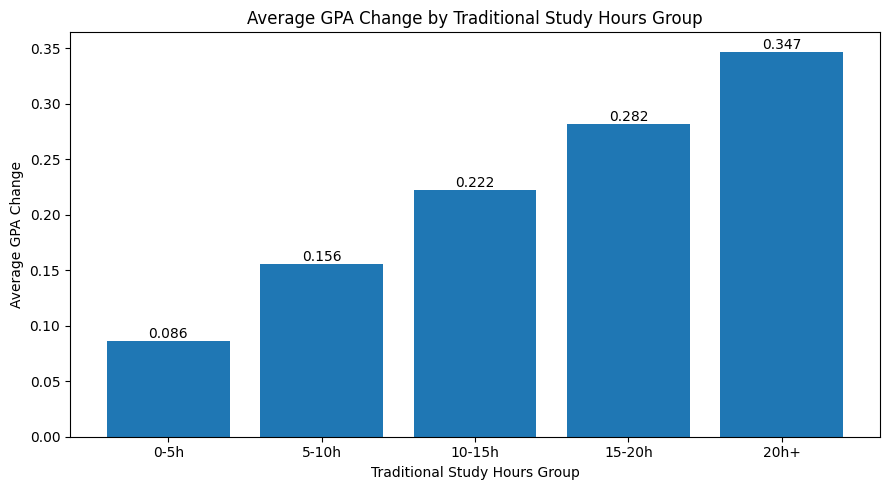

In [166]:
gpa_by_traditional_study = summary_by_traditional_study_display["avg_gpa_change"]

plt.figure(figsize=(9, 5))
plt.bar(
    gpa_by_traditional_study.index.astype(str),
    gpa_by_traditional_study.values
)

for index, value in enumerate(gpa_by_traditional_study.values):
    plt.text(
        index,
        value,
        f"{value:.3f}",
        ha="center",
        va="bottom"
    )

plt.title("Average GPA Change by Traditional Study Hours Group")
plt.xlabel("Traditional Study Hours Group")
plt.ylabel("Average GPA Change")
plt.tight_layout()

plt.savefig("../reports/figures/avg_gpa_change_by_traditional_study_group.png", dpi=300)
plt.show()

### Interpretation: GPA Change by Traditional Study Hours

This chart compares average GPA change across traditional study hour groups. If GPA improvement increases across higher traditional study groups, it suggests that traditional study effort remains important even in an AI-supported learning environment.

This helps avoid a simplistic interpretation that GenAI alone explains academic improvement.

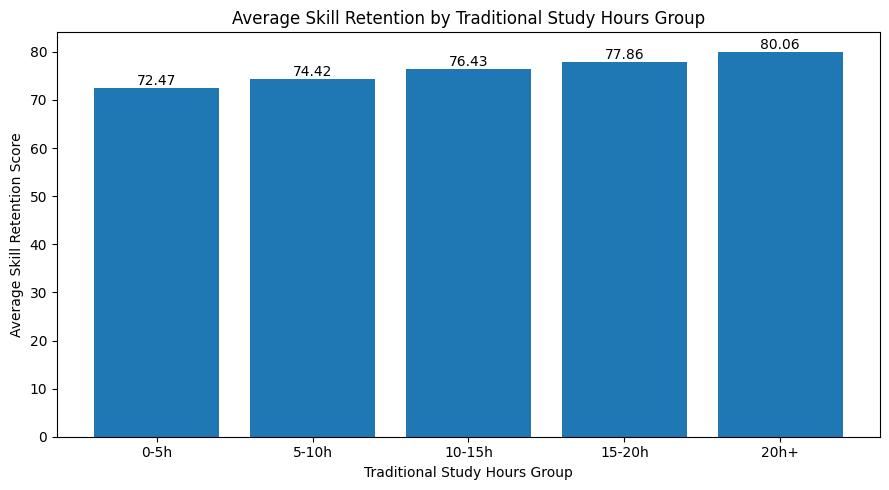

In [167]:
skill_by_traditional_study = summary_by_traditional_study_display["avg_skill_retention"]

plt.figure(figsize=(9, 5))
plt.bar(
    skill_by_traditional_study.index.astype(str),
    skill_by_traditional_study.values
)

for index, value in enumerate(skill_by_traditional_study.values):
    plt.text(
        index,
        value,
        f"{value:.2f}",
        ha="center",
        va="bottom"
    )

plt.title("Average Skill Retention by Traditional Study Hours Group")
plt.xlabel("Traditional Study Hours Group")
plt.ylabel("Average Skill Retention Score")
plt.tight_layout()

plt.savefig("../reports/figures/avg_skill_retention_by_traditional_study_group.png", dpi=300)
plt.show()

### Interpretation: Skill Retention by Traditional Study Hours

This chart shows whether students with more traditional study time also show stronger skill retention. Skill retention is important because it reflects learning quality beyond short-term GPA improvement.

If higher traditional study groups show stronger skill retention, this supports the idea that GenAI should complement rather than replace active study.

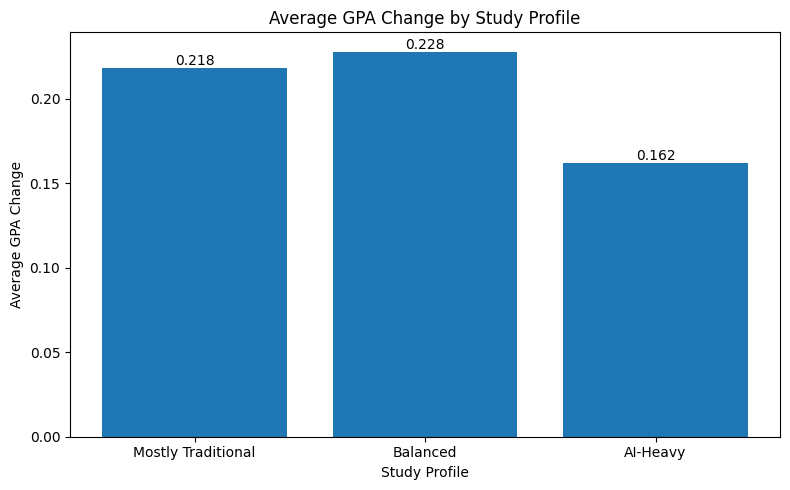

In [168]:
gpa_by_study_profile = summary_by_study_profile_display["avg_gpa_change"]

plt.figure(figsize=(8, 5))
plt.bar(
    gpa_by_study_profile.index.astype(str),
    gpa_by_study_profile.values
)

for index, value in enumerate(gpa_by_study_profile.values):
    plt.text(
        index,
        value,
        f"{value:.3f}",
        ha="center",
        va="bottom"
    )

plt.title("Average GPA Change by Study Profile")
plt.xlabel("Study Profile")
plt.ylabel("Average GPA Change")
plt.tight_layout()

plt.savefig("../reports/figures/avg_gpa_change_by_study_profile.png", dpi=300)
plt.show()

### Interpretation: GPA Change by Study Profile

This chart compares GPA improvement across mostly traditional, balanced, and AI-heavy study profiles.

If the Balanced group performs better than the AI-Heavy group, it supports the idea that GenAI may be most useful when integrated into a broader study routine rather than becoming the dominant study method.

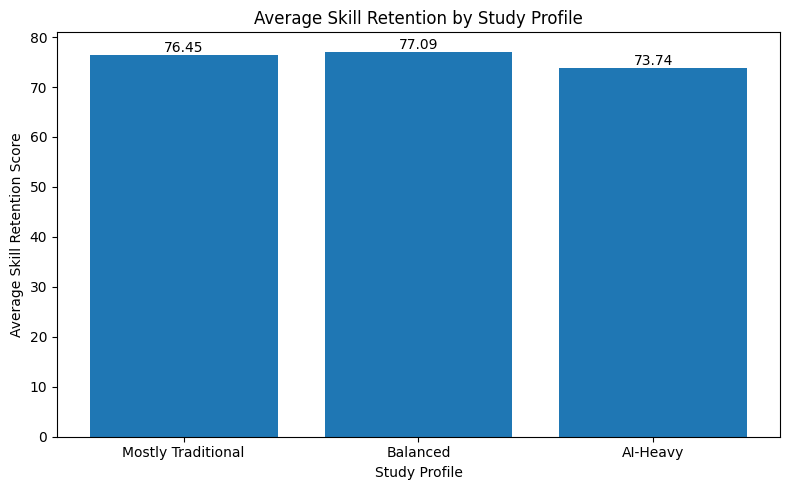

In [174]:
skill_by_study_profile = summary_by_study_profile_display["avg_skill_retention"]

plt.figure(figsize=(8, 5))
plt.bar(
    skill_by_study_profile.index.astype(str),
    skill_by_study_profile.values
)

for index, value in enumerate(skill_by_study_profile.values):
    plt.text(
        index,
        value,
        f"{value:.2f}",
        ha="center",
        va="bottom"
    )

plt.title("Average Skill Retention by Study Profile")
plt.xlabel("Study Profile")
plt.ylabel("Average Skill Retention Score")
plt.tight_layout()

plt.savefig("../reports/figures/avg_skill_retention_by_study_profile.png", dpi=300)
plt.show()

### Interpretation: Skill Retention by Study Profile

This chart shows whether learning retention differs across study profiles. A lower skill retention score among AI-heavy students would suggest that relying too heavily on GenAI may be associated with weaker durable learning.

This should be interpreted as an association, not proof that AI-heavy study directly causes lower retention.

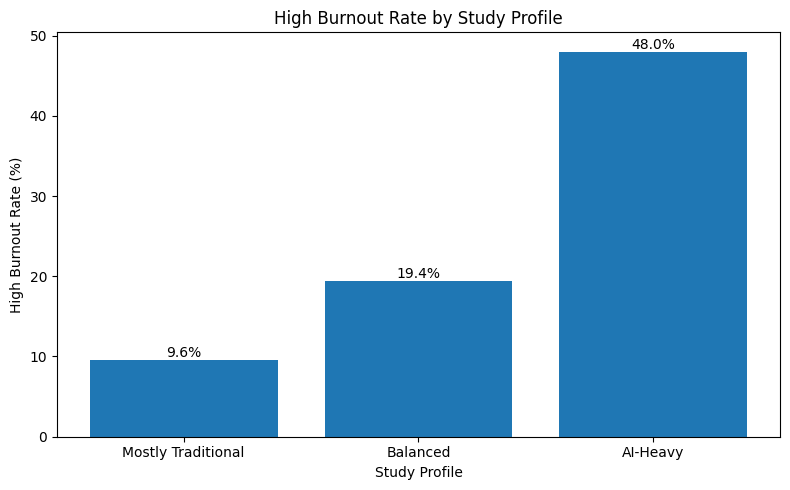

In [175]:
burnout_by_study_profile = summary_by_study_profile_display["high_burnout_rate_percent"]

plt.figure(figsize=(8, 5))
plt.bar(
    burnout_by_study_profile.index.astype(str),
    burnout_by_study_profile.values
)

for index, value in enumerate(burnout_by_study_profile.values):
    plt.text(
        index,
        value,
        f"{value:.1f}%",
        ha="center",
        va="bottom"
    )

plt.title("High Burnout Rate by Study Profile")
plt.xlabel("Study Profile")
plt.ylabel("High Burnout Rate (%)")
plt.tight_layout()

plt.savefig("../reports/figures/high_burnout_rate_by_study_profile.png", dpi=300)
plt.show()

### Interpretation: Burnout Risk by Study Profile

This chart compares high burnout risk across study profiles. If AI-heavy students show a higher burnout rate, this supports the broader pattern observed earlier: heavy reliance on GenAI is associated with higher well-being risk.

This does not prove causality. It may also reflect that stressed students rely more heavily on GenAI.

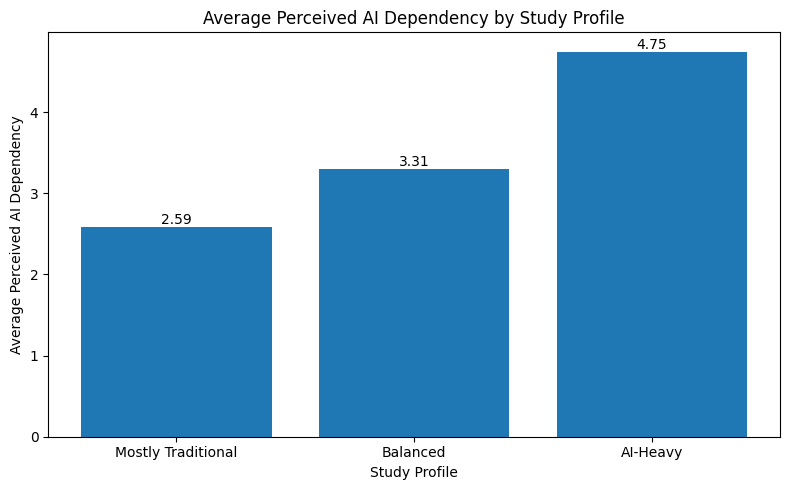

In [176]:
dependency_by_study_profile = summary_by_study_profile_display["avg_dependency"]

plt.figure(figsize=(8, 5))
plt.bar(
    dependency_by_study_profile.index.astype(str),
    dependency_by_study_profile.values
)

for index, value in enumerate(dependency_by_study_profile.values):
    plt.text(
        index,
        value,
        f"{value:.2f}",
        ha="center",
        va="bottom"
    )

plt.title("Average Perceived AI Dependency by Study Profile")
plt.xlabel("Study Profile")
plt.ylabel("Average Perceived AI Dependency")
plt.tight_layout()

plt.savefig("../reports/figures/avg_dependency_by_study_profile.png", dpi=300)
plt.show()

### Interpretation: AI Dependency by Study Profile

This chart shows whether AI-heavy study profiles are associated with higher perceived AI dependency. If AI-heavy students show clearly higher dependency, it suggests that study composition matters, not only raw AI usage hours.

This supports a responsible AI education approach focused on balanced use and self-regulation.

In [177]:
burnout_distribution_by_study_profile = pd.crosstab(
    df_analysis["Study_Profile"],
    df_analysis["Burnout_Risk_Level"],
    normalize="index"
) * 100

burnout_distribution_by_study_profile = burnout_distribution_by_study_profile[
    ["Low", "Medium", "High"]
]

burnout_distribution_by_study_profile.round(2)

Burnout_Risk_Level,Low,Medium,High
Study_Profile,,,
Mostly Traditional,48.38,42.03,9.59
Balanced,33.55,47.02,19.42
AI-Heavy,14.19,37.76,48.05


In [178]:
burnout_distribution_by_study_profile.round(2).to_csv(
    "../reports/tables/burnout_distribution_by_study_profile.csv"
)

In [179]:
gpa_category_by_study_profile = pd.crosstab(
    df_analysis["Study_Profile"],
    df_analysis["GPA_Change_Category"],
    normalize="index"
) * 100

gpa_category_by_study_profile = gpa_category_by_study_profile[
    ["Declined", "Stable", "Improved"]
]

gpa_category_by_study_profile.round(2)

GPA_Change_Category,Declined,Stable,Improved
Study_Profile,,,
Mostly Traditional,5.97,10.04,83.99
Balanced,5.55,9.78,84.67
AI-Heavy,12.89,12.89,74.23


In [180]:
gpa_category_by_study_profile.round(2).to_csv(
    "../reports/tables/gpa_change_category_by_study_profile.csv"
)

In [181]:
balanced_values = summary_by_study_profile_display.loc["Balanced"]
traditional_values = summary_by_study_profile_display.loc["Mostly Traditional"]
ai_heavy_values = summary_by_study_profile_display.loc["AI-Heavy"]

balanced_minus_traditional = balanced_values - traditional_values
balanced_minus_ai_heavy = balanced_values - ai_heavy_values

comparison_study_profile = pd.DataFrame({
    "Balanced_minus_Mostly_Traditional": balanced_minus_traditional,
    "Balanced_minus_AI_Heavy": balanced_minus_ai_heavy
})

comparison_study_profile.loc[
    [
        "avg_gpa_change",
        "avg_skill_retention",
        "avg_dependency",
        "avg_anxiety",
        "high_burnout_rate_percent"
    ]
]

,Balanced_minus_Mostly_Traditional,Balanced_minus_AI_Heavy
avg_gpa_change,0.010,0.066
avg_skill_retention,0.643,3.348
avg_dependency,0.717,-1.441
avg_anxiety,0.297,-0.761
high_burnout_rate_percent,9.800,-28.600


In [182]:
comparison_study_profile.to_csv(
    "../reports/tables/study_profile_group_differences.csv"
)

In [183]:
study_ratio_corr_columns = [
    "Weekly_GenAI_Hours",
    "Traditional_Study_Hours",
    "Total_Study_Hours",
    "AI_Study_Ratio",
    "GPA_Change",
    "Skill_Retention_Score",
    "Perceived_AI_Dependency",
    "Anxiety_Level_During_Exams"
]

study_ratio_correlations = df_analysis[study_ratio_corr_columns].corr().round(3)

study_ratio_correlations

,Weekly_GenAI_Hours,Traditional_Study_Hours,Total_Study_Hours,AI_Study_Ratio,GPA_Change,Skill_Retention_Score,Perceived_AI_Dependency,Anxiety_Level_During_Exams
Weekly_GenAI_Hours,1.000,-0.157,0.826,0.807,-0.046,-0.118,0.665,0.269
Traditional_Study_Hours,-0.157,1.000,0.427,-0.540,0.376,0.148,-0.103,-0.041
Total_Study_Hours,0.826,0.427,1.000,0.431,0.172,-0.024,0.551,0.223
AI_Study_Ratio,0.807,-0.540,0.431,1.000,-0.158,-0.110,0.530,0.215
GPA_Change,-0.046,0.376,0.172,-0.158,1.000,0.196,-0.039,-0.040
Skill_Retention_Score,-0.118,0.148,-0.024,-0.110,0.196,1.000,-0.084,-0.042
Perceived_AI_Dependency,0.665,-0.103,0.551,0.530,-0.039,-0.084,1.000,0.308
Anxiety_Level_During_Exams,0.269,-0.041,0.223,0.215,-0.040,-0.042,0.308,1.000


In [184]:
study_ratio_correlations.loc[
    ["AI_Study_Ratio", "Traditional_Study_Hours", "Weekly_GenAI_Hours"],
    [
        "GPA_Change",
        "Skill_Retention_Score",
        "Perceived_AI_Dependency",
        "Anxiety_Level_During_Exams"
    ]
]

,GPA_Change,Skill_Retention_Score,Perceived_AI_Dependency,Anxiety_Level_During_Exams
AI_Study_Ratio,-0.158,-0.110,0.530,0.215
Traditional_Study_Hours,0.376,0.148,-0.103,-0.041
Weekly_GenAI_Hours,-0.046,-0.118,0.665,0.269


In [185]:
study_ratio_correlations.to_csv(
    "../reports/tables/study_ratio_correlations.csv"
)

In [186]:
selected_study_ratio_correlations = study_ratio_correlations.loc[
    ["AI_Study_Ratio", "Traditional_Study_Hours", "Weekly_GenAI_Hours"],
    [
        "GPA_Change",
        "Skill_Retention_Score",
        "Perceived_AI_Dependency",
        "Anxiety_Level_During_Exams"
    ]
]

selected_study_ratio_correlations.to_csv(
    "../reports/tables/selected_study_ratio_correlations.csv"
)

selected_study_ratio_correlations

,GPA_Change,Skill_Retention_Score,Perceived_AI_Dependency,Anxiety_Level_During_Exams
AI_Study_Ratio,-0.158,-0.110,0.530,0.215
Traditional_Study_Hours,0.376,0.148,-0.103,-0.041
Weekly_GenAI_Hours,-0.046,-0.118,0.665,0.269


### Correlation Interpretation

The correlation table helps compare how AI usage, traditional study time, and AI study ratio relate to academic and well-being outcomes.

A positive correlation means that two variables tend to increase together. A negative correlation means that one variable tends to decrease as the other increases.

However, correlation does not prove causation. These relationships should be interpreted as descriptive associations.

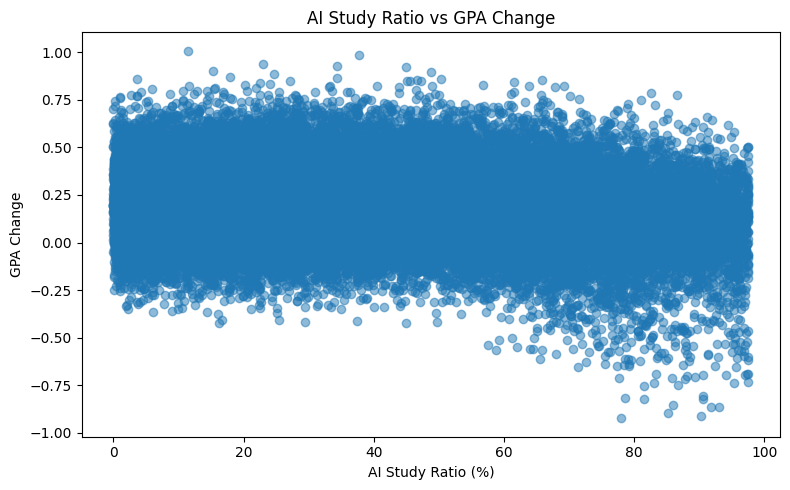

In [188]:
plt.figure(figsize=(8, 5))
plt.scatter(
    df_analysis["AI_Study_Ratio_Percent"],
    df_analysis["GPA_Change"],
    alpha=0.5
)

plt.title("AI Study Ratio vs GPA Change")
plt.xlabel("AI Study Ratio (%)")
plt.ylabel("GPA Change")
plt.tight_layout()

plt.savefig("../reports/figures/scatter_ai_study_ratio_vs_gpa_change.png", dpi=300)
plt.show()

### Interpretation: AI Study Ratio vs GPA Change

This scatter plot shows the relationship between the share of study time spent using GenAI and GPA change.

Because the dataset contains 50,000 students, the plot is dense. It should be used to observe broad tendencies rather than individual cases. The correlation table provides a clearer numerical summary of the relationship.

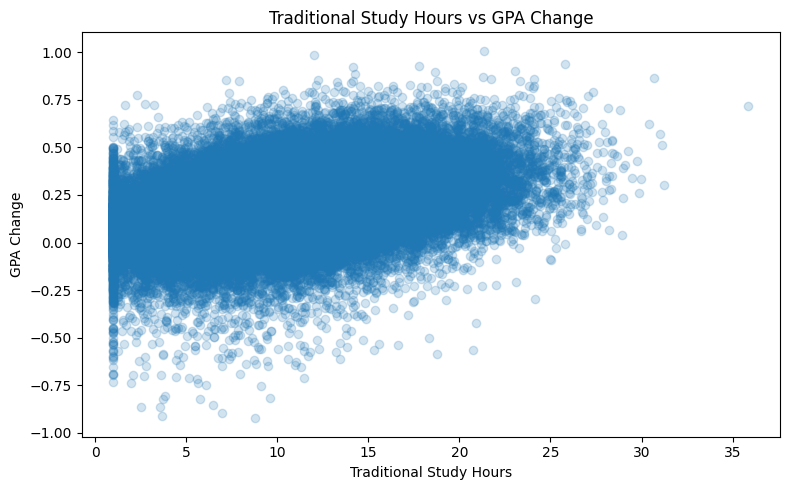

In [190]:
plt.figure(figsize=(8, 5))
plt.scatter(
    df_analysis["Traditional_Study_Hours"],
    df_analysis["GPA_Change"],
    alpha=0.2
)

plt.title("Traditional Study Hours vs GPA Change")
plt.xlabel("Traditional Study Hours")
plt.ylabel("GPA Change")
plt.tight_layout()

plt.savefig("../reports/figures/scatter_traditional_study_hours_vs_gpa_change.png", dpi=300)
plt.show()

### Interpretation: Traditional Study Hours vs GPA Change

This scatter plot compares traditional study hours with GPA change. It helps evaluate whether non-AI study effort remains associated with academic improvement.

The plot should be interpreted together with the grouped summary and correlation table.

### Key Insight: Balance Matters

This section suggests that study composition matters. Looking only at weekly GenAI hours is not enough; it is also important to consider how much of a student's total study time depends on AI.

The Study_Profile analysis helps distinguish between mostly traditional, balanced, and AI-heavy learners. If the balanced group shows stronger academic outcomes or lower risk than the AI-heavy group, this supports the idea that GenAI may be most useful when used as a complement to active study rather than as a replacement for it.

Traditional study time should therefore remain part of the interpretation. Responsible GenAI use is not simply about using more AI, but about integrating AI into a healthy and effective learning routine.

In [192]:
os.listdir("../reports/figures")

['avg_ai_study_ratio_by_ai_hours_group.png',
 'avg_dependency_by_ai_hours_group.png',
 'avg_dependency_by_primary_use_case.png',
 'avg_dependency_by_prompt_skill.png',
 'avg_dependency_by_study_profile.png',
 'avg_exam_anxiety_by_ai_hours_group.png',
 'avg_gpa_change_by_ai_hours_group.png',
 'avg_gpa_change_by_primary_use_case.png',
 'avg_gpa_change_by_prompt_skill.png',
 'avg_gpa_change_by_study_profile.png',
 'avg_gpa_change_by_traditional_study_group.png',
 'avg_skill_retention_by_ai_hours_group.png',
 'avg_skill_retention_by_primary_use_case.png',
 'avg_skill_retention_by_prompt_skill.png',
 'avg_skill_retention_by_study_profile.png',
 'avg_skill_retention_by_traditional_study_group.png',
 'avg_total_study_hours_by_ai_hours_group.png',
 'high_burnout_rate_by_ai_hours_group.png',
 'high_burnout_rate_by_primary_use_case.png',
 'high_burnout_rate_by_prompt_skill.png',
 'high_burnout_rate_by_study_profile.png',
 'scatter_ai_study_ratio_vs_gpa_change.png',
 'scatter_traditional_study_ho

In [193]:
os.listdir("../reports/tables")

['advanced_vs_beginner_prompt_skill_difference.csv',
 'burnout_distribution_by_ai_group.csv',
 'burnout_distribution_by_primary_use_case.csv',
 'burnout_distribution_by_prompt_skill.csv',
 'burnout_distribution_by_study_profile.csv',
 'categorical_summary.csv',
 'data_dictionary.csv',
 'debugging_vs_direct_answer_difference.csv',
 'feature_engineering_summary.csv',
 'gpa_change_category_by_ai_group.csv',
 'gpa_change_category_by_primary_use_case.csv',
 'gpa_change_category_by_prompt_skill.csv',
 'gpa_change_category_by_study_profile.csv',
 'selected_study_ratio_correlations.csv',
 'study_profile_group_differences.csv',
 'study_ratio_correlations.csv',
 'summary_by_ai_hours_group.csv',
 'summary_by_primary_use_case.csv',
 'summary_by_prompt_engineering_skill.csv',
 'summary_by_study_profile.csv',
 'summary_by_traditional_study_group.csv']

## 9. Contextual Segment Analysis

In this section, we analyze student outcomes by institutional AI policy, major category, year of study, and paid subscription status.

In [194]:
df_analysis.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level,GPA_Change,GPA_Change_Category,Total_Study_Hours,AI_Study_Ratio,AI_Study_Ratio_Percent,AI_Hours_Group,AI_Usage_Intensity,Traditional_Study_Group,Study_Profile
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High,-0.025,Stable,31.44,0.741412,74.141221,15h+,Very High,5-10h,AI-Heavy
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low,-0.125,Declined,17.77,0.063028,6.302757,0-2h,Very Low,15-20h,Mostly Traditional
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium,0.101,Improved,31.61,0.672572,67.257197,15h+,Very High,10-15h,AI-Heavy
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium,0.211,Improved,17.05,0.106745,10.674487,0-2h,Very Low,15-20h,Mostly Traditional
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium,0.163,Improved,21.84,0.425366,42.536630,5-10h,Moderate,10-15h,Balanced


In [195]:
context_columns = [
    "Institutional_Policy",
    "Major_Category",
    "Year_of_Study",
    "Paid_Subscription",
    "Weekly_GenAI_Hours",
    "Traditional_Study_Hours",
    "GPA_Change",
    "Skill_Retention_Score",
    "Perceived_AI_Dependency",
    "Anxiety_Level_During_Exams",
    "Burnout_Risk_Level"
]

df_analysis[context_columns].head(10)

,Institutional_Policy,Major_Category,Year_of_Study,Paid_Subscription,Weekly_GenAI_Hours,Traditional_Study_Hours,GPA_Change,Skill_Retention_Score,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Burnout_Risk_Level
0,Allowed_With_Citation,Humanities,Senior,True,23.31,8.13,-0.025,86.44,5,6,High
1,Allowed_With_Citation,Medical,Junior,False,1.12,16.65,-0.125,69.39,3,9,Low
2,Strict_Ban,Business,Freshman,False,21.26,10.35,0.101,73.93,5,9,Medium
3,Allowed_With_Citation,Business,Senior,False,1.82,15.23,0.211,63.58,2,2,Medium
4,Allowed_With_Citation,STEM,Sophomore,False,9.29,12.55,0.163,100.00,4,4,Medium
5,Allowed_With_Citation,STEM,Junior,False,6.50,14.19,0.217,65.92,4,5,High
6,Allowed_With_Citation,STEM,Freshman,True,31.41,13.11,0.378,67.97,8,7,Medium
7,Actively_Encouraged,Arts,Junior,False,5.33,18.45,0.219,85.09,2,1,Medium
8,Strict_Ban,Business,Sophomore,True,2.00,2.87,-0.024,55.71,1,5,Medium
9,Strict_Ban,Business,Sophomore,True,19.99,12.49,-0.068,87.18,3,8,High


In [196]:
df_analysis["Institutional_Policy"].value_counts()

Institutional_Policy
Allowed_With_Citation    25224
Actively_Encouraged      14988
Strict_Ban                9788
Name: count, dtype: int64

In [197]:
(df_analysis["Institutional_Policy"].value_counts(normalize=True) * 100).round(2)

Institutional_Policy
Allowed_With_Citation    50.45
Actively_Encouraged      29.98
Strict_Ban               19.58
Name: proportion, dtype: float64

In [198]:
summary_by_policy = df_analysis.groupby("Institutional_Policy").agg(
    students=("Student_ID", "count"),
    avg_ai_hours=("Weekly_GenAI_Hours", "mean"),
    avg_traditional_hours=("Traditional_Study_Hours", "mean"),
    avg_total_study_hours=("Total_Study_Hours", "mean"),
    avg_ai_study_ratio=("AI_Study_Ratio", "mean"),
    avg_gpa_change=("GPA_Change", "mean"),
    avg_skill_retention=("Skill_Retention_Score", "mean"),
    avg_dependency=("Perceived_AI_Dependency", "mean"),
    avg_anxiety=("Anxiety_Level_During_Exams", "mean"),
    high_burnout_rate=("Burnout_Risk_Level", lambda x: (x == "High").mean())
).round(3)

summary_by_policy

,students,avg_ai_hours,avg_traditional_hours,avg_total_study_hours,avg_ai_study_ratio,avg_gpa_change,avg_skill_retention,avg_dependency,avg_anxiety,high_burnout_rate
Institutional_Policy,,,,,,,,,,
Actively_Encouraged,14988,8.478,11.241,19.719,0.381,0.206,76.131,3.519,4.119,0.238
Allowed_With_Citation,25224,8.420,11.175,19.595,0.380,0.208,75.912,3.505,4.122,0.238
Strict_Ban,9788,8.370,11.250,19.619,0.379,0.187,74.994,3.484,4.886,0.298


In [199]:
summary_by_policy_display = summary_by_policy.copy()

summary_by_policy_display["avg_ai_study_ratio_percent"] = (
    summary_by_policy_display["avg_ai_study_ratio"] * 100
).round(1)

summary_by_policy_display["high_burnout_rate_percent"] = (
    summary_by_policy_display["high_burnout_rate"] * 100
).round(1)

summary_by_policy_display = summary_by_policy_display[
    [
        "students",
        "avg_ai_hours",
        "avg_traditional_hours",
        "avg_total_study_hours",
        "avg_ai_study_ratio_percent",
        "avg_gpa_change",
        "avg_skill_retention",
        "avg_dependency",
        "avg_anxiety",
        "high_burnout_rate_percent"
    ]
]

summary_by_policy_display

,students,avg_ai_hours,avg_traditional_hours,avg_total_study_hours,avg_ai_study_ratio_percent,avg_gpa_change,avg_skill_retention,avg_dependency,avg_anxiety,high_burnout_rate_percent
Institutional_Policy,,,,,,,,,,
Actively_Encouraged,14988,8.478,11.241,19.719,38.1,0.206,76.131,3.519,4.119,23.8
Allowed_With_Citation,25224,8.420,11.175,19.595,38.0,0.208,75.912,3.505,4.122,23.8
Strict_Ban,9788,8.370,11.250,19.619,37.9,0.187,74.994,3.484,4.886,29.8


In [200]:
summary_by_policy_display.to_csv(
    "../reports/tables/summary_by_institutional_policy.csv"
)

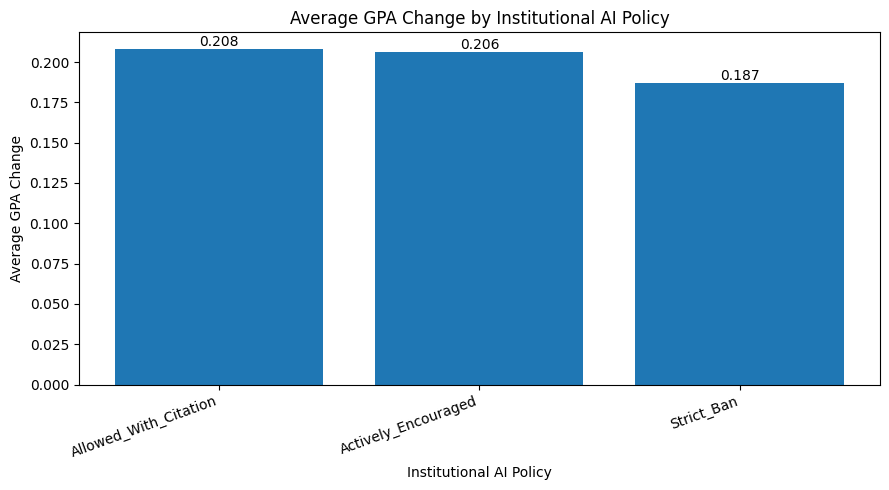

In [201]:
policy_gpa = summary_by_policy_display["avg_gpa_change"].sort_values(ascending=False)

plt.figure(figsize=(9, 5))
plt.bar(policy_gpa.index.astype(str), policy_gpa.values)

for index, value in enumerate(policy_gpa.values):
    plt.text(
        index,
        value,
        f"{value:.3f}",
        ha="center",
        va="bottom"
    )

plt.title("Average GPA Change by Institutional AI Policy")
plt.xlabel("Institutional AI Policy")
plt.ylabel("Average GPA Change")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()

plt.savefig("../reports/figures/avg_gpa_change_by_institutional_policy.png", dpi=300)
plt.show()

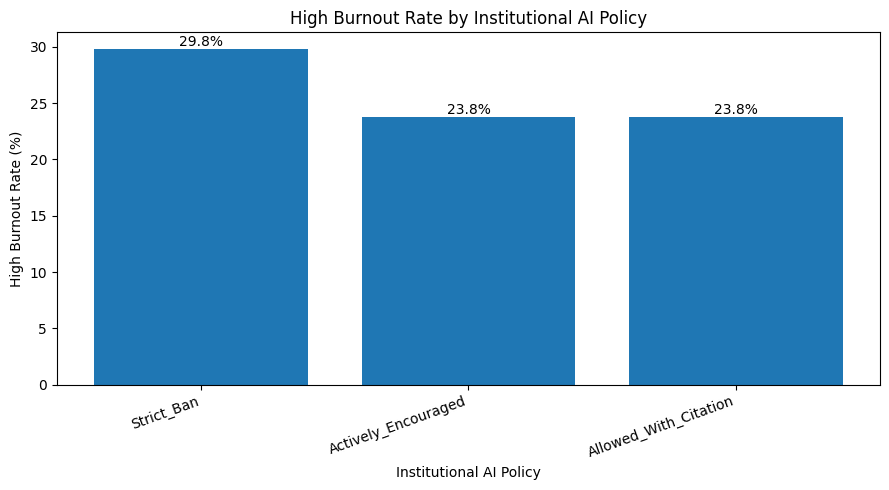

In [202]:
policy_burnout = summary_by_policy_display["high_burnout_rate_percent"].sort_values(ascending=False)

plt.figure(figsize=(9, 5))
plt.bar(policy_burnout.index.astype(str), policy_burnout.values)

for index, value in enumerate(policy_burnout.values):
    plt.text(
        index,
        value,
        f"{value:.1f}%",
        ha="center",
        va="bottom"
    )

plt.title("High Burnout Rate by Institutional AI Policy")
plt.xlabel("Institutional AI Policy")
plt.ylabel("High Burnout Rate (%)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()

plt.savefig("../reports/figures/high_burnout_rate_by_institutional_policy.png", dpi=300)
plt.show()

### Interpretation: Institutional AI Policy

Students under Strict_Ban policies show lower average GPA improvement, lower average skill retention, higher exam anxiety, and a higher high-burnout rate compared to the other institutional policy groups.

Allowed_With_Citation and Actively_Encouraged policies show similar academic and well-being patterns.

This does not prove that strict bans cause worse outcomes. Institutional policy may be related to other factors such as university culture, academic pressure, enforcement practices, or student population differences. However, the pattern suggests that policy context is relevant when discussing responsible GenAI use in education.

In [203]:
df_analysis["Major_Category"].value_counts()

Major_Category
STEM          15059
Business      12538
Humanities     9994
Medical        6476
Arts           5933
Name: count, dtype: int64

In [204]:
(df_analysis["Major_Category"].value_counts(normalize=True) * 100).round(2)

Major_Category
STEM          30.12
Business      25.08
Humanities    19.99
Medical       12.95
Arts          11.87
Name: proportion, dtype: float64

In [205]:
summary_by_major = df_analysis.groupby("Major_Category").agg(
    students=("Student_ID", "count"),
    avg_ai_hours=("Weekly_GenAI_Hours", "mean"),
    avg_traditional_hours=("Traditional_Study_Hours", "mean"),
    avg_total_study_hours=("Total_Study_Hours", "mean"),
    avg_ai_study_ratio=("AI_Study_Ratio", "mean"),
    avg_gpa_change=("GPA_Change", "mean"),
    avg_skill_retention=("Skill_Retention_Score", "mean"),
    avg_dependency=("Perceived_AI_Dependency", "mean"),
    avg_anxiety=("Anxiety_Level_During_Exams", "mean"),
    high_burnout_rate=("Burnout_Risk_Level", lambda x: (x == "High").mean())
).round(3)

summary_by_major_sorted = summary_by_major.sort_values(
    "avg_gpa_change",
    ascending=False
)

summary_by_major_sorted

,students,avg_ai_hours,avg_traditional_hours,avg_total_study_hours,avg_ai_study_ratio,avg_gpa_change,avg_skill_retention,avg_dependency,avg_anxiety,high_burnout_rate
Major_Category,,,,,,,,,,
STEM,15059,10.489,11.005,21.493,0.428,0.217,76.800,3.794,4.429,0.300
Medical,6476,7.547,11.365,18.912,0.359,0.201,75.485,3.400,4.228,0.232
Humanities,9994,6.770,11.337,18.107,0.340,0.198,75.254,3.244,4.142,0.207
Arts,5933,7.272,11.352,18.624,0.353,0.197,75.661,3.363,4.174,0.227
Business,12538,8.276,11.205,19.481,0.379,0.194,75.256,3.489,4.251,0.243


In [206]:
summary_by_major_display = summary_by_major_sorted.copy()

summary_by_major_display["avg_ai_study_ratio_percent"] = (
    summary_by_major_display["avg_ai_study_ratio"] * 100
).round(1)

summary_by_major_display["high_burnout_rate_percent"] = (
    summary_by_major_display["high_burnout_rate"] * 100
).round(1)

summary_by_major_display = summary_by_major_display[
    [
        "students",
        "avg_ai_hours",
        "avg_traditional_hours",
        "avg_total_study_hours",
        "avg_ai_study_ratio_percent",
        "avg_gpa_change",
        "avg_skill_retention",
        "avg_dependency",
        "avg_anxiety",
        "high_burnout_rate_percent"
    ]
]

summary_by_major_display

,students,avg_ai_hours,avg_traditional_hours,avg_total_study_hours,avg_ai_study_ratio_percent,avg_gpa_change,avg_skill_retention,avg_dependency,avg_anxiety,high_burnout_rate_percent
Major_Category,,,,,,,,,,
STEM,15059,10.489,11.005,21.493,42.8,0.217,76.800,3.794,4.429,30.0
Medical,6476,7.547,11.365,18.912,35.9,0.201,75.485,3.400,4.228,23.2
Humanities,9994,6.770,11.337,18.107,34.0,0.198,75.254,3.244,4.142,20.7
Arts,5933,7.272,11.352,18.624,35.3,0.197,75.661,3.363,4.174,22.7
Business,12538,8.276,11.205,19.481,37.9,0.194,75.256,3.489,4.251,24.3


In [207]:
summary_by_major_display.to_csv(
    "../reports/tables/summary_by_major_category.csv"
)

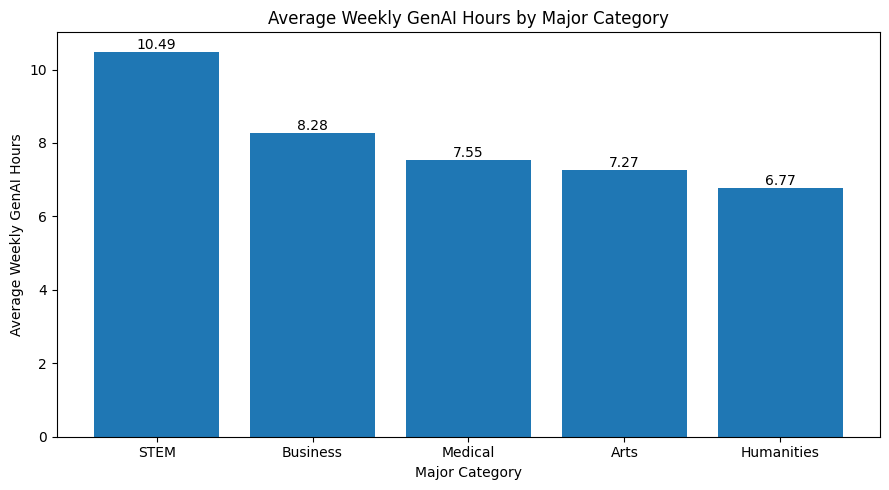

In [208]:
major_ai_hours = summary_by_major.sort_values("avg_ai_hours", ascending=False)["avg_ai_hours"]

plt.figure(figsize=(9, 5))
plt.bar(major_ai_hours.index.astype(str), major_ai_hours.values)

for index, value in enumerate(major_ai_hours.values):
    plt.text(
        index,
        value,
        f"{value:.2f}",
        ha="center",
        va="bottom"
    )

plt.title("Average Weekly GenAI Hours by Major Category")
plt.xlabel("Major Category")
plt.ylabel("Average Weekly GenAI Hours")
plt.tight_layout()

plt.savefig("../reports/figures/avg_ai_hours_by_major_category.png", dpi=300)
plt.show()

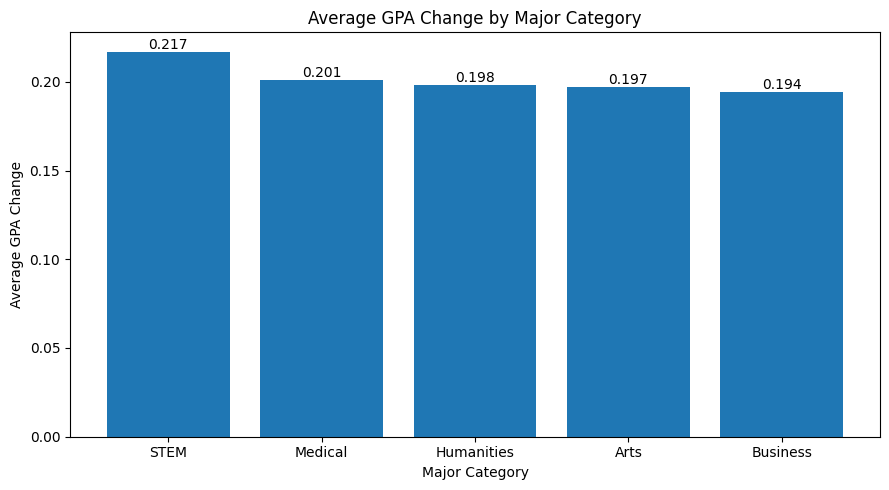

In [209]:
major_gpa = summary_by_major.sort_values("avg_gpa_change", ascending=False)["avg_gpa_change"]

plt.figure(figsize=(9, 5))
plt.bar(major_gpa.index.astype(str), major_gpa.values)

for index, value in enumerate(major_gpa.values):
    plt.text(
        index,
        value,
        f"{value:.3f}",
        ha="center",
        va="bottom"
    )

plt.title("Average GPA Change by Major Category")
plt.xlabel("Major Category")
plt.ylabel("Average GPA Change")
plt.tight_layout()

plt.savefig("../reports/figures/avg_gpa_change_by_major_category.png", dpi=300)
plt.show()

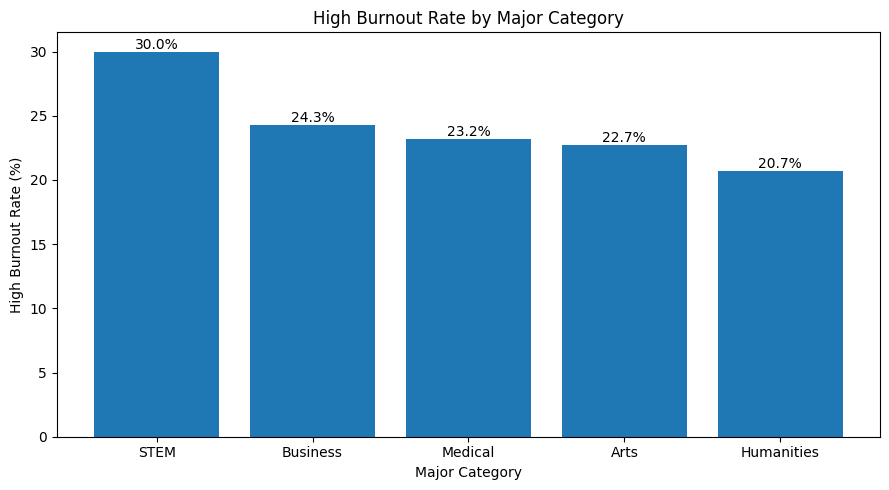

In [210]:
major_burnout = summary_by_major_display["high_burnout_rate_percent"].sort_values(ascending=False)

plt.figure(figsize=(9, 5))
plt.bar(major_burnout.index.astype(str), major_burnout.values)

for index, value in enumerate(major_burnout.values):
    plt.text(
        index,
        value,
        f"{value:.1f}%",
        ha="center",
        va="bottom"
    )

plt.title("High Burnout Rate by Major Category")
plt.xlabel("Major Category")
plt.ylabel("High Burnout Rate (%)")
plt.tight_layout()

plt.savefig("../reports/figures/high_burnout_rate_by_major_category.png", dpi=300)
plt.show()

### Interpretation: Major Category

STEM students show the highest average weekly GenAI usage and the highest average GPA improvement in this dataset. They also show the highest average skill retention score.

However, STEM students also have the highest high-burnout rate and higher perceived AI dependency and exam anxiety than most other major categories.

This suggests that STEM students may represent a high-benefit but also high-risk GenAI user segment. Their stronger academic outcome pattern should be interpreted together with their higher well-being risk indicators.

In [211]:
df_analysis["Year_of_Study"].value_counts()

Year_of_Study
Junior       11045
Freshman     11031
Senior       10634
Sophomore     9860
Graduate      7430
Name: count, dtype: int64

In [212]:
(df_analysis["Year_of_Study"].value_counts(normalize=True) * 100).round(2)

Year_of_Study
Junior       22.09
Freshman     22.06
Senior       21.27
Sophomore    19.72
Graduate     14.86
Name: proportion, dtype: float64

In [213]:
year_order = ["Freshman", "Sophomore", "Junior", "Senior", "Graduate"]

df_analysis["Year_of_Study"] = pd.Categorical(
    df_analysis["Year_of_Study"],
    categories=year_order,
    ordered=True
)

In [214]:
df_analysis["Year_of_Study"].value_counts().sort_index()

Year_of_Study
Freshman     11031
Sophomore     9860
Junior       11045
Senior       10634
Graduate      7430
Name: count, dtype: int64

In [215]:
summary_by_year = df_analysis.groupby(
    "Year_of_Study",
    observed=False
).agg(
    students=("Student_ID", "count"),
    avg_ai_hours=("Weekly_GenAI_Hours", "mean"),
    avg_traditional_hours=("Traditional_Study_Hours", "mean"),
    avg_total_study_hours=("Total_Study_Hours", "mean"),
    avg_ai_study_ratio=("AI_Study_Ratio", "mean"),
    avg_gpa_change=("GPA_Change", "mean"),
    avg_skill_retention=("Skill_Retention_Score", "mean"),
    avg_dependency=("Perceived_AI_Dependency", "mean"),
    avg_anxiety=("Anxiety_Level_During_Exams", "mean"),
    high_burnout_rate=("Burnout_Risk_Level", lambda x: (x == "High").mean())
).round(3)

summary_by_year

,students,avg_ai_hours,avg_traditional_hours,avg_total_study_hours,avg_ai_study_ratio,avg_gpa_change,avg_skill_retention,avg_dependency,avg_anxiety,high_burnout_rate
Year_of_Study,,,,,,,,,,
Freshman,11031,8.447,11.197,19.644,0.382,0.132,74.658,3.495,4.280,0.180
Sophomore,9860,8.446,11.187,19.633,0.381,0.177,74.812,3.537,4.298,0.220
Junior,11045,8.376,11.246,19.622,0.377,0.226,74.770,3.504,4.263,0.243
Senior,10634,8.459,11.210,19.669,0.381,0.243,77.768,3.492,4.272,0.274
Graduate,7430,8.406,11.202,19.608,0.380,0.252,77.508,3.501,4.231,0.367


In [216]:
summary_by_year_display = summary_by_year.copy()

summary_by_year_display["avg_ai_study_ratio_percent"] = (
    summary_by_year_display["avg_ai_study_ratio"] * 100
).round(1)

summary_by_year_display["high_burnout_rate_percent"] = (
    summary_by_year_display["high_burnout_rate"] * 100
).round(1)

summary_by_year_display = summary_by_year_display[
    [
        "students",
        "avg_ai_hours",
        "avg_traditional_hours",
        "avg_total_study_hours",
        "avg_ai_study_ratio_percent",
        "avg_gpa_change",
        "avg_skill_retention",
        "avg_dependency",
        "avg_anxiety",
        "high_burnout_rate_percent"
    ]
]

summary_by_year_display

,students,avg_ai_hours,avg_traditional_hours,avg_total_study_hours,avg_ai_study_ratio_percent,avg_gpa_change,avg_skill_retention,avg_dependency,avg_anxiety,high_burnout_rate_percent
Year_of_Study,,,,,,,,,,
Freshman,11031,8.447,11.197,19.644,38.2,0.132,74.658,3.495,4.280,18.0
Sophomore,9860,8.446,11.187,19.633,38.1,0.177,74.812,3.537,4.298,22.0
Junior,11045,8.376,11.246,19.622,37.7,0.226,74.770,3.504,4.263,24.3
Senior,10634,8.459,11.210,19.669,38.1,0.243,77.768,3.492,4.272,27.4
Graduate,7430,8.406,11.202,19.608,38.0,0.252,77.508,3.501,4.231,36.7


In [217]:
summary_by_year_display.to_csv(
    "../reports/tables/summary_by_year_of_study.csv"
)

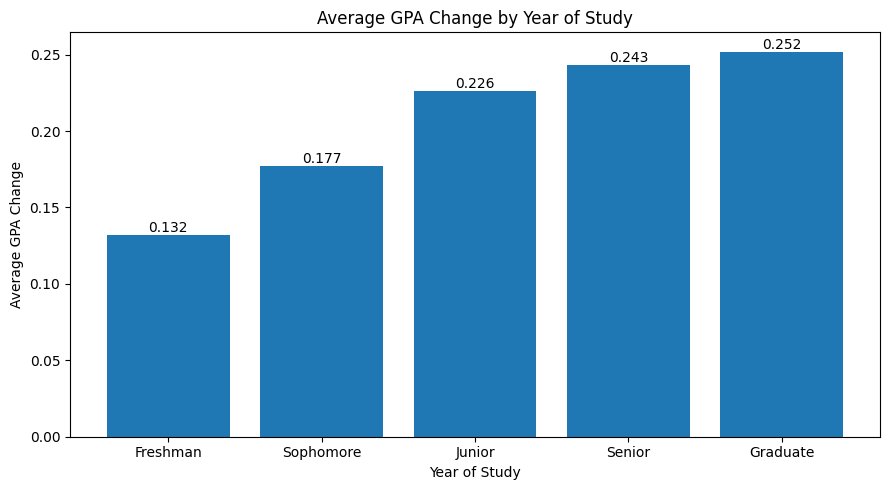

In [218]:
year_gpa = summary_by_year_display["avg_gpa_change"]

plt.figure(figsize=(9, 5))
plt.bar(year_gpa.index.astype(str), year_gpa.values)

for index, value in enumerate(year_gpa.values):
    plt.text(
        index,
        value,
        f"{value:.3f}",
        ha="center",
        va="bottom"
    )

plt.title("Average GPA Change by Year of Study")
plt.xlabel("Year of Study")
plt.ylabel("Average GPA Change")
plt.tight_layout()

plt.savefig("../reports/figures/avg_gpa_change_by_year_of_study.png", dpi=300)
plt.show()

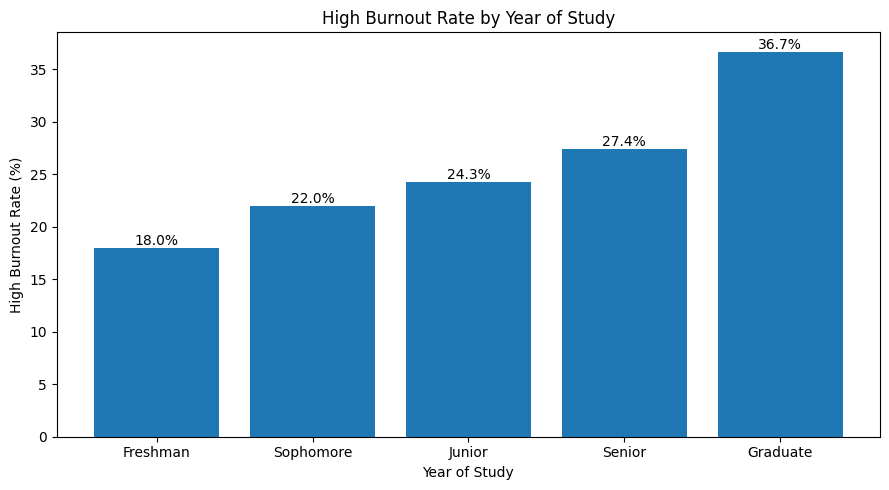

In [219]:
year_burnout = summary_by_year_display["high_burnout_rate_percent"]

plt.figure(figsize=(9, 5))
plt.bar(year_burnout.index.astype(str), year_burnout.values)

for index, value in enumerate(year_burnout.values):
    plt.text(
        index,
        value,
        f"{value:.1f}%",
        ha="center",
        va="bottom"
    )

plt.title("High Burnout Rate by Year of Study")
plt.xlabel("Year of Study")
plt.ylabel("High Burnout Rate (%)")
plt.tight_layout()

plt.savefig("../reports/figures/high_burnout_rate_by_year_of_study.png", dpi=300)
plt.show()

### Interpretation: Year of Study

Academic outcomes differ across year-of-study groups. Senior and Graduate students show higher average GPA improvement and higher skill retention than earlier-year students.

However, burnout risk also increases across later study years, with Graduate students showing the highest high-burnout rate.

This suggests that advanced students may be more academically effective, but also more exposed to workload or pressure-related risks.

In [220]:
df_analysis["Paid_Subscription"].value_counts()

Paid_Subscription
False    28846
True     21154
Name: count, dtype: int64

In [221]:
(df_analysis["Paid_Subscription"].value_counts(normalize=True) * 100).round(2)

Paid_Subscription
False    57.69
True     42.31
Name: proportion, dtype: float64

In [222]:
summary_by_subscription = df_analysis.groupby("Paid_Subscription").agg(
    students=("Student_ID", "count"),
    avg_ai_hours=("Weekly_GenAI_Hours", "mean"),
    avg_traditional_hours=("Traditional_Study_Hours", "mean"),
    avg_total_study_hours=("Total_Study_Hours", "mean"),
    avg_ai_study_ratio=("AI_Study_Ratio", "mean"),
    avg_gpa_change=("GPA_Change", "mean"),
    avg_skill_retention=("Skill_Retention_Score", "mean"),
    avg_dependency=("Perceived_AI_Dependency", "mean"),
    avg_anxiety=("Anxiety_Level_During_Exams", "mean"),
    high_burnout_rate=("Burnout_Risk_Level", lambda x: (x == "High").mean())
).round(3)

summary_by_subscription

,students,avg_ai_hours,avg_traditional_hours,avg_total_study_hours,avg_ai_study_ratio,avg_gpa_change,avg_skill_retention,avg_dependency,avg_anxiety,high_burnout_rate
Paid_Subscription,,,,,,,,,,
False,28846,7.033,11.365,18.398,0.346,0.200,76.072,3.301,4.150,0.211
True,21154,10.330,10.997,21.326,0.427,0.207,75.425,3.784,4.436,0.302


In [223]:
summary_by_subscription_display = summary_by_subscription.copy()

summary_by_subscription_display["avg_ai_study_ratio_percent"] = (
    summary_by_subscription_display["avg_ai_study_ratio"] * 100
).round(1)

summary_by_subscription_display["high_burnout_rate_percent"] = (
    summary_by_subscription_display["high_burnout_rate"] * 100
).round(1)

summary_by_subscription_display = summary_by_subscription_display[
    [
        "students",
        "avg_ai_hours",
        "avg_traditional_hours",
        "avg_total_study_hours",
        "avg_ai_study_ratio_percent",
        "avg_gpa_change",
        "avg_skill_retention",
        "avg_dependency",
        "avg_anxiety",
        "high_burnout_rate_percent"
    ]
]

summary_by_subscription_display

,students,avg_ai_hours,avg_traditional_hours,avg_total_study_hours,avg_ai_study_ratio_percent,avg_gpa_change,avg_skill_retention,avg_dependency,avg_anxiety,high_burnout_rate_percent
Paid_Subscription,,,,,,,,,,
False,28846,7.033,11.365,18.398,34.6,0.200,76.072,3.301,4.150,21.1
True,21154,10.330,10.997,21.326,42.7,0.207,75.425,3.784,4.436,30.2


In [224]:
summary_by_subscription_display.to_csv(
    "../reports/tables/summary_by_paid_subscription.csv"
)

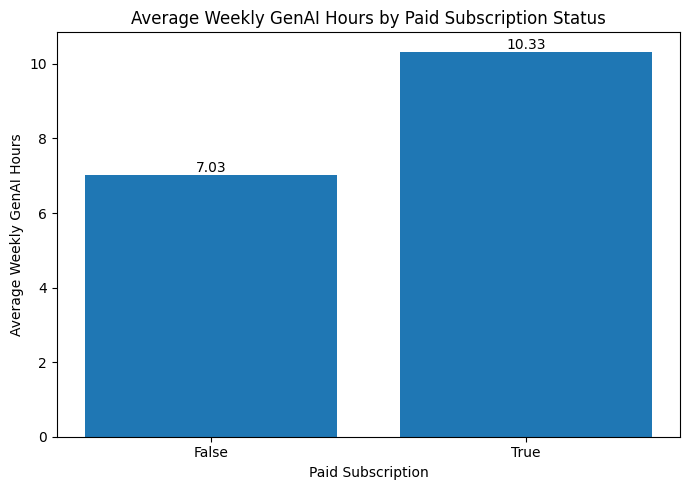

In [225]:
subscription_ai_hours = summary_by_subscription_display["avg_ai_hours"]

plt.figure(figsize=(7, 5))
plt.bar(subscription_ai_hours.index.astype(str), subscription_ai_hours.values)

for index, value in enumerate(subscription_ai_hours.values):
    plt.text(
        index,
        value,
        f"{value:.2f}",
        ha="center",
        va="bottom"
    )

plt.title("Average Weekly GenAI Hours by Paid Subscription Status")
plt.xlabel("Paid Subscription")
plt.ylabel("Average Weekly GenAI Hours")
plt.tight_layout()

plt.savefig("../reports/figures/avg_ai_hours_by_paid_subscription.png", dpi=300)
plt.show()

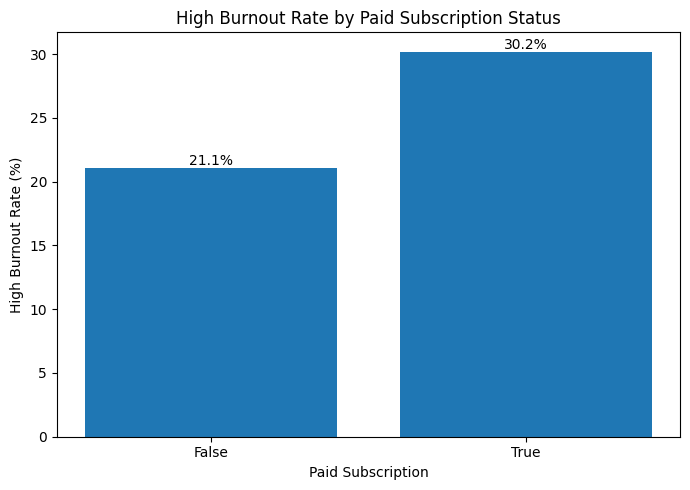

In [226]:
subscription_burnout = summary_by_subscription_display["high_burnout_rate_percent"]

plt.figure(figsize=(7, 5))
plt.bar(subscription_burnout.index.astype(str), subscription_burnout.values)

for index, value in enumerate(subscription_burnout.values):
    plt.text(
        index,
        value,
        f"{value:.1f}%",
        ha="center",
        va="bottom"
    )

plt.title("High Burnout Rate by Paid Subscription Status")
plt.xlabel("Paid Subscription")
plt.ylabel("High Burnout Rate (%)")
plt.tight_layout()

plt.savefig("../reports/figures/high_burnout_rate_by_paid_subscription.png", dpi=300)
plt.show()

### Interpretation: Paid Subscription

Students with paid GenAI subscriptions use GenAI more heavily on average and have a higher AI study ratio.

However, paid subscription status is not associated with a large academic advantage in this dataset. GPA improvement is only slightly higher among paid users, while skill retention is slightly lower.

Paid users also show higher perceived AI dependency, higher exam anxiety, and a higher high-burnout rate. This suggests that paid subscription status may be a marker of heavier reliance on GenAI rather than simply better academic outcomes.

### Key Insight: Contextual Segments Matter

The contextual segment analysis shows that student outcomes differ across institutional policies, major categories, year-of-study groups, and paid subscription status.

Several important patterns stand out:

- Strict_Ban institutional policy is associated with higher exam anxiety and higher high-burnout risk.
- STEM students show stronger academic outcome patterns but also higher dependency, anxiety, and burnout risk.
- Later-year students show stronger GPA improvement and skill retention, but burnout risk also rises with study level.
- Paid subscription users use GenAI more heavily and show higher risk indicators, without a large academic advantage.

These findings suggest that responsible GenAI strategy should not be one-size-fits-all. Different student groups may need different forms of guidance, support, and risk monitoring.

In [227]:
os.listdir("../reports/tables")

['advanced_vs_beginner_prompt_skill_difference.csv',
 'burnout_distribution_by_ai_group.csv',
 'burnout_distribution_by_primary_use_case.csv',
 'burnout_distribution_by_prompt_skill.csv',
 'burnout_distribution_by_study_profile.csv',
 'categorical_summary.csv',
 'data_dictionary.csv',
 'debugging_vs_direct_answer_difference.csv',
 'feature_engineering_summary.csv',
 'gpa_change_category_by_ai_group.csv',
 'gpa_change_category_by_primary_use_case.csv',
 'gpa_change_category_by_prompt_skill.csv',
 'gpa_change_category_by_study_profile.csv',
 'selected_study_ratio_correlations.csv',
 'study_profile_group_differences.csv',
 'study_ratio_correlations.csv',
 'summary_by_ai_hours_group.csv',
 'summary_by_institutional_policy.csv',
 'summary_by_major_category.csv',
 'summary_by_paid_subscription.csv',
 'summary_by_primary_use_case.csv',
 'summary_by_prompt_engineering_skill.csv',
 'summary_by_study_profile.csv',
 'summary_by_traditional_study_group.csv',
 'summary_by_year_of_study.csv']

In [228]:
os.listdir("../reports/figures")

['avg_ai_hours_by_major_category.png',
 'avg_ai_hours_by_paid_subscription.png',
 'avg_ai_study_ratio_by_ai_hours_group.png',
 'avg_dependency_by_ai_hours_group.png',
 'avg_dependency_by_primary_use_case.png',
 'avg_dependency_by_prompt_skill.png',
 'avg_dependency_by_study_profile.png',
 'avg_exam_anxiety_by_ai_hours_group.png',
 'avg_gpa_change_by_ai_hours_group.png',
 'avg_gpa_change_by_institutional_policy.png',
 'avg_gpa_change_by_major_category.png',
 'avg_gpa_change_by_primary_use_case.png',
 'avg_gpa_change_by_prompt_skill.png',
 'avg_gpa_change_by_study_profile.png',
 'avg_gpa_change_by_traditional_study_group.png',
 'avg_gpa_change_by_year_of_study.png',
 'avg_skill_retention_by_ai_hours_group.png',
 'avg_skill_retention_by_primary_use_case.png',
 'avg_skill_retention_by_prompt_skill.png',
 'avg_skill_retention_by_study_profile.png',
 'avg_skill_retention_by_traditional_study_group.png',
 'avg_total_study_hours_by_ai_hours_group.png',
 'high_burnout_rate_by_ai_hours_group.png

## 10. Correlation Analysis

In this section, we examine correlations between key numerical variables to better understand how GenAI usage, traditional study habits, academic outcomes, dependency, anxiety, and skill retention relate to each other.

In [229]:
correlation_columns = [
    "Pre_Semester_GPA",
    "Post_Semester_GPA",
    "GPA_Change",
    "Weekly_GenAI_Hours",
    "Traditional_Study_Hours",
    "Total_Study_Hours",
    "AI_Study_Ratio",
    "AI_Study_Ratio_Percent",
    "Tool_Diversity",
    "Perceived_AI_Dependency",
    "Anxiety_Level_During_Exams",
    "Skill_Retention_Score"
]

In [230]:
df_analysis[correlation_columns].head()

,Pre_Semester_GPA,Post_Semester_GPA,GPA_Change,Weekly_GenAI_Hours,Traditional_Study_Hours,Total_Study_Hours,AI_Study_Ratio,AI_Study_Ratio_Percent,Tool_Diversity,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Skill_Retention_Score
0,2.418,2.393,-0.025,23.31,8.13,31.44,0.741412,74.141221,1,5,6,86.44
1,3.821,3.696,-0.125,1.12,16.65,17.77,0.063028,6.302757,5,3,9,69.39
2,3.398,3.499,0.101,21.26,10.35,31.61,0.672572,67.257197,2,5,9,73.93
3,3.789,4.000,0.211,1.82,15.23,17.05,0.106745,10.674487,4,2,2,63.58
4,3.635,3.798,0.163,9.29,12.55,21.84,0.425366,42.536630,4,4,4,100.00


In [231]:
correlation_matrix = df_analysis[correlation_columns].corr().round(3)

correlation_matrix

,Pre_Semester_GPA,Post_Semester_GPA,GPA_Change,Weekly_GenAI_Hours,Traditional_Study_Hours,Total_Study_Hours,AI_Study_Ratio,AI_Study_Ratio_Percent,Tool_Diversity,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Skill_Retention_Score
Pre_Semester_GPA,1.000,0.927,-0.104,-0.001,-0.005,-0.004,0.002,0.002,-0.006,0.001,-0.001,0.099
Post_Semester_GPA,0.927,1.000,0.277,-0.019,0.138,0.062,-0.058,-0.058,0.025,-0.014,-0.016,0.170
GPA_Change,-0.104,0.277,1.000,-0.046,0.376,0.172,-0.158,-0.158,0.081,-0.039,-0.040,0.196
Weekly_GenAI_Hours,-0.001,-0.019,-0.046,1.000,-0.157,0.826,0.807,0.807,0.008,0.665,0.269,-0.118
Traditional_Study_Hours,-0.005,0.138,0.376,-0.157,1.000,0.427,-0.540,-0.540,0.004,-0.103,-0.041,0.148
Total_Study_Hours,-0.004,0.062,0.172,0.826,0.427,1.000,0.431,0.431,0.010,0.551,0.223,-0.024
AI_Study_Ratio,0.002,-0.058,-0.158,0.807,-0.540,0.431,1.000,1.000,0.005,0.530,0.215,-0.110
AI_Study_Ratio_Percent,0.002,-0.058,-0.158,0.807,-0.540,0.431,1.000,1.000,0.005,0.530,0.215,-0.110
Tool_Diversity,-0.006,0.025,0.081,0.008,0.004,0.010,0.005,0.005,1.000,0.006,0.003,0.197
Perceived_AI_Dependency,0.001,-0.014,-0.039,0.665,-0.103,0.551,0.530,0.530,0.006,1.000,0.308,-0.084


In [232]:
correlation_matrix.to_csv(
    "../reports/tables/correlation_matrix.csv"
)

In [233]:
main_outcome_correlations = correlation_matrix[
    [
        "GPA_Change",
        "Skill_Retention_Score",
        "Perceived_AI_Dependency",
        "Anxiety_Level_During_Exams"
    ]
].sort_values("GPA_Change", ascending=False)

main_outcome_correlations

,GPA_Change,Skill_Retention_Score,Perceived_AI_Dependency,Anxiety_Level_During_Exams
GPA_Change,1.000,0.196,-0.039,-0.040
Traditional_Study_Hours,0.376,0.148,-0.103,-0.041
Post_Semester_GPA,0.277,0.170,-0.014,-0.016
Skill_Retention_Score,0.196,1.000,-0.084,-0.042
Total_Study_Hours,0.172,-0.024,0.551,0.223
Tool_Diversity,0.081,0.197,0.006,0.003
Perceived_AI_Dependency,-0.039,-0.084,1.000,0.308
Anxiety_Level_During_Exams,-0.040,-0.042,0.308,1.000
Weekly_GenAI_Hours,-0.046,-0.118,0.665,0.269
Pre_Semester_GPA,-0.104,0.099,0.001,-0.001


In [234]:
main_outcome_correlations.to_csv(
    "../reports/tables/main_outcome_correlations.csv"
)

In [235]:
selected_correlations = correlation_matrix.loc[
    [
        "Weekly_GenAI_Hours",
        "Traditional_Study_Hours",
        "Total_Study_Hours",
        "AI_Study_Ratio",
        "Tool_Diversity",
        "Perceived_AI_Dependency",
        "Anxiety_Level_During_Exams"
    ],
    [
        "GPA_Change",
        "Skill_Retention_Score",
        "Perceived_AI_Dependency",
        "Anxiety_Level_During_Exams"
    ]
]

selected_correlations

,GPA_Change,Skill_Retention_Score,Perceived_AI_Dependency,Anxiety_Level_During_Exams
Weekly_GenAI_Hours,-0.046,-0.118,0.665,0.269
Traditional_Study_Hours,0.376,0.148,-0.103,-0.041
Total_Study_Hours,0.172,-0.024,0.551,0.223
AI_Study_Ratio,-0.158,-0.110,0.530,0.215
Tool_Diversity,0.081,0.197,0.006,0.003
Perceived_AI_Dependency,-0.039,-0.084,1.000,0.308
Anxiety_Level_During_Exams,-0.040,-0.042,0.308,1.000


In [236]:
selected_correlations.to_csv(
    "../reports/tables/selected_key_correlations.csv"
)

### Correlation Interpretation

The correlation analysis provides a numerical overview of relationships between key variables.

Important patterns include:

- Pre-semester GPA and post-semester GPA are strongly positively correlated, which is expected because students with higher starting GPA tend to also have higher final GPA.
- Traditional study hours show a positive relationship with GPA change.
- Weekly GenAI hours are strongly associated with perceived AI dependency.
- Weekly GenAI hours are also positively associated with exam anxiety.
- AI study ratio may show a negative relationship with GPA change, suggesting that students whose study time is more AI-heavy do not necessarily show stronger academic improvement.

These correlations support the earlier group-based findings: GenAI usage should be interpreted together with study balance, dependency, anxiety, and traditional study effort.

### Important Note on Correlation

Correlation does not prove causation. For example, a positive correlation between GenAI usage and exam anxiety does not prove that GenAI causes anxiety. It may also mean that more anxious students rely more heavily on GenAI tools.

Therefore, all correlation findings are interpreted as associations.

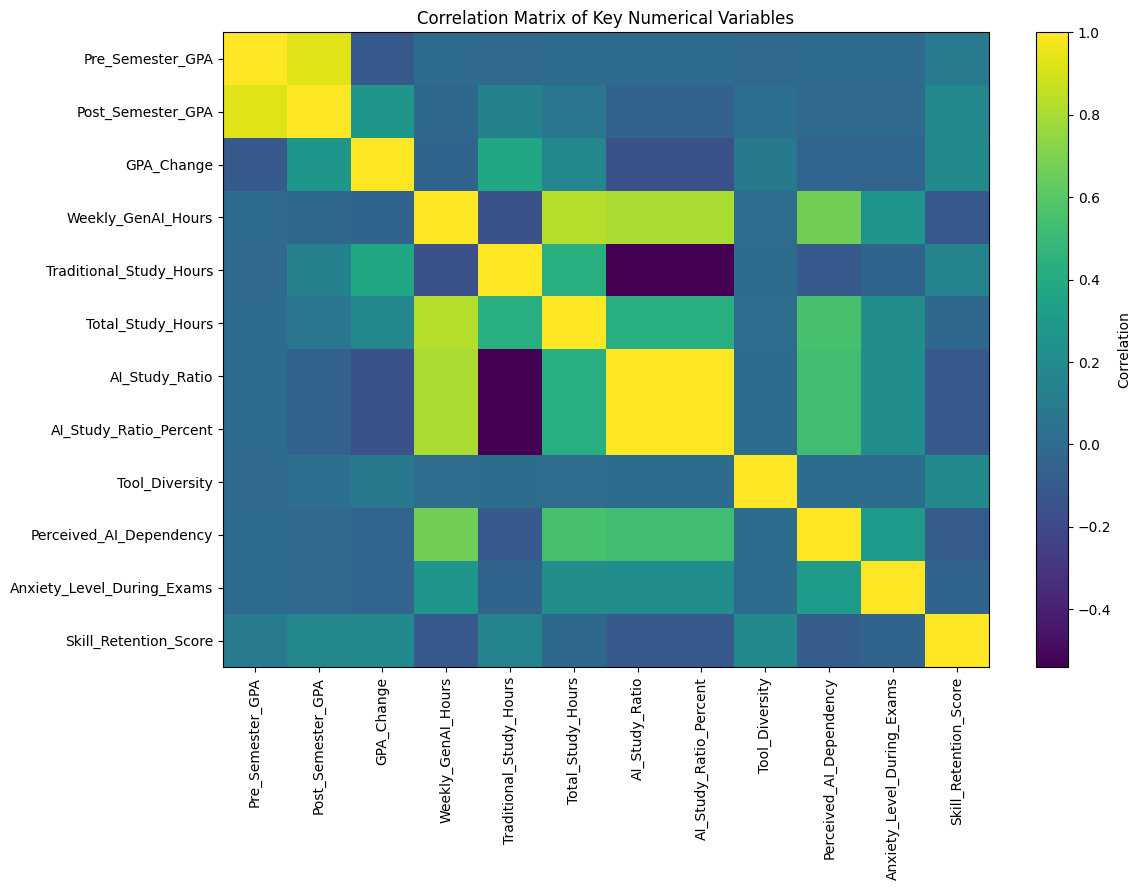

In [237]:
plt.figure(figsize=(12, 9))
plt.imshow(correlation_matrix, aspect="auto")
plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.index)),
    correlation_matrix.index
)

plt.title("Correlation Matrix of Key Numerical Variables")
plt.tight_layout()

plt.savefig("../reports/figures/correlation_matrix.png", dpi=300)
plt.show()

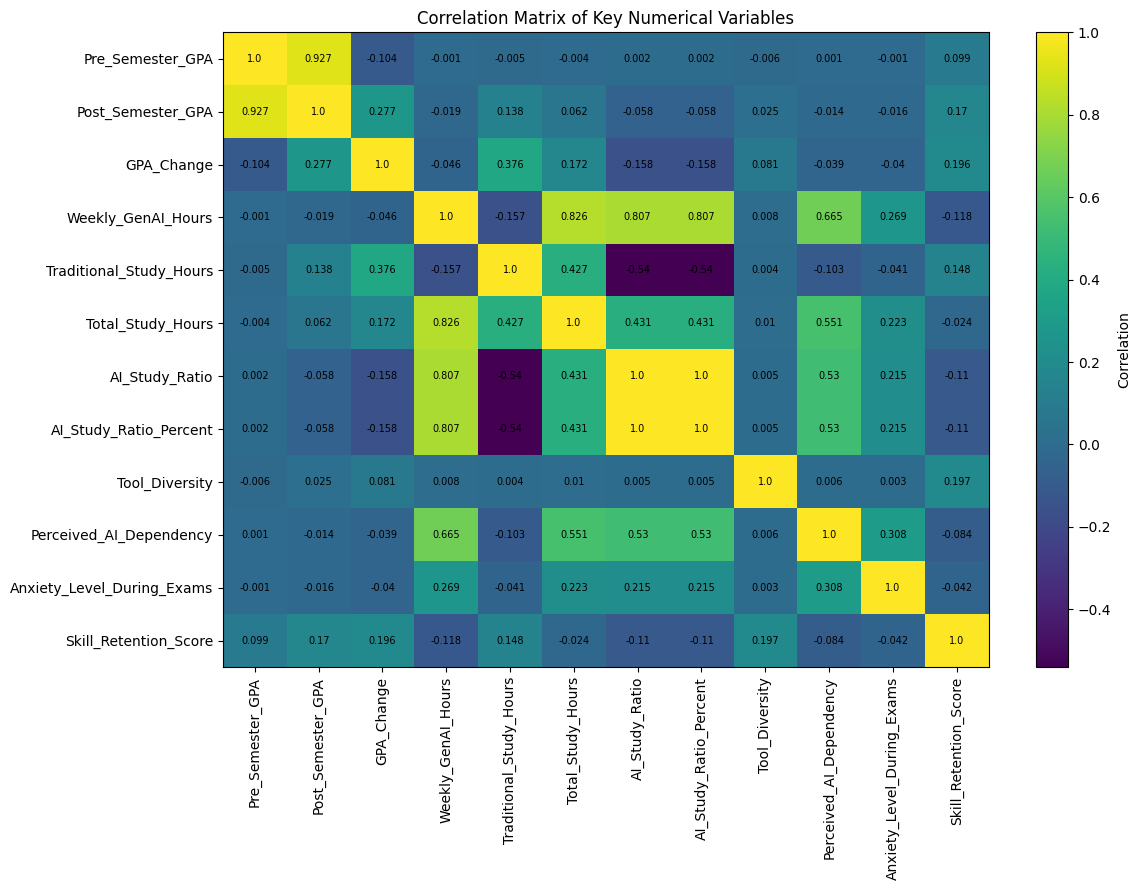

In [238]:
plt.figure(figsize=(12, 9))
plt.imshow(correlation_matrix, aspect="auto")
plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.index)),
    correlation_matrix.index
)

for i in range(len(correlation_matrix.index)):
    for j in range(len(correlation_matrix.columns)):
        plt.text(
            j,
            i,
            correlation_matrix.iloc[i, j],
            ha="center",
            va="center",
            fontsize=7
        )

plt.title("Correlation Matrix of Key Numerical Variables")
plt.tight_layout()

plt.savefig("../reports/figures/correlation_matrix_with_values.png", dpi=300)
plt.show()

In [239]:
small_corr_columns = [
    "GPA_Change",
    "Skill_Retention_Score",
    "Weekly_GenAI_Hours",
    "Traditional_Study_Hours",
    "AI_Study_Ratio",
    "Perceived_AI_Dependency",
    "Anxiety_Level_During_Exams"
]

small_correlation_matrix = df_analysis[small_corr_columns].corr().round(3)

small_correlation_matrix

,GPA_Change,Skill_Retention_Score,Weekly_GenAI_Hours,Traditional_Study_Hours,AI_Study_Ratio,Perceived_AI_Dependency,Anxiety_Level_During_Exams
GPA_Change,1.000,0.196,-0.046,0.376,-0.158,-0.039,-0.040
Skill_Retention_Score,0.196,1.000,-0.118,0.148,-0.110,-0.084,-0.042
Weekly_GenAI_Hours,-0.046,-0.118,1.000,-0.157,0.807,0.665,0.269
Traditional_Study_Hours,0.376,0.148,-0.157,1.000,-0.540,-0.103,-0.041
AI_Study_Ratio,-0.158,-0.110,0.807,-0.540,1.000,0.530,0.215
Perceived_AI_Dependency,-0.039,-0.084,0.665,-0.103,0.530,1.000,0.308
Anxiety_Level_During_Exams,-0.040,-0.042,0.269,-0.041,0.215,0.308,1.000


In [240]:
small_correlation_matrix.to_csv(
    "../reports/tables/small_correlation_matrix.csv"
)

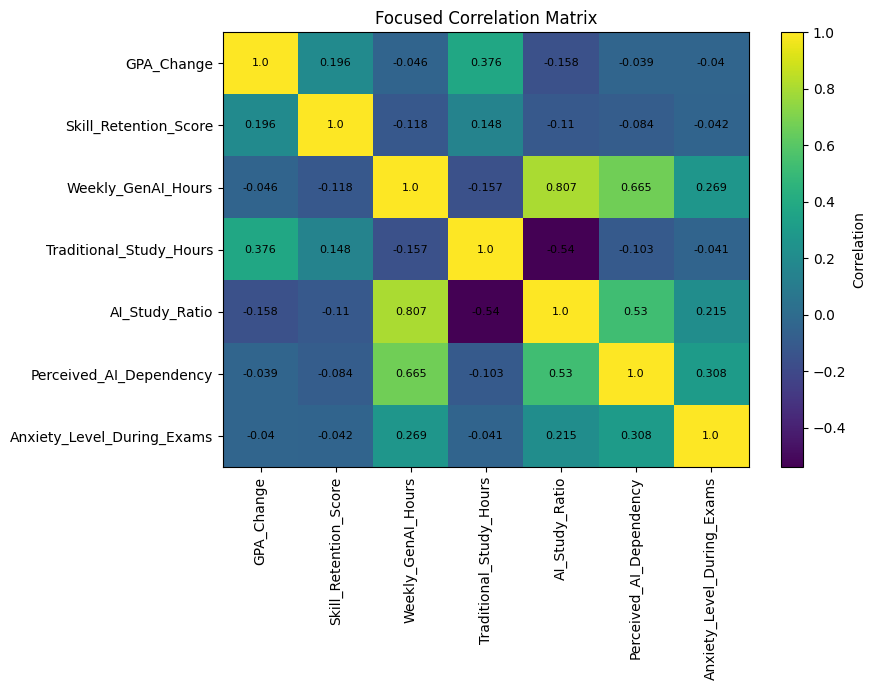

In [241]:
plt.figure(figsize=(9, 7))
plt.imshow(small_correlation_matrix, aspect="auto")
plt.colorbar(label="Correlation")

plt.xticks(
    range(len(small_correlation_matrix.columns)),
    small_correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(small_correlation_matrix.index)),
    small_correlation_matrix.index
)

for i in range(len(small_correlation_matrix.index)):
    for j in range(len(small_correlation_matrix.columns)):
        plt.text(
            j,
            i,
            small_correlation_matrix.iloc[i, j],
            ha="center",
            va="center",
            fontsize=8
        )

plt.title("Focused Correlation Matrix")
plt.tight_layout()

plt.savefig("../reports/figures/focused_correlation_matrix.png", dpi=300)
plt.show()

In [242]:
gpa_change_correlations = (
    correlation_matrix["GPA_Change"]
    .drop("GPA_Change")
    .sort_values(ascending=False)
)

gpa_change_correlations

Traditional_Study_Hours       0.376
Post_Semester_GPA             0.277
Skill_Retention_Score         0.196
Total_Study_Hours             0.172
Tool_Diversity                0.081
Perceived_AI_Dependency      -0.039
Anxiety_Level_During_Exams   -0.040
Weekly_GenAI_Hours           -0.046
Pre_Semester_GPA             -0.104
AI_Study_Ratio_Percent       -0.158
AI_Study_Ratio               -0.158
Name: GPA_Change, dtype: float64

In [243]:
gpa_change_correlations.to_csv(
    "../reports/tables/gpa_change_correlations.csv"
)

In [244]:
skill_retention_correlations = (
    correlation_matrix["Skill_Retention_Score"]
    .drop("Skill_Retention_Score")
    .sort_values(ascending=False)
)

skill_retention_correlations

Tool_Diversity                0.197
GPA_Change                    0.196
Post_Semester_GPA             0.170
Traditional_Study_Hours       0.148
Pre_Semester_GPA              0.099
Total_Study_Hours            -0.024
Anxiety_Level_During_Exams   -0.042
Perceived_AI_Dependency      -0.084
AI_Study_Ratio               -0.110
AI_Study_Ratio_Percent       -0.110
Weekly_GenAI_Hours           -0.118
Name: Skill_Retention_Score, dtype: float64

In [245]:
skill_retention_correlations.to_csv(
    "../reports/tables/skill_retention_correlations.csv"
)

In [246]:
dependency_correlations = (
    correlation_matrix["Perceived_AI_Dependency"]
    .drop("Perceived_AI_Dependency")
    .sort_values(ascending=False)
)

dependency_correlations

Weekly_GenAI_Hours            0.665
Total_Study_Hours             0.551
AI_Study_Ratio                0.530
AI_Study_Ratio_Percent        0.530
Anxiety_Level_During_Exams    0.308
Tool_Diversity                0.006
Pre_Semester_GPA              0.001
Post_Semester_GPA            -0.014
GPA_Change                   -0.039
Skill_Retention_Score        -0.084
Traditional_Study_Hours      -0.103
Name: Perceived_AI_Dependency, dtype: float64

In [247]:
dependency_correlations.to_csv(
    "../reports/tables/dependency_correlations.csv"
)

In [248]:
anxiety_correlations = (
    correlation_matrix["Anxiety_Level_During_Exams"]
    .drop("Anxiety_Level_During_Exams")
    .sort_values(ascending=False)
)

anxiety_correlations

Perceived_AI_Dependency    0.308
Weekly_GenAI_Hours         0.269
Total_Study_Hours          0.223
AI_Study_Ratio_Percent     0.215
AI_Study_Ratio             0.215
Tool_Diversity             0.003
Pre_Semester_GPA          -0.001
Post_Semester_GPA         -0.016
GPA_Change                -0.040
Traditional_Study_Hours   -0.041
Skill_Retention_Score     -0.042
Name: Anxiety_Level_During_Exams, dtype: float64

In [249]:
anxiety_correlations.to_csv(
    "../reports/tables/anxiety_correlations.csv"
)

### Key Correlation Findings

The correlation analysis supports several patterns found in the grouped analysis:

1. **Traditional study hours are positively associated with GPA change.**  
   This suggests that non-AI study effort remains important in explaining academic improvement.

2. **Weekly GenAI hours are strongly associated with perceived AI dependency.**  
   Students who use GenAI more heavily also tend to report higher dependency.

3. **Weekly GenAI hours are positively associated with exam anxiety.**  
   This does not prove that GenAI causes anxiety, but it suggests that heavier AI users also report higher anxiety.

4. **AI study ratio is important.**  
   Students whose total study time is more AI-heavy do not necessarily show stronger GPA improvement.

5. **Pre-semester GPA and post-semester GPA are strongly correlated.**  
   This is expected and shows that prior academic performance is a strong marker of final academic performance.

### Connection to Earlier Findings

The correlation analysis reinforces the main story of the project:

GenAI usage should not be evaluated only by how many hours students use it. The relationship between GenAI and outcomes depends on usage intensity, study balance, use case, prompt skill, and student context.

Moderate and purposeful GenAI use appears more favorable than very high or AI-heavy reliance. Traditional study effort, prompt skill, and active problem-solving use cases remain important for stronger academic outcomes.

In [250]:
os.listdir("../reports/tables")

['advanced_vs_beginner_prompt_skill_difference.csv',
 'anxiety_correlations.csv',
 'burnout_distribution_by_ai_group.csv',
 'burnout_distribution_by_primary_use_case.csv',
 'burnout_distribution_by_prompt_skill.csv',
 'burnout_distribution_by_study_profile.csv',
 'categorical_summary.csv',
 'correlation_matrix.csv',
 'data_dictionary.csv',
 'debugging_vs_direct_answer_difference.csv',
 'dependency_correlations.csv',
 'feature_engineering_summary.csv',
 'gpa_change_category_by_ai_group.csv',
 'gpa_change_category_by_primary_use_case.csv',
 'gpa_change_category_by_prompt_skill.csv',
 'gpa_change_category_by_study_profile.csv',
 'gpa_change_correlations.csv',
 'main_outcome_correlations.csv',
 'selected_key_correlations.csv',
 'selected_study_ratio_correlations.csv',
 'skill_retention_correlations.csv',
 'small_correlation_matrix.csv',
 'study_profile_group_differences.csv',
 'study_ratio_correlations.csv',
 'summary_by_ai_hours_group.csv',
 'summary_by_institutional_policy.csv',
 'summar

In [251]:
os.listdir("../reports/figures")

['avg_ai_hours_by_major_category.png',
 'avg_ai_hours_by_paid_subscription.png',
 'avg_ai_study_ratio_by_ai_hours_group.png',
 'avg_dependency_by_ai_hours_group.png',
 'avg_dependency_by_primary_use_case.png',
 'avg_dependency_by_prompt_skill.png',
 'avg_dependency_by_study_profile.png',
 'avg_exam_anxiety_by_ai_hours_group.png',
 'avg_gpa_change_by_ai_hours_group.png',
 'avg_gpa_change_by_institutional_policy.png',
 'avg_gpa_change_by_major_category.png',
 'avg_gpa_change_by_primary_use_case.png',
 'avg_gpa_change_by_prompt_skill.png',
 'avg_gpa_change_by_study_profile.png',
 'avg_gpa_change_by_traditional_study_group.png',
 'avg_gpa_change_by_year_of_study.png',
 'avg_skill_retention_by_ai_hours_group.png',
 'avg_skill_retention_by_primary_use_case.png',
 'avg_skill_retention_by_prompt_skill.png',
 'avg_skill_retention_by_study_profile.png',
 'avg_skill_retention_by_traditional_study_group.png',
 'avg_total_study_hours_by_ai_hours_group.png',
 'correlation_matrix.png',
 'correlation_

## 11. Final EDA Summary and Recommendations

In this section, we summarize the main findings from the exploratory data analysis and translate them into practical recommendations for responsible GenAI use in education.

## Main Research Question

This project investigates the following question:

**How are Generative AI usage patterns associated with student academic performance, skill retention, AI dependency, exam anxiety, and burnout risk?**

The analysis focuses not only on how much students use GenAI, but also on how they use it, how skilled they are at prompting, and whether their study routine is balanced or AI-heavy.

In [253]:
final_insights = pd.DataFrame({
    "Insight_Number": [1, 2, 3, 4, 5, 6],
    "Theme": [
        "GenAI Usage Intensity",
        "Primary Use Case",
        "Prompt Engineering Skill",
        "Study Balance",
        "Student Context",
        "Paid Subscription"
    ],
    "Main_Finding": [
        "Moderate GenAI usage is associated with stronger GPA improvement and skill retention, while very high usage is associated with much higher burnout risk.",
        "Debugging/Troubleshooting is associated with the strongest academic outcomes, while Direct Answer Generation is associated with weaker GPA improvement and lower skill retention.",
        "Advanced prompt engineering skill is associated with substantially higher skill retention and stronger GPA improvement.",
        "AI-heavy study patterns are important to examine because study balance appears to matter for both academic and well-being outcomes.",
        "Outcomes differ across institutional policy, major category, and year of study, suggesting that responsible AI guidance should be segment-specific.",
        "Paid subscription users use GenAI more heavily and show higher risk indicators, without a large academic advantage."
    ],
    "Interpretation": [
        "More GenAI usage is not always better. There appears to be a non-linear relationship between AI use and student outcomes.",
        "How students use GenAI matters. Active problem-solving use appears more favorable than passive answer-seeking.",
        "AI literacy and prompting ability may be important for durable learning.",
        "GenAI may work best as a complement to active study rather than a replacement for it.",
        "A one-size-fits-all AI policy may miss important differences between student groups.",
        "Paid access may reflect heavier reliance rather than automatically better academic performance."
    ],
    "Recommendation": [
        "Encourage moderate and purposeful GenAI use instead of maximum usage.",
        "Teach students to use GenAI for reasoning, debugging, feedback, and explanation rather than direct answer generation.",
        "Include prompt engineering and AI output evaluation in student AI literacy programs.",
        "Promote balanced study routines that combine GenAI with traditional active learning.",
        "Design different support strategies for high-risk groups such as STEM, graduate students, and students under strict-ban environments.",
        "Monitor paid AI users for dependency, anxiety, and burnout risk rather than assuming paid access is purely beneficial."
    ]
})

final_insights

,Insight_Number,Theme,Main_Finding,Interpretation,Recommendation
0,1,GenAI Usage Intensity,Moderate GenAI usage is associated with strong...,More GenAI usage is not always better. There a...,Encourage moderate and purposeful GenAI use in...
1,2,Primary Use Case,Debugging/Troubleshooting is associated with t...,How students use GenAI matters. Active problem...,"Teach students to use GenAI for reasoning, deb..."
2,3,Prompt Engineering Skill,Advanced prompt engineering skill is associate...,AI literacy and prompting ability may be impor...,Include prompt engineering and AI output evalu...
3,4,Study Balance,AI-heavy study patterns are important to exami...,GenAI may work best as a complement to active ...,Promote balanced study routines that combine G...
4,5,Student Context,"Outcomes differ across institutional policy, m...",A one-size-fits-all AI policy may miss importa...,Design different support strategies for high-r...
5,6,Paid Subscription,Paid subscription users use GenAI more heavily...,Paid access may reflect heavier reliance rathe...,"Monitor paid AI users for dependency, anxiety,..."


In [254]:
final_insights.to_csv(
    "../reports/tables/final_insights_summary.csv",
    index=False
)

## Key Findings

### 1. GenAI usage has a non-linear relationship with student outcomes

Moderate GenAI usage, especially around 5-15 hours per week, is associated with stronger average GPA improvement and skill retention. However, the 15h+ group shows lower skill retention and a sharply higher high-burnout rate.

This suggests that more GenAI usage is not always associated with better outcomes.

### 2. Use case matters

Students who primarily use GenAI for Debugging/Troubleshooting show the strongest academic outcome pattern. Students who primarily use GenAI for Direct Answer Generation show the weakest average GPA improvement and lower skill retention.

This suggests that GenAI may be more useful when it supports active problem solving rather than replacing the student's own reasoning.

### 3. Prompt engineering skill is strongly associated with learning retention

Advanced prompt users show substantially higher skill retention than beginner users. They also show stronger GPA improvement.

This suggests that AI literacy should include prompt design, output evaluation, and iterative questioning.

### 4. Study balance matters

Students should not be evaluated only by raw GenAI usage hours. The share of total study time spent using AI is also important.

AI-heavy study patterns may carry different academic and well-being risks than balanced study routines.

### 5. Context matters

Student outcomes differ by institutional policy, major category, year of study, and paid subscription status.

This means that responsible GenAI strategies should not be one-size-fits-all. Different student groups may need different guidance and support.

## Business and Educational Interpretation

The analysis suggests that GenAI should not be treated as a simple binary variable where usage is either good or bad.

The more useful distinction is between:

- moderate vs very high usage,
- active learning use cases vs direct answer generation,
- beginner vs advanced prompt skill,
- balanced vs AI-heavy study routines,
- lower-risk vs higher-risk student segments.

For universities, edtech platforms, and student support teams, the main implication is that responsible GenAI adoption requires guidance, not just access.

Students may benefit from GenAI when it is used to support explanation, debugging, ideation, feedback, and structured learning. However, very high usage and AI-heavy study patterns may require monitoring because they are associated with higher dependency, anxiety, and burnout risk.

In [256]:
recommendations = pd.DataFrame({
    "Target_Group": [
        "All Students",
        "Heavy GenAI Users",
        "Direct Answer Generation Users",
        "Beginner Prompt Users",
        "STEM Students",
        "Graduate Students",
        "Paid Subscription Users",
        "Institutions with Strict AI Bans"
    ],
    "Observed_Risk_or_Need": [
        "Students need guidance on effective and responsible GenAI use.",
        "Very high GenAI usage is associated with higher dependency, anxiety, and burnout risk.",
        "Direct answer generation is associated with weaker academic outcomes and lower skill retention.",
        "Beginner prompt users show lower skill retention than advanced prompt users.",
        "STEM students show strong academic outcomes but also higher burnout risk.",
        "Graduate students show strong academic outcomes but high burnout risk.",
        "Paid users show heavier GenAI usage and higher risk indicators.",
        "Strict-ban policy environments show higher anxiety and burnout indicators."
    ],
    "Recommendation": [
        "Provide AI literacy training focused on active learning, academic integrity, and output evaluation.",
        "Encourage usage limits, self-monitoring, and balanced study routines.",
        "Teach students to ask for explanations, feedback, hints, and debugging support rather than direct final answers.",
        "Offer prompt engineering workshops and examples of effective learning-oriented prompts.",
        "Provide targeted workload, dependency, and burnout monitoring for high-intensity technical learners.",
        "Offer academic pressure management and responsible GenAI support for advanced students.",
        "Monitor whether paid access is leading to overreliance rather than better learning.",
        "Consider replacing blanket bans with structured citation-based or guided-use policies."
    ],
    "Expected_Benefit": [
        "Better learning outcomes and lower misuse risk.",
        "Reduced overreliance and better well-being outcomes.",
        "Higher skill retention and more active learning.",
        "Better use of GenAI as a learning assistant.",
        "Stronger academic outcomes without ignoring well-being risks.",
        "Better support for high-pressure student groups.",
        "More responsible use among high-access users.",
        "Lower anxiety and clearer expectations around AI use."
    ]
})

recommendations

,Target_Group,Observed_Risk_or_Need,Recommendation,Expected_Benefit
0,All Students,Students need guidance on effective and respon...,Provide AI literacy training focused on active...,Better learning outcomes and lower misuse risk.
1,Heavy GenAI Users,Very high GenAI usage is associated with highe...,"Encourage usage limits, self-monitoring, and b...",Reduced overreliance and better well-being out...
2,Direct Answer Generation Users,Direct answer generation is associated with we...,"Teach students to ask for explanations, feedba...",Higher skill retention and more active learning.
3,Beginner Prompt Users,Beginner prompt users show lower skill retenti...,Offer prompt engineering workshops and example...,Better use of GenAI as a learning assistant.
4,STEM Students,STEM students show strong academic outcomes bu...,"Provide targeted workload, dependency, and bur...",Stronger academic outcomes without ignoring we...
5,Graduate Students,Graduate students show strong academic outcome...,Offer academic pressure management and respons...,Better support for high-pressure student groups.
6,Paid Subscription Users,Paid users show heavier GenAI usage and higher...,Monitor whether paid access is leading to over...,More responsible use among high-access users.
7,Institutions with Strict AI Bans,Strict-ban policy environments show higher anx...,Consider replacing blanket bans with structure...,Lower anxiety and clearer expectations around ...


In [257]:
recommendations.to_csv(
    "../reports/tables/recommendations.csv",
    index=False
)

## Recommendations

Based on the exploratory analysis, the following recommendations can be made:

### 1. Teach responsible GenAI use instead of only allowing or banning it

The analysis suggests that student outcomes differ depending on how GenAI is used. Institutions should provide practical AI literacy training instead of treating GenAI use as a simple yes/no issue.

### 2. Encourage active learning use cases

Students should be encouraged to use GenAI for debugging, troubleshooting, feedback, explanation, ideation, and guided learning. Direct answer generation should be discouraged because it is associated with weaker GPA improvement and lower skill retention.

### 3. Teach prompt engineering as a learning skill

Advanced prompt users show much higher skill retention. This suggests that prompt engineering should be treated as part of academic skill development, not just a technical trick.

### 4. Monitor very high GenAI usage

The 15h+ GenAI usage group shows much higher burnout risk and lower skill retention. Heavy users may need support around workload, dependency, and study balance.

### 5. Promote balanced study routines

GenAI should complement traditional study, not fully replace it. Students should combine AI-supported learning with reading, note-taking, practice, discussion, and problem solving.

### 6. Use segment-specific support

STEM students, graduate students, paid subscription users, and students under strict-ban environments may require different types of guidance and monitoring.

## Limitations

This project has several important limitations:

1. **Observational data**  
   The analysis identifies associations, not causal effects. For example, high GenAI usage being associated with burnout risk does not prove that GenAI causes burnout.

2. **Self-reported variables**  
   Variables such as perceived AI dependency, prompt engineering skill, and anxiety may be based on student self-reporting. These measures can contain subjective bias.

3. **No longitudinal behavioral tracking**  
   The dataset compares pre-semester and post-semester GPA, but it does not fully capture how student behavior changed week by week.

4. **No direct measure of assignment quality**  
   GPA and skill retention are useful outcome indicators, but they do not show the full quality of student learning or submitted work.

5. **Potential confounding factors**  
   Factors such as course difficulty, instructor policy, prior student ability, socioeconomic background, workload, and mental health history may also influence the outcomes.

6. **Correlation does not equal causation**  
   Correlation and grouped comparisons should be interpreted as descriptive evidence, not proof of direct causal relationships.

## Conclusion

This project shows that GenAI usage in education is not simply good or bad. The relationship between GenAI and student outcomes depends on usage intensity, use case, prompt skill, study balance, and student context.

Moderate and purposeful GenAI use is associated with stronger academic outcomes, especially GPA improvement and skill retention. In contrast, very high GenAI usage and AI-heavy study patterns are associated with higher perceived dependency, higher exam anxiety, and higher burnout risk.

The strongest academic patterns appear among students who use GenAI for active problem solving, especially Debugging/Troubleshooting, and among students with advanced prompt engineering skills. Direct Answer Generation shows weaker academic outcomes, suggesting that using GenAI as a shortcut may be less beneficial for durable learning.

Overall, the analysis supports a responsible AI education strategy focused on guidance, balance, prompt literacy, active learning, and targeted support for higher-risk student groups.

## Executive Summary

This project analyzed 50,000 student records to explore how Generative AI usage relates to GPA change, skill retention, perceived AI dependency, exam anxiety, and burnout risk.

The main finding is that GenAI usage has a non-linear relationship with student outcomes. Moderate usage is associated with stronger academic outcomes, while very high usage is associated with higher dependency, anxiety, and burnout risk.

The way students use GenAI matters. Debugging/Troubleshooting is associated with the strongest academic results, while Direct Answer Generation is associated with weaker GPA improvement and lower skill retention.

Prompt engineering skill is also important. Advanced prompt users show substantially higher skill retention than beginner users.

The project concludes that responsible GenAI adoption in education should focus on balanced use, active learning, prompt literacy, and targeted support for high-risk student groups.